# Scenario C: Assistive Household Robot
## Full-Stack Mobile Manipulator (CS4973)

A simulated mobile manipulator written in pure Python. The mobile base drives across a
household room, works out where it is, and builds a map as it goes. Once it arrives, the arm
does a contact task (pressing a light switch, or handing an item to a person) using admittance
control so that it gives way if it touches something unexpectedly.

**Contents**

| Task | Section |
|---|---|
| 1 | Kinematic motion model (unicycle plus a differential drive layer) |
| 2 | Environment and sensor simulation (room, odometry noise, landmarks, lidar) |
| 3 | Motion planning (potential field and PRM) |
| 4 | Probabilistic localization (EKF) |
| 5 | Occupancy grid mapping (log odds) |
| 6 | Arm forward and inverse kinematics (DH model, pseudoinverse IK) |
| 7 | Jacobian and velocity control (resolved rate control, singularities) |
| 8 | Arm dynamics and joint control (mass matrix, gravity, computed torque) |
| 9 | Trajectory generation (quintic and trapezoidal profiles, Cartesian paths) |

The notebook runs top to bottom. Each task ends with a block of tests, and every test is run
again together at the end.

In [126]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Circle
from dataclasses import dataclass, field, replace
from typing import List, Tuple, Optional

%matplotlib inline
plt.rcParams.update({
    "figure.dpi": 110,
    "figure.facecolor": "white",
    "axes.grid": True,
    "grid.alpha": 0.25,
    "font.size": 9,
})

# Every random draw in the project comes from a stream derived from this one number, so the
# whole notebook is reproducible from a single seed. Change it to get a different run.
MASTER_SEED = 7

def make_rng(stream: int) -> np.random.Generator:
    """Return an independent random stream, reproducible from MASTER_SEED.

    Passing a list as the seed gives numpy a distinct stream per `stream` value. We use one
    stream per purpose (drive, plotting probe, each test) so that adding a random draw in one
    place does not shift the numbers everywhere else.
    """
    return np.random.default_rng([MASTER_SEED, stream])

print("numpy", np.__version__)

numpy 2.5.0


## Test framework

A small test registry so the notebook can check its own work. `@test("Task 1")` registers a
function and `run_tests("Task 1")` runs that group, printing a pass or fail line for each. The
runner raises at the end if anything failed, so a broken notebook stops rather than carrying on
with bad numbers.

Tests that use random numbers get their own fixed seed, so they give the same answer every run.
We did not want tests that pass only some of the time.

In [127]:
TESTS = []   # list of (group, readable name, function)

def test(group):
    """Decorator that registers a test function under a named group."""
    def register(fn):
        # Turn a function name like `test_full_circle` into "full circle" for the printout.
        readable = fn.__name__.removeprefix("test_").replace("_", " ")
        TESTS.append((group, readable, fn))
        return fn
    return register


def run_tests(group=None, verbose=True):
    """Run every registered test (or just one group) and summarise the result.

    Raises AssertionError at the end if any test failed, so a broken notebook stops here
    rather than carrying on with bad numbers.
    """
    selected = [t for t in TESTS if group is None or t[0] == group]
    if not selected:
        raise ValueError(f"no tests registered for group {group!r}")

    failures = []
    for grp, name, fn in selected:
        try:
            fn()
            if verbose:
                print(f"  pass    {name}")
        except AssertionError as exc:
            failures.append((name, str(exc) or "assertion failed"))
            print(f"  FAIL    {name}: {exc}")
        except Exception as exc:                      # a crash is a failure too
            failures.append((name, f"{type(exc).__name__}: {exc}"))
            print(f"  ERROR   {name}: {type(exc).__name__}: {exc}")

    label = group if group else "all groups"
    print(f"\n{len(selected) - len(failures)}/{len(selected)} tests passed ({label})")
    if failures:
        raise AssertionError(f"{len(failures)} test(s) failed: "
                             + "; ".join(n for n, _ in failures))
    return len(selected)


def close(a, b, tol=1e-9):
    """Shorthand for comparing floats and arrays inside tests."""
    return np.allclose(np.asarray(a, dtype=float), np.asarray(b, dtype=float), atol=tol)


def poses_close(a, b, tol=1e-9):
    """Compare two poses, wrapping the heading difference before checking it."""
    a, b = np.asarray(a, dtype=float), np.asarray(b, dtype=float)
    return close(a[:2], b[:2], tol) and abs(wrap_to_pi(a[2] - b[2])) < tol


print("test framework ready")

test framework ready


---
# Task 1: Kinematic Motion Model

## 1.1 The model

We use the **unicycle** model with a **differential drive** layer bolted on top, so the same
code takes either a body twist $(v, \omega)$ or a pair of wheel speeds $(\omega_L, \omega_R)$.

The state is the planar pose $\mathbf{x} = (x, y, \theta)$, and the continuous motion is

$$\dot x = v\cos\theta, \qquad \dot y = v\sin\theta, \qquad \dot\theta = \omega .$$

### Why not plain Euler integration

The obvious thing to write is `x += v*cos(theta)*dt`, but the heading is changing during the
step, so that line uses a heading that is already out of date by the end of it. The robot ends
up slightly short of where it should be on any turn, and because the error always goes the same
way it builds up instead of averaging out.

If $(v, \omega)$ is constant across the step we can write the exact answer down instead. The
robot travels along a circular arc of radius $R = v/\omega$ around the instantaneous centre of
curvature, which gives

$$
\theta' = \theta + \omega\,\Delta t, \qquad
x' = x + R\,(\sin\theta' - \sin\theta), \qquad
y' = y - R\,(\cos\theta' - \cos\theta).
$$

This blows up as $\omega \to 0$, since $R \to \infty$, so below a small threshold we fall back
to the straight line formula. The two agree in the limit. Section 1.3 compares the two, and the
Euler version is only kept in the notebook for that comparison.

We spent the time on this because of Task 4: there the gap between where the robot thinks it is
and where it actually is has to come from the noise model. If our integrator leaked error of its
own, the filter would be correcting for a bug in our code instead.

### Differential drive layer

With wheel radius $r$ and track width $L$ (the distance between the two wheels):

$$v = \frac{r(\omega_R + \omega_L)}{2}, \qquad \omega = \frac{r(\omega_R - \omega_L)}{L}$$

which rearranges to $\omega_R = (2v + \omega L)/2r$ and $\omega_L = (2v - \omega L)/2r$. The
later tasks all command $(v, \omega)$ directly and only use this layer to enforce a speed limit
on each wheel.

In [128]:
def wrap_to_pi(a):
    """Wrap an angle (or array of angles) into (-pi, pi].

    Needed anywhere angles get subtracted, or 359 degrees and -1 degree come out 360 apart.
    """
    wrapped = (np.asarray(a, dtype=float) + np.pi) % (2 * np.pi) - np.pi
    # The modulo sends exactly +pi to -pi, the one value outside the range we promised, so
    # send it back.
    return np.where(wrapped == -np.pi, np.pi, wrapped)[()]


def unicycle_step(pose, v, w, dt, straight_eps=1e-9):
    """Advance the pose by one step of constant (v, w), integrating the arc exactly.

    pose is (x, y, theta) in metres and radians, v is m/s, w is rad/s, dt is seconds.
    Returns a new (3,) pose; the input is not modified.
    """
    x, y, th = pose

    if abs(w) < straight_eps:
        # Straight line branch. The arc formula divides by w, so we cannot use it here.
        return np.array([x + v * np.cos(th) * dt,
                         y + v * np.sin(th) * dt,
                         wrap_to_pi(th)])

    # Arc branch. R is signed: positive w turns left, negative w turns right.
    R = v / w
    th_new = th + w * dt
    return np.array([x + R * (np.sin(th_new) - np.sin(th)),
                     y - R * (np.cos(th_new) - np.cos(th)),
                     wrap_to_pi(th_new)])


def unicycle_step_euler(pose, v, w, dt):
    """Forward Euler step, kept only as the comparison baseline in section 1.3.

    Velocities are read at the start of the step and held fixed. Nothing else uses it.
    """
    x, y, th = pose
    return np.array([x + v * np.cos(th) * dt,
                     y + v * np.sin(th) * dt,
                     wrap_to_pi(th + w * dt)])


def simulate(pose0, controls, dt, step_fn=unicycle_step):
    """Roll a list of (v, w) commands forward into a trajectory.

    Returns an (N+1, 3) array of poses including the starting pose, so row k is the pose after
    k commands have been applied.
    """
    poses = [np.asarray(pose0, dtype=float)]
    for v, w in controls:
        poses.append(step_fn(poses[-1], v, w, dt))
    return np.array(poses)


def const_twist(v, w, duration, dt):
    """Hold (v, w) for `duration` seconds, as a list of commands."""
    return [(v, w)] * int(round(duration / dt))


@dataclass
class DiffDrive:
    """Differential drive wheel layer sitting on top of the unicycle body twist."""
    wheel_radius: float = 0.05     # r [m]
    track_width: float = 0.30      # L [m], distance between the two wheels
    max_wheel_rate: float = 12.0   # [rad/s], about 0.6 m/s at r = 0.05

    def wheels_to_twist(self, w_left, w_right):
        """Wheel angular speeds [rad/s] to body twist (v [m/s], w [rad/s])."""
        v = self.wheel_radius * (w_right + w_left) / 2.0
        w = self.wheel_radius * (w_right - w_left) / self.track_width
        return v, w

    def twist_to_wheels(self, v, w):
        """Body twist to wheel angular speeds. The inverse of wheels_to_twist."""
        w_right = (2 * v + w * self.track_width) / (2 * self.wheel_radius)
        w_left = (2 * v - w * self.track_width) / (2 * self.wheel_radius)
        return w_left, w_right

    def clamp_twist(self, v, w):
        """Scale a twist down until both wheels are inside their speed limit.

        v and w are scaled by the same factor rather than clipped separately, because the
        curvature is R = v/w: scaling both keeps the same arc, just driven more slowly.
        """
        wl, wr = self.twist_to_wheels(v, w)
        peak = max(abs(wl), abs(wr))
        if peak > self.max_wheel_rate:
            s = self.max_wheel_rate / peak
            return v * s, w * s
        return v, w


ROBOT = DiffDrive()
print("twist -> wheels -> twist round trip:", ROBOT.wheels_to_twist(*ROBOT.twist_to_wheels(0.4, 0.7)))

twist -> wheels -> twist round trip: (0.4, 0.7)


## 1.2 Checking it against cases we can do by hand

Four cases where the answer can be worked out on paper. All of them start from the origin pose
$(0, 0, 0)$ and hold one twist, so the closed form is

- $\omega = 0$: a straight line ending at $(vT,\, 0,\, 0)$.
- $\omega \ne 0$: an arc of radius $R = v/\omega$ swept through $\phi = \omega T$, ending at
  $\big(R\sin\phi,\; R(1-\cos\phi),\; \phi\big)$.

| # | Command | Duration | Worked out by hand |
|---|---|---|---|
| 1 | $v=0.5$, $\omega=0$ | 4 s | drives 2 m along $+x$, giving $(2, 0, 0)$ |
| 2 | $v=0$, $\omega=\pi/4$ | 2 s | turns in place through 90 degrees, giving $(0, 0, \pi/2)$ |
| 3 | $v=1.0$, $\omega=0.5$ | $\pi$ s | a quarter of a circle of radius 2, giving $(2, 2, \pi/2)$ |
| 4 | $v=1.0$, $\omega=0.5$ | $4\pi$ s | one full circle, so back to $(0, 0, 0)$ |

Case 4 is the one we found most useful, since any per step bias piles up around the loop instead
of cancelling out, so coming back to the start really is a check.

Each case runs in **1000 steps**, so we are testing the repeated integration rather than one
evaluation of a formula. The step size is $\Delta t = T/1000$ rather than a round number like
0.01 s: two of the durations are irrational, and a round step would not divide them evenly, so
the simulation would run a slightly shorter arc than the hand calculation assumes and we would
be looking at a bookkeeping error rather than an integration one. The expected poses in the code
below are typed in from the table above rather than recomputed.

In [129]:
def analytic_const_twist(v, w, T, straight_eps=1e-9):
    """Closed form pose after holding (v, w) for T seconds, starting from the origin pose."""
    if abs(w) < straight_eps:
        return np.array([v * T, 0.0, 0.0])
    R, phi = v / w, w * T
    return np.array([R * np.sin(phi), R * (1 - np.cos(phi)), wrap_to_pi(phi)])


N_STEPS = 1000   # steps per case, so we are testing repeated integration

#        name               v     w          T          pose worked out by hand
CASES = [("straight 2 m",   0.5,  0.0,       4.0,       [2.0, 0.0, 0.0]),
         ("turn 90 in place", 0.0, np.pi / 4, 2.0,      [0.0, 0.0, np.pi / 2]),
         ("quarter circle",  1.0,  0.5,       np.pi,     [2.0, 2.0, np.pi / 2]),
         ("full circle",     1.0,  0.5,       4 * np.pi, [0.0, 0.0, 0.0])]

print(f"{'case':<19}{'simulated (x, y, theta)':<34}{'expected by hand':<34}{'max err':>10}")
print("-" * 97)

trajectories = {}
for name, v, w, T, expected in CASES:
    dt = T / N_STEPS
    traj = simulate([0, 0, 0], [(v, w)] * N_STEPS, dt)
    got, want = traj[-1], np.array(expected)

    # Compare position directly and heading through wrap_to_pi, so that a result of -1e-16
    # radians is not counted as being 2*pi away from +1e-16.
    err = np.max(np.abs(np.r_[got[:2] - want[:2], wrap_to_pi(got[2] - want[2])]))
    trajectories[name] = traj

    fmt = lambda p: f"({p[0]:+7.4f}, {p[1]:+7.4f}, {p[2]:+7.4f})"
    print(f"{name:<19}{fmt(got):<34}{fmt(want):<34}{err:>10.2e}")

print("\nSee the Task 1 test block below for these cases as assertions.")

case               simulated (x, y, theta)           expected by hand                     max err
-------------------------------------------------------------------------------------------------
straight 2 m       (+2.0000, +0.0000, +0.0000)       (+2.0000, +0.0000, +0.0000)         1.33e-15
turn 90 in place   (+0.0000, +0.0000, +1.5708)       (+0.0000, +0.0000, +1.5708)         9.77e-14
quarter circle     (+2.0000, +2.0000, +1.5708)       (+2.0000, +2.0000, +1.5708)         1.31e-13
full circle        (-0.0000, +0.0000, -0.0000)       (+0.0000, +0.0000, +0.0000)         3.42e-13

See the Task 1 test block below for these cases as assertions.


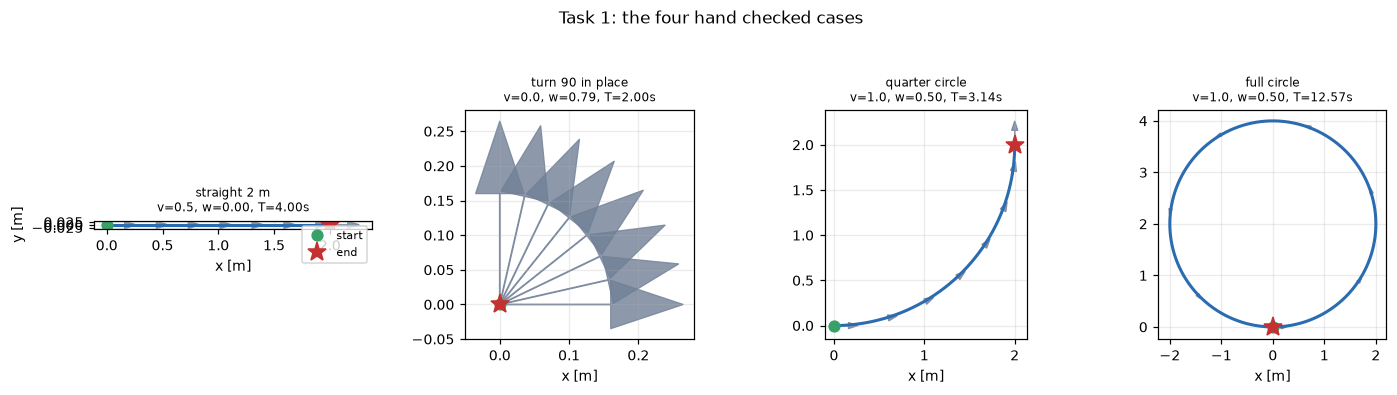

In [130]:
fig, axes = plt.subplots(1, 4, figsize=(13, 3.3))
for ax, (name, v, w, T, _) in zip(axes, CASES):
    traj = trajectories[name]
    ax.plot(traj[:, 0], traj[:, 1], lw=2, color="#2b6cb0")
    ax.plot(*traj[0, :2], "o", color="#38a169", ms=7, label="start")
    ax.plot(*traj[-1, :2], "*", color="#c53030", ms=13, label="end")

    # Draw a few heading arrows so the direction of travel is visible, not just the shape.
    for k in np.linspace(0, len(traj) - 1, 8, dtype=int):
        x, y, th = traj[k]
        ax.arrow(x, y, 0.16 * np.cos(th), 0.16 * np.sin(th),
                 head_width=0.07, color="#718096", lw=0.8, alpha=0.8)

    ax.set_title(f"{name}\nv={v:.1f}, w={w:.2f}, T={T:.2f}s", fontsize=8)
    ax.set_aspect("equal")
    ax.set_xlabel("x [m]")

axes[0].set_ylabel("y [m]")
axes[0].legend(fontsize=7, loc="best")
fig.suptitle("Task 1: the four hand checked cases", y=1.06, fontsize=11)
plt.tight_layout(); plt.show()

## 1.3 Exact arc versus Euler

The same four cases through both integrators at a range of step sizes. For a constant twist the
arc formula is exact, so its error stays at machine precision however coarse the step gets.
Euler's error is proportional to the step size, and it is a consistent under turn rather than
random scatter, which is why the full circle case never quite closes.

At the 0.05 s step used later, Euler would be about 3.5 cm out over these short runs. That is
the same size as the sensor noise added in Task 2, so we would have had trouble telling
modelling error apart from sensor error.

  dt [s]     exact arc error [m]     Euler error [m]
----------------------------------------------------
    0.50                1.34e-15            3.41e-01
    0.20                2.70e-14            1.43e-01
    0.05                9.60e-14            3.54e-02
    0.01                1.91e-13            7.07e-03


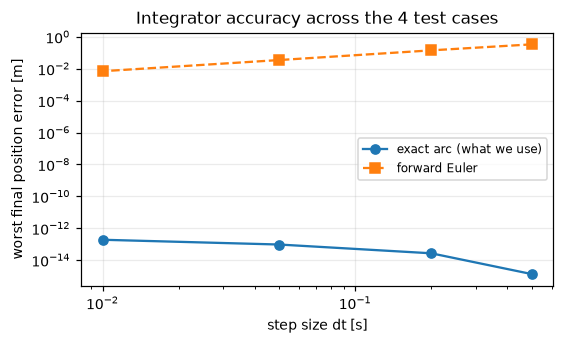

In [131]:
dts = [0.5, 0.2, 0.05, 0.01]
rows = []

for dt in dts:
    row = [dt]
    for step_fn in (unicycle_step, unicycle_step_euler):
        worst = 0.0
        for _, v, w, T, _ in CASES:
            n = int(round(T / dt))
            # Compare against the closed form at the duration actually simulated (n*dt) so
            # that rounding the duration to a whole number of steps is not counted as error.
            got = simulate([0, 0, 0], [(v, w)] * n, dt, step_fn)[-1]
            want = analytic_const_twist(v, w, n * dt)
            worst = max(worst, np.linalg.norm(got[:2] - want[:2]))
        row.append(worst)
    rows.append(row)

print(f"{'dt [s]':>8}{'exact arc error [m]':>24}{'Euler error [m]':>20}")
print("-" * 52)
for dt, e_exact, e_euler in rows:
    print(f"{dt:>8.2f}{e_exact:>24.2e}{e_euler:>20.2e}")

fig, ax = plt.subplots(figsize=(5.2, 3.2))
r = np.array(rows)
# Clamp the exact arc curve away from zero so it can be drawn on a log axis.
ax.loglog(r[:, 0], np.maximum(r[:, 1], 1e-17), "o-", label="exact arc (what we use)")
ax.loglog(r[:, 0], r[:, 2], "s--", label="forward Euler")
ax.set_xlabel("step size dt [s]")
ax.set_ylabel("worst final position error [m]")
ax.set_title("Integrator accuracy across the 4 test cases")
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

## 1.4 Task 1 tests

As well as the four hand checks, most of these test properties the model should have whatever
the numbers are: splitting a command in half changes nothing, starting somewhere else shifts the
whole path, the robot stays a constant distance from the centre of its turn. Those catch sign
errors and swapped arguments that one worked example can miss.

In [132]:
# ---------------------------------------------------------------- angles
@test("Task 1")
def test_wrap_to_pi_on_known_angles():
    assert close(wrap_to_pi(0.0), 0.0)
    assert close(wrap_to_pi(np.pi), np.pi)               # +pi stays put
    assert close(wrap_to_pi(-np.pi), np.pi)              # -pi maps onto +pi
    assert close(wrap_to_pi(3 * np.pi), np.pi)
    assert close(wrap_to_pi(2 * np.pi + 0.3), 0.3)
    assert close(wrap_to_pi(-2 * np.pi - 0.3), -0.3)


@test("Task 1")
def test_wrap_to_pi_always_lands_in_range():
    a = make_rng(1001).uniform(-100, 100, 5000)
    wrapped = wrap_to_pi(a)
    assert np.all(wrapped > -np.pi - 1e-12) and np.all(wrapped <= np.pi + 1e-12)
    # Wrapping must only change the angle by whole turns.
    turns = (a - wrapped) / (2 * np.pi)
    assert close(turns, np.round(turns), 1e-9)


# --------------------------------------------------- the four hand checks
@test("Task 1")
def test_straight_line_matches_hand_calculation():
    got = simulate([0, 0, 0], [(0.5, 0.0)] * 1000, 4.0 / 1000)[-1]
    assert poses_close(got, [2.0, 0.0, 0.0]), got


@test("Task 1")
def test_turning_in_place_matches_hand_calculation():
    got = simulate([0, 0, 0], [(0.0, np.pi / 4)] * 1000, 2.0 / 1000)[-1]
    assert poses_close(got, [0.0, 0.0, np.pi / 2]), got


@test("Task 1")
def test_quarter_circle_matches_hand_calculation():
    got = simulate([0, 0, 0], [(1.0, 0.5)] * 1000, np.pi / 1000)[-1]
    assert poses_close(got, [2.0, 2.0, np.pi / 2]), got


@test("Task 1")
def test_full_circle_returns_to_the_start():
    got = simulate([0, 0, 0], [(1.0, 0.5)] * 1000, 4 * np.pi / 1000)[-1]
    assert poses_close(got, [0.0, 0.0, 0.0]), got


# ------------------------------------------------- properties of the model
@test("Task 1")
def test_a_zero_command_does_nothing():
    p = np.array([1.3, -0.7, 0.9])
    assert poses_close(unicycle_step(p, 0.0, 0.0, 0.1), p)


@test("Task 1")
def test_step_size_does_not_change_the_answer():
    # For a constant twist the arc form is exact, so 10 steps and 10000 steps must agree.
    coarse = simulate([0, 0, 0], [(0.8, 0.4)] * 10, 3.0 / 10)[-1]
    fine = simulate([0, 0, 0], [(0.8, 0.4)] * 10000, 3.0 / 10000)[-1]
    assert poses_close(coarse, fine, 1e-9), (coarse, fine)


@test("Task 1")
def test_the_two_branches_agree_near_zero_turn_rate():
    # Just above the threshold we take the arc branch, just below it the straight branch.
    # If they disagreed there would be a jump in behaviour at the crossover.
    p = np.array([0.4, 1.1, 0.6])
    arc = unicycle_step(p, 0.5, 1e-8, 0.05)
    straight = unicycle_step(p, 0.5, 0.0, 0.05)
    assert poses_close(arc, straight, 1e-9)


@test("Task 1")
def test_negative_speed_reverses_along_the_heading():
    p = np.array([2.0, 1.0, 0.0])
    assert poses_close(unicycle_step(p, -0.5, 0.0, 2.0), [1.0, 1.0, 0.0])


@test("Task 1")
def test_negative_turn_rate_turns_clockwise():
    got = unicycle_step([0, 0, 0], 0.0, -1.0, 1.0)
    assert got[2] < 0, got
    # And a left turn of the same size should mirror it exactly.
    left = simulate([0, 0, 0], [(0.6, 0.8)] * 200, 0.01)[-1]
    right = simulate([0, 0, 0], [(0.6, -0.8)] * 200, 0.01)[-1]
    assert close(left[0], right[0]) and close(left[1], -right[1])


@test("Task 1")
def test_distance_from_the_turn_centre_stays_constant():
    # Driving a constant twist traces a circle, so every pose on it is the same distance R
    # from the centre of curvature. The centre sits at R to the left of the starting heading.
    v, w = 0.7, 0.55
    R = v / w
    traj = simulate([0, 0, 0], [(v, w)] * 500, 0.01)
    centre = np.array([0.0, R])
    radii = np.linalg.norm(traj[:, :2] - centre, axis=1)
    assert close(radii, R, 1e-9), (radii.min(), radii.max())


@test("Task 1")
def test_splitting_a_command_in_half_changes_nothing():
    p = np.array([1.0, 2.0, 0.3])
    once = unicycle_step(p, 0.6, 0.4, 0.2)
    twice = unicycle_step(unicycle_step(p, 0.6, 0.4, 0.1), 0.6, 0.4, 0.1)
    assert poses_close(once, twice)


@test("Task 1")
def test_starting_somewhere_else_just_shifts_the_path():
    cmds = [(0.5, 0.3)] * 200
    base = simulate([0, 0, 0], cmds, 0.02)
    shifted = simulate([3.0, -1.5, 0.0], cmds, 0.02)
    assert close(shifted[:, :2] - base[:, :2], np.array([3.0, -1.5]))
    assert close(shifted[:, 2], base[:, 2])


@test("Task 1")
def test_starting_at_a_different_heading_rotates_the_path():
    cmds = [(0.5, 0.3)] * 200
    a = np.deg2rad(37.0)
    base = simulate([0, 0, 0], cmds, 0.02)
    rotated = simulate([0, 0, a], cmds, 0.02)
    R = np.array([[np.cos(a), -np.sin(a)], [np.sin(a), np.cos(a)]])
    assert close(rotated[:, :2], base[:, :2] @ R.T, 1e-9)
    assert close(wrap_to_pi(rotated[:, 2] - base[:, 2] - a), 0.0, 1e-9)


@test("Task 1")
def test_distance_travelled_matches_speed_times_time():
    v, T, n = 0.45, 6.0, 600
    traj = simulate([0, 0, 0], [(v, 0.35)] * n, T / n)
    length = np.sum(np.linalg.norm(np.diff(traj[:, :2], axis=0), axis=1))
    # The path is made of straight chords across each arc, so the measured length is a hair
    # short of the true arc length. A tenth of a percent is plenty of room.
    assert abs(length - v * T) < 1e-3 * v * T, length


@test("Task 1")
def test_euler_error_shrinks_as_the_step_shrinks():
    def euler_error(dt):
        n = int(round(3.0 / dt))
        got = simulate([0, 0, 0], [(1.0, 0.6)] * n, dt, unicycle_step_euler)[-1]
        return np.linalg.norm(got[:2] - analytic_const_twist(1.0, 0.6, n * dt)[:2])
    coarse, fine = euler_error(0.2), euler_error(0.02)
    assert fine < coarse / 5, (coarse, fine)     # roughly first order, so about 10x better


# ------------------------------------------------------- differential drive
@test("Task 1")
def test_wheel_speeds_round_trip():
    for v, w in [(0.4, 0.7), (0.0, 1.2), (-0.3, 0.0), (0.55, -0.9)]:
        assert close(ROBOT.wheels_to_twist(*ROBOT.twist_to_wheels(v, w)), (v, w))


@test("Task 1")
def test_equal_wheel_speeds_drive_straight():
    v, w = ROBOT.wheels_to_twist(5.0, 5.0)
    assert close(w, 0.0) and close(v, ROBOT.wheel_radius * 5.0)


@test("Task 1")
def test_opposite_wheel_speeds_spin_on_the_spot():
    v, w = ROBOT.wheels_to_twist(-4.0, 4.0)
    assert close(v, 0.0) and w > 0


@test("Task 1")
def test_clamping_keeps_both_wheels_inside_the_limit():
    for v, w in [(3.0, 0.0), (0.0, 9.0), (2.5, -4.0)]:
        wl, wr = ROBOT.twist_to_wheels(*ROBOT.clamp_twist(v, w))
        assert max(abs(wl), abs(wr)) <= ROBOT.max_wheel_rate + 1e-9


@test("Task 1")
def test_clamping_keeps_the_path_curvature():
    v, w = 3.0, 1.5
    vc, wc = ROBOT.clamp_twist(v, w)
    assert vc < v                            # it really was clamped
    assert close(vc / wc, v / w, 1e-9)       # same radius of curvature


@test("Task 1")
def test_clamping_leaves_slow_commands_alone():
    assert close(ROBOT.clamp_twist(0.2, 0.3), (0.2, 0.3))


run_tests("Task 1")

  pass    wrap to pi on known angles
  pass    wrap to pi always lands in range
  pass    straight line matches hand calculation
  pass    turning in place matches hand calculation
  pass    quarter circle matches hand calculation
  pass    full circle returns to the start
  pass    a zero command does nothing
  pass    step size does not change the answer
  pass    the two branches agree near zero turn rate
  pass    negative speed reverses along the heading
  pass    negative turn rate turns clockwise
  pass    distance from the turn centre stays constant
  pass    splitting a command in half changes nothing
  pass    starting somewhere else just shifts the path
  pass    starting at a different heading rotates the path
  pass    distance travelled matches speed times time
  pass    euler error shrinks as the step shrinks
  pass    wheel speeds round trip
  pass    equal wheel speeds drive straight
  pass    opposite wheel speeds spin on the spot
  pass    clamping keeps both wheels 

23

---
# Task 2: Environment and Sensor Simulation

Three pieces, all driven by one `NoiseParams` object:

1. **The room.** An 8 m by 6 m household space with furniture as rectangular obstacles, a
   kitchen counter and partition wall that leave a single 1.2 m doorway, and 5 landmarks.
2. **Noisy odometry.** Noise goes in at the velocity level, so the error enters through the
   commands and then compounds through the integrator, which is how wheel slip actually behaves.
3. **Noisy sensing of the outside world.** Range and bearing to landmarks, which Task 4's EKF
   uses, and a 180 beam lidar, which Task 5 uses to build the map.

## 2.1 The room

We laid the room out to be a bit awkward on purpose. The counter and the partition split it into
a living area on the left and a kitchen on the right, joined by one doorway. A straight line
from the start pose to the goal runs into the partition, so Task 3's planner has something real
to do. The doorway also makes a stretch where the robot can see very few landmarks, which is
what we wanted for Task 4.

Two targets are marked for the arm. The **light switch** on the right hand wall at $x = 7.98$ m,
$y = 4.8$ m sits 1.02 m off the floor, and is the target for the switch press. The **person**
seated near the dining table is the target for the handover.

In [133]:
@dataclass
class Rect:
    """An axis aligned rectangular obstacle, given by its lower left corner and its size.

    `full_height` marks the obstacles that block both sensors. We put the lidar low on the
    chassis and the landmark camera up on a mast, so low furniture hides things from the lidar
    but not from the camera. Only the partition wall and the bookshelf block both.
    """
    x: float
    y: float
    w: float
    h: float
    name: str = ""
    full_height: bool = False

    @property
    def bounds(self):
        """(xmin, ymin, xmax, ymax)."""
        return self.x, self.y, self.x + self.w, self.y + self.h

    def contains(self, pt, margin=0.0):
        """True if `pt` is inside the rectangle, optionally grown by `margin` on each side."""
        x0, y0, x1, y1 = self.bounds
        return (x0 - margin <= pt[0] <= x1 + margin) and (y0 - margin <= pt[1] <= y1 + margin)

    def distance_to(self, pt):
        """Shortest distance from `pt` to the rectangle. Zero if the point is inside it.

        A round robot collides exactly when this is less than its radius. Growing the box by
        the radius instead would be too strict at the corners.
        """
        x0, y0, x1, y1 = self.bounds
        dx = max(x0 - pt[0], 0.0, pt[0] - x1)
        dy = max(y0 - pt[1], 0.0, pt[1] - y1)
        return float(np.hypot(dx, dy))


@dataclass
class Room:
    """The world: its extent, its furniture, its landmarks and the arm's two targets."""
    width: float
    height: float
    furniture: List[Rect]
    landmarks: np.ndarray             # (N, 2) positions of the range and bearing beacons
    switch_xy: Tuple[float, float]    # wall switch, the target for the switch press
    switch_z: float                   # its height off the floor [m]
    person_xy: Tuple[float, float]    # seated person, the target for the handover
    person_z: float

    def clearance(self, pt):
        """Distance from `pt` to the nearest obstacle or wall. Negative outside the room."""
        to_wall = min(pt[0], self.width - pt[0], pt[1], self.height - pt[1])
        to_furniture = min((f.distance_to(pt) for f in self.furniture), default=np.inf)
        return min(to_wall, to_furniture)

    def is_free(self, pt, margin=0.0):
        """True if a disc of radius `margin` centred on `pt` fits without touching anything.

        The comparison has to be strict: clearance bottoms out at 0 inside an obstacle, so with
        `>=` a point in the middle of the sofa would come back free at a margin of 0.
        """
        return self.clearance(pt) > margin


def build_room() -> Room:
    """The household layout. All dimensions in metres."""
    furniture = [
        Rect(0.60, 4.20, 2.40, 0.90, "sofa"),
        Rect(1.20, 2.70, 1.20, 0.70, "coffee table"),
        Rect(0.30, 0.30, 1.70, 0.50, "tv stand"),
        Rect(3.40, 0.00, 0.55, 2.40, "kitchen counter"),
        Rect(3.40, 3.60, 0.55, 2.40, "partition wall", full_height=True),
        Rect(4.90, 3.40, 1.80, 1.00, "dining table"),
        Rect(5.10, 2.60, 0.50, 0.50, "chair A"),
        Rect(6.20, 2.60, 0.50, 0.50, "chair B"),
        Rect(7.35, 0.80, 0.55, 2.00, "bookshelf", full_height=True),
    ]
    # The counter runs up to y = 2.40 and the partition starts at y = 3.60, so the gap between
    # them is the 1.2 m doorway, the only way through.

    landmarks = np.array([
        [0.25, 5.75],   # L0, far corner of the living room
        [0.25, 0.25],   # L1, near corner of the living room
        [3.72, 2.40],   # L2, corner of the counter, right at the doorway
        [7.75, 0.25],   # L3, near corner of the kitchen
        [7.75, 5.75],   # L4, far corner of the kitchen, the closest one to the goal
    ])

    return Room(width=8.0, height=6.0, furniture=furniture, landmarks=landmarks,
                switch_xy=(7.98, 4.80), switch_z=1.02,
                person_xy=(5.80, 4.75), person_z=0.95)


ROOM = build_room()
ROBOT_RADIUS = 0.22    # the base is a 0.44 m disc, used for every clearance check

# The poses every later task works between: start in the living room, finish square on to the
# kitchen wall with the switch in front of the robot.
START_POSE = np.array([1.00, 1.60, 0.0])
GOAL_POSE = np.array([7.05, 4.80, 0.0])

print(f"Room {ROOM.width} x {ROOM.height} m, {len(ROOM.furniture)} obstacles, "
      f"{len(ROOM.landmarks)} landmarks")
print(f"start clearance {ROOM.clearance(START_POSE[:2]):.2f} m, "
      f"goal clearance {ROOM.clearance(GOAL_POSE[:2]):.2f} m "
      f"(robot radius {ROBOT_RADIUS} m)")

Room 8.0 x 6.0 m, 9 obstacles, 5 landmarks
start clearance 0.80 m, goal clearance 0.53 m (robot radius 0.22 m)


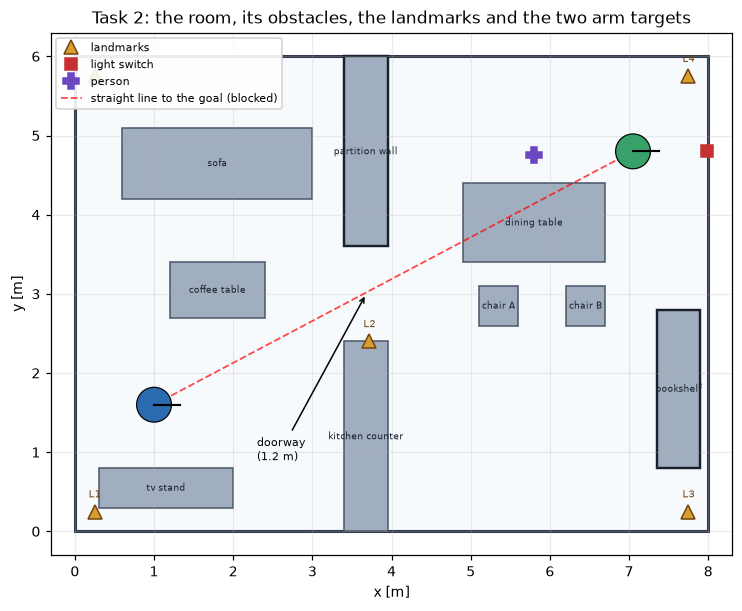

In [134]:
def draw_room(ax, room=ROOM, landmarks=True, targets=True, labels=False):
    """Draw the room, its furniture and optionally the landmarks and targets.

    Reused by every figure in the notebook so that all the maps look the same.
    """
    ax.add_patch(Rectangle((0, 0), room.width, room.height, fc="#f7fafc",
                           ec="#2d3748", lw=2, zorder=0))
    for f in room.furniture:
        # Tall obstacles get a darker edge, since they are the ones that hide landmarks.
        ax.add_patch(Rectangle((f.x, f.y), f.w, f.h, fc="#a0aec0",
                               ec="#1a202c" if f.full_height else "#4a5568",
                               lw=1.6 if f.full_height else 1.0, zorder=1))
        if labels:
            ax.text(f.x + f.w / 2, f.y + f.h / 2, f.name, ha="center", va="center",
                    fontsize=6, color="#1a202c", zorder=3)

    if landmarks:
        ax.plot(room.landmarks[:, 0], room.landmarks[:, 1], "^", color="#d69e2e",
                ms=9, mec="#744210", zorder=4, label="landmarks")
        for i, (lx, ly) in enumerate(room.landmarks):
            ax.text(lx, ly + 0.18, f"L{i}", ha="center", fontsize=6.5,
                    color="#744210", zorder=4)

    if targets:
        ax.plot(*room.switch_xy, "s", color="#c53030", ms=8, zorder=4, label="light switch")
        ax.plot(*room.person_xy, "P", color="#6b46c1", ms=10, zorder=4, label="person")

    ax.set_xlim(-0.3, room.width + 0.3)
    ax.set_ylim(-0.3, room.height + 0.3)
    ax.set_aspect("equal")
    ax.set_xlabel("x [m]"); ax.set_ylabel("y [m]")


def draw_robot(ax, pose, color="#2b6cb0", radius=ROBOT_RADIUS, alpha=1.0, zorder=5):
    """Draw the base as a disc with a line showing which way it is facing."""
    x, y, th = pose
    ax.add_patch(Circle((x, y), radius, fc=color, ec="black", lw=0.8,
                        alpha=alpha, zorder=zorder))
    ax.plot([x, x + radius * 1.5 * np.cos(th)], [y, y + radius * 1.5 * np.sin(th)],
            color="black", lw=1.4, alpha=alpha, zorder=zorder + 1)


fig, ax = plt.subplots(figsize=(7.2, 5.6))
draw_room(ax, labels=True)
draw_robot(ax, START_POSE)
draw_robot(ax, GOAL_POSE, color="#38a169")
ax.plot([START_POSE[0], GOAL_POSE[0]], [START_POSE[1], GOAL_POSE[1]], "r--", lw=1.2,
        alpha=0.7, label="straight line to the goal (blocked)")
ax.annotate("doorway\n(1.2 m)", xy=(3.68, 3.0), xytext=(2.3, 0.9), fontsize=7.5,
            arrowprops=dict(arrowstyle="->", lw=1))
ax.set_title("Task 2: the room, its obstacles, the landmarks and the two arm targets")
ax.legend(fontsize=7, loc="upper left", framealpha=0.9)
plt.tight_layout(); plt.show()

### Ground truth occupancy grid

The same room rasterised at 5 cm. The robot never sees this. It is the reference that Task 5's
estimated map gets compared against.

grid 160 x 120 = 19200 cells, 20.6% occupied
furniture covers 9.89 m^2 of 48 m^2 (20.6%)


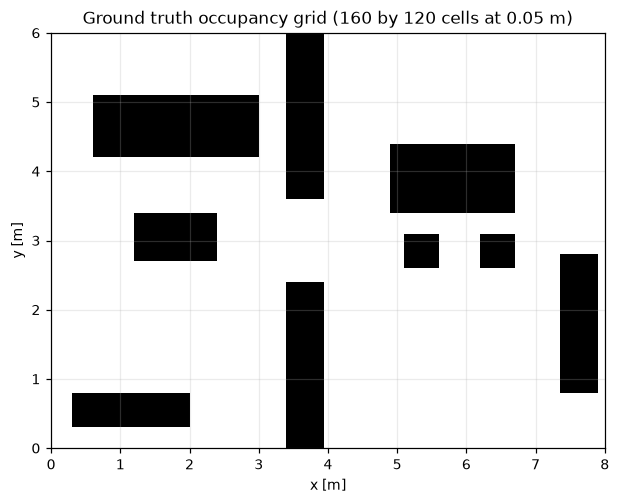

In [135]:
GRID_RES = 0.05   # metres per cell

def rasterize(room=ROOM, res=GRID_RES):
    """Ground truth occupancy: 1 where a cell centre lands in furniture, 0 elsewhere.

    Indexed [row, col] = [y, x], which is what imshow(origin="lower") expects.
    """
    nx, ny = int(round(room.width / res)), int(round(room.height / res))
    xs = (np.arange(nx) + 0.5) * res      # cell centres, not edges
    ys = (np.arange(ny) + 0.5) * res
    X, Y = np.meshgrid(xs, ys)

    occ = np.zeros((ny, nx), dtype=np.uint8)
    for f in room.furniture:
        x0, y0, x1, y1 = f.bounds
        occ |= ((X >= x0) & (X <= x1) & (Y >= y0) & (Y <= y1)).astype(np.uint8)
    return occ, (nx, ny)


GT_GRID, (NX, NY) = rasterize()

fig, ax = plt.subplots(figsize=(6.0, 4.6))
ax.imshow(GT_GRID, origin="lower", cmap="Greys", extent=[0, ROOM.width, 0, ROOM.height],
          vmin=0, vmax=1)
ax.set_title(f"Ground truth occupancy grid ({NX} by {NY} cells at {GRID_RES} m)")
ax.set_xlabel("x [m]"); ax.set_ylabel("y [m]")

furniture_area = sum(f.w * f.h for f in ROOM.furniture)
print(f"grid {NX} x {NY} = {GT_GRID.size} cells, {GT_GRID.mean() * 100:.1f}% occupied")
print(f"furniture covers {furniture_area:.2f} m^2 of {ROOM.width * ROOM.height:.0f} m^2 "
      f"({100 * furniture_area / (ROOM.width * ROOM.height):.1f}%)")
plt.tight_layout(); plt.show()

## 2.2 Noise settings

Every noise source reads from one object, and a single `scale` multiplier moves all of them
together. Section 2.7 uses that to show the noise really is tunable rather than just present.

### Odometry

The noise goes in at the velocity level, following the velocity motion model in Thrun's
*Probabilistic Robotics*, rather than being added to the finished pose as a random walk:

$$\hat v = v + \varepsilon(\alpha_1 v^2 + \alpha_2 \omega^2), \quad
  \hat\omega = \omega + \varepsilon(\alpha_3 v^2 + \alpha_4 \omega^2), \quad
  \hat\gamma = \varepsilon(\alpha_5 v^2 + \alpha_6 \omega^2)$$

where $\varepsilon(b)$ is a zero mean Gaussian of variance $b$. The corrupted twist then goes
through the same `unicycle_step` from Task 1, and $\hat\gamma$ adds a small extra turn at the
end of the step, which covers the base finishing a step slightly rotated from where the arc
alone would put it.

Two things follow from this and both matter later. The error is **proportional to the motion**,
so standing still adds none and turning fast adds the most, and it is **integrated**, so a
heading error rotates everything that happens after it. Errors grow faster than linearly with
distance as a result. It is that structure a filter can work against, which is Task 4.

### Landmarks and lidar

Range noise has a fixed part plus a part proportional to the range, which is how a real time of
flight sensor behaves. Bearing noise is constant. Landmarks are also subject to a detection
probability and to occlusion, so a beacon behind the partition simply is not reported.

In [136]:
@dataclass
class NoiseParams:
    """Every noise magnitude in the simulator, in one place."""

    # --- odometry, the alphas of the velocity motion model ------------------
    a1: float = 0.06   # noise on v from v^2, i.e. slip while driving
    a2: float = 0.02   # noise on v from w^2
    a3: float = 0.02   # noise on w from v^2, i.e. veering while driving straight
    a4: float = 0.10   # noise on w from w^2, turning is the worst offender
    a5: float = 0.005  # extra end of step rotation, from v^2
    a6: float = 0.010  # extra end of step rotation, from w^2

    # --- landmark range and bearing sensor ---------------------------------
    sigma_r0: float = 0.035              # range noise, fixed part [m]
    sigma_r1: float = 0.012              # range noise, per metre of range [m/m]
    sigma_b: float = np.deg2rad(1.6)     # bearing noise [rad]
    lm_max_range: float = 8.0            # [m], comfortably under the 10 m room diagonal
    lm_fov: float = np.deg2rad(360.0)    # a ring sensor, so it sees all round
    lm_p_detect: float = 0.92            # chance of getting a reading from a visible landmark
    lm_occlusion: bool = True            # tall obstacles block the line of sight

    # --- lidar --------------------------------------------------------------
    n_beams: int = 180
    lidar_max_range: float = 5.0         # [m]
    sigma_lidar: float = 0.02            # range noise [m]
    lidar_p_dropout: float = 0.01        # fraction of beams that return nothing at all

    def scaled(self, s: float) -> "NoiseParams":
        """Return a copy with every noise magnitude multiplied by `s`.

        The alphas are variances, so they scale by s^2 to make the standard deviations scale by
        s. s = 0 is a perfect simulator, s = 1 is the settings above.
        """
        return replace(
            self,
            a1=self.a1 * s**2, a2=self.a2 * s**2, a3=self.a3 * s**2,
            a4=self.a4 * s**2, a5=self.a5 * s**2, a6=self.a6 * s**2,
            sigma_r0=self.sigma_r0 * s, sigma_r1=self.sigma_r1 * s, sigma_b=self.sigma_b * s,
            # A perfect sensor never misses, so the miss rate shrinks towards zero with s.
            lm_p_detect=1 - (1 - self.lm_p_detect) * s,
            sigma_lidar=self.sigma_lidar * s,
            lidar_p_dropout=self.lidar_p_dropout * s)


NOISE = NoiseParams()

print("odometry alphas   :", [NOISE.a1, NOISE.a2, NOISE.a3, NOISE.a4, NOISE.a5, NOISE.a6])
print(f"landmark noise    : {NOISE.sigma_r0} m + {NOISE.sigma_r1} m per m of range, "
      f"{np.rad2deg(NOISE.sigma_b):.1f} deg bearing")
print(f"landmark sensor   : {NOISE.lm_max_range} m range, "
      f"{NOISE.lm_p_detect:.0%} detection, occlusion {'on' if NOISE.lm_occlusion else 'off'}")
print(f"lidar             : {NOISE.n_beams} beams, {NOISE.lidar_max_range} m range, "
      f"{NOISE.sigma_lidar} m noise, {NOISE.lidar_p_dropout:.0%} dropout")

odometry alphas   : [0.06, 0.02, 0.02, 0.1, 0.005, 0.01]
landmark noise    : 0.035 m + 0.012 m per m of range, 1.6 deg bearing
landmark sensor   : 8.0 m range, 92% detection, occlusion on
lidar             : 180 beams, 5.0 m range, 0.02 m noise, 1% dropout


In [137]:
def sample_odometry(v, w, params: NoiseParams, rng):
    """Corrupt a commanded twist with velocity level noise.

    Returns (v_hat, w_hat, gamma_hat), where gamma_hat is an extra turn *rate* for the end of
    the step. There is no dt here because the noise scales with the commanded speeds; the
    caller applies the step length.
    """
    sd = lambda var: np.sqrt(max(var, 0.0))   # guard against -0.0 from a scale of 0
    v_hat = v + rng.normal(0.0, sd(params.a1 * v**2 + params.a2 * w**2))
    w_hat = w + rng.normal(0.0, sd(params.a3 * v**2 + params.a4 * w**2))
    g_hat = rng.normal(0.0, sd(params.a5 * v**2 + params.a6 * w**2))
    return v_hat, w_hat, g_hat


def odom_step(pose, v, w, dt, params: NoiseParams, rng):
    """One step of dead reckoning: the Task 1 integrator fed a corrupted command."""
    v_hat, w_hat, g_hat = sample_odometry(v, w, params, rng)
    new = unicycle_step(pose, v_hat, w_hat, dt)
    new[2] = wrap_to_pi(new[2] + g_hat * dt)
    return new


# Quick check that turning the noise off gets Task 1 back exactly. There is a proper test for
# this further down; this one is here so a failure shows up next to the code that caused it.
_p = np.array([1.0, 2.0, 0.3])
assert poses_close(odom_step(_p, 0.4, 0.3, 0.1, NOISE.scaled(0.0), make_rng(99)),
                   unicycle_step(_p, 0.4, 0.3, 0.1))
print("with noise switched off, odometry reduces to the Task 1 model")

with noise switched off, odometry reduces to the Task 1 model


## 2.3 Ray casting

Both of the outward looking sensors need the same thing: how far along a ray before it hits
something. All of our obstacles are axis aligned boxes, so we used the slab method, which gives
an exact answer without stepping along the ray. For each axis the ray enters that axis's
interval at $t_1$ and leaves at $t_2$, and it only hits the box if the two intervals overlap,
i.e. if $\max t_{\text{enter}} \le \min t_{\text{exit}}$.

The walls are done separately, as the distance at which the ray leaves the room's bounding box,
since the robot is always inside it.

In [138]:
def ray_box_hit(p, d, box, eps=1e-12):
    """Distance along the ray (p, d) to an axis aligned box, or inf if it misses.

    p is the start point, d is a unit direction, box is (xmin, ymin, xmax, ymax).
    """
    x0, y0, x1, y1 = box
    t_enter, t_exit = -np.inf, np.inf

    for i, (lo, hi) in enumerate(((x0, x1), (y0, y1))):
        if abs(d[i]) < eps:
            # The ray runs parallel to this pair of edges, so it either stays inside the slab
            # forever or never enters it. No t constraint either way.
            if p[i] < lo or p[i] > hi:
                return np.inf
            continue
        t1, t2 = (lo - p[i]) / d[i], (hi - p[i]) / d[i]
        if t1 > t2:
            t1, t2 = t2, t1              # d is negative on this axis, so the order flipped
        t_enter, t_exit = max(t_enter, t1), min(t_exit, t2)
        if t_enter > t_exit:
            return np.inf                # the two slabs never overlap, so it misses

    if t_exit < 0:
        return np.inf                    # the box is entirely behind the ray
    # t_enter <= 0 means we started inside the box, so the first surface met is on the way out.
    return t_enter if t_enter > 0 else t_exit


def ray_room_exit(p, d, room, eps=1e-12):
    """Distance from a point inside the room to the walls, along the ray (p, d)."""
    t_exit = np.inf
    for i, (lo, hi) in enumerate(((0.0, room.width), (0.0, room.height))):
        if abs(d[i]) < eps:
            continue
        # From inside, the wall we hit on this axis is whichever of the two is ahead of us.
        t_exit = min(t_exit, max((lo - p[i]) / d[i], (hi - p[i]) / d[i]))
    return t_exit


def cast_ray(p, angle, room, max_range=np.inf, full_height_only=False):
    """Distance to the nearest obstacle or wall from p along `angle`, capped at max_range.

    full_height_only=True considers only obstacles tall enough to block the mast mounted
    landmark camera. The lidar, which is the default, sees everything.
    """
    d = np.array([np.cos(angle), np.sin(angle)])
    t = ray_room_exit(p, d, room)
    for f in room.furniture:
        if full_height_only and not f.full_height:
            continue
        t = min(t, ray_box_hit(p, d, f.bounds))
    return min(t, max_range)


# Five ranges that can be read straight off the furniture table above.
CAST_CHECKS = [
    # (from, heading [rad], expected range [m], what it hits)
    ((1.0, 1.60), 0.0,       2.40, "front of the kitchen counter at x = 3.40"),
    ((1.0, 1.60), np.pi,     1.00, "left wall at x = 0"),
    ((2.6, 3.20), 0.0,       5.40, "clean line through the doorway to the right wall at x = 8"),
    ((2.6, 3.20), np.pi / 2, 1.00, "near edge of the sofa at y = 4.20"),
    ((7.0, 4.80), 0.0,       1.00, "right wall at x = 8, which is where the switch is mounted"),
]

for p, a, expected, what in CAST_CHECKS:
    got = cast_ray(np.array(p), a, ROOM)
    print(f"  from {str(p):<12} heading {np.rad2deg(a):+6.1f} deg -> {got:5.2f} m   ({what})")
print("\n(these are asserted in the Task 2 test block)")

  from (1.0, 1.6)   heading   +0.0 deg ->  2.40 m   (front of the kitchen counter at x = 3.40)
  from (1.0, 1.6)   heading +180.0 deg ->  1.00 m   (left wall at x = 0)
  from (2.6, 3.2)   heading   +0.0 deg ->  5.40 m   (clean line through the doorway to the right wall at x = 8)
  from (2.6, 3.2)   heading  +90.0 deg ->  1.00 m   (near edge of the sofa at y = 4.20)
  from (7.0, 4.8)   heading   +0.0 deg ->  1.00 m   (right wall at x = 8, which is where the switch is mounted)

(these are asserted in the Task 2 test block)


## 2.4 The two sensors

**Lidar.** `n_beams` spread evenly round the full circle, each one cast, noised, then clipped.
Beams that hit nothing inside `lidar_max_range`, and beams dropped at random, come back as
`inf`. Task 5 has to read that as "free all the way out to the maximum range" rather than "an
obstacle at the maximum range", otherwise the map ends up with a ring of walls that are not
there.

**Landmarks.** For each one: skip it if it is out of range or outside the field of view, skip
it if something tall is in the way, skip it at random with probability $1 - p_{\text{detect}}$,
and otherwise return a noisy $(\text{id}, r, b)$ with the bearing measured relative to the
robot's own heading.

The occlusion test only casts against full height obstacles, for the reason in the `Rect`
docstring. That is what gives landmark visibility any structure: going through the doorway swaps
which half of the room's markers are in view, and the bookshelf hides the near kitchen corner
just as the robot is closing on the goal.

Each reading comes back with its landmark id, so correspondence is known. That is a
simplification we made on purpose. We are treating these as distinguishable beacons rather than
anonymous corners, which keeps Task 4 about filtering instead of data association.

In [139]:
def lidar_scan(pose, room, params: NoiseParams, rng, add_noise=True):
    """Simulated 2D lidar sweep.

    Returns (angles, ranges). The angles are relative to the robot's heading and the ranges are
    inf wherever the beam found nothing within lidar_max_range or was dropped.
    """
    x, y, th = pose
    p = np.array([x, y])
    angles = np.linspace(-np.pi, np.pi, params.n_beams, endpoint=False)
    ranges = np.empty(params.n_beams)

    for i, a in enumerate(angles):
        r = cast_ray(p, th + a, room)      # true distance, uncapped

        if r >= params.lidar_max_range:
            ranges[i] = np.inf             # nothing close enough to see
            continue

        if add_noise:
            if rng.random() < params.lidar_p_dropout:
                ranges[i] = np.inf         # beam lost, e.g. a dark or glancing surface
                continue
            r = r + rng.normal(0.0, params.sigma_lidar)

        ranges[i] = np.clip(r, 0.0, params.lidar_max_range)

    return angles, ranges


def observe_landmarks(pose, room, params: NoiseParams, rng, add_noise=True):
    """Range and bearing readings to the landmarks the robot can currently see.

    Returns a list of (landmark_id, range, bearing), bearing relative to the robot's heading.
    """
    x, y, th = pose
    p = np.array([x, y])
    obs = []

    for i, lm in enumerate(room.landmarks):
        dx, dy = lm - p
        r = float(np.hypot(dx, dy))
        b = wrap_to_pi(np.arctan2(dy, dx) - th)

        if r > params.lm_max_range or abs(b) > params.lm_fov / 2:
            continue

        # Cast towards the landmark and see whether anything tall gets there first. The small
        # tolerance stops a landmark sitting flat against a wall from occluding itself.
        if params.lm_occlusion and cast_ray(p, np.arctan2(dy, dx), room,
                                            full_height_only=True) < r - 1e-6:
            continue

        if add_noise:
            if rng.random() > params.lm_p_detect:
                continue                                   # missed this one
            r = r + rng.normal(0.0, params.sigma_r0 + params.sigma_r1 * r)
            b = wrap_to_pi(b + rng.normal(0.0, params.sigma_b))

        obs.append((i, float(r), float(b)))

    return obs


_clean = observe_landmarks(START_POSE, ROOM, NOISE.scaled(0.0), make_rng(1))
print(f"noise free readings from the start pose ({len(_clean)} of {len(ROOM.landmarks)} visible):")
for i, r, b in _clean:
    print(f"   L{i}: range {r:5.2f} m, bearing {np.rad2deg(b):+7.1f} deg")

noise free readings from the start pose (5 of 5 visible):
   L0: range  4.22 m, bearing  +100.2 deg
   L1: range  1.54 m, bearing  -119.1 deg
   L2: range  2.84 m, bearing   +16.4 deg
   L3: range  6.88 m, bearing   -11.3 deg
   L4: range  7.92 m, bearing   +31.6 deg


## 2.5 A reference drive, and what dead reckoning makes of it

An open loop command sequence takes the base from the living room, through the doorway, past the
dining table and up to the goal in front of the kitchen wall. Each leg is a turn on the spot
followed by a straight run. It is not a clever path and is not meant to be; Task 3 replaces the
waypoints with a planned one. This is here so Tasks 2, 4 and 5 have something to run on before
the planner exists.

One detail that took us a couple of tries: the turn rate and speed for each leg are back solved
from a whole number of steps, so with no noise the trajectory lands exactly on each waypoint
instead of overshooting by part of a step. That lets us assert the drive reaches the goal
exactly, so any drift below has to be the noise model rather than sloppy command generation.

The same commands are then integrated twice from the same starting pose:

- the **true pose**, using the clean `unicycle_step`, which is the ground truth the simulator
  keeps to itself,
- the **odometry pose**, using `odom_step`, which is what the robot would believe if it only
  had wheel encoders.

The gap between those two is the error Task 4 has to get rid of. It is not a constant offset: a
heading error picked up in the first turn rotates everything after it, which is why the gap
keeps opening up.

In [140]:
DT = 0.05   # simulation step from here on [s]

# Waypoints chosen by hand: across the living room, through the doorway, along the near side of
# the dining table, then up the right hand side to the goal.
WAYPOINTS = np.array([[2.60, 2.20],
                      [3.67, 3.00],    # middle of the 1.2 m doorway
                      [4.55, 3.00],    # step clear of the counter corner before turning down
                      [4.80, 2.05],
                      [7.00, 2.05],    # clear of both chairs and of the bookshelf
                      [7.05, 4.80]])   # the goal, in front of the switch wall


def waypoint_commands(start, waypoints, final_heading, dt=DT, v_max=0.45, w_max=0.70):
    """Open loop turn then drive commands through a list of waypoints.

    Each leg is a turn on the spot then a straight run, both quantised to a whole number of
    steps with the rate back solved (w = dtheta / (n * dt)), so with no noise the path lands on
    each waypoint exactly. Returns (commands, segment_end_times).
    """
    cmds, bounds = [], []
    pose = np.asarray(start, dtype=float)

    def rotate(dtheta):
        nonlocal pose
        n = max(1, int(np.ceil(abs(dtheta) / (w_max * dt))))
        w = dtheta / (n * dt)
        cmds.extend([(0.0, w)] * n)
        for _ in range(n):
            pose = unicycle_step(pose, 0.0, w, dt)
        bounds.append(len(cmds) * dt)

    def advance(dist):
        nonlocal pose
        n = max(1, int(np.ceil(dist / (v_max * dt))))
        v = dist / (n * dt)
        cmds.extend([(v, 0.0)] * n)
        for _ in range(n):
            pose = unicycle_step(pose, v, 0.0, dt)
        bounds.append(len(cmds) * dt)

    for wp in np.asarray(waypoints, dtype=float):
        dx, dy = wp - pose[:2]
        rotate(wrap_to_pi(np.arctan2(dy, dx) - pose[2]))   # face the waypoint
        advance(float(np.hypot(dx, dy)))                   # drive to it
    rotate(wrap_to_pi(final_heading - pose[2]))            # square up at the end

    return cmds, bounds


def run_drive(commands, params: NoiseParams, seed_stream=10, dt=DT, room=ROOM,
              start=START_POSE, scan_every=10):
    """Run the commands, recording the true pose, the odometry pose and the sensor readings.

    scan_every sets how often a full lidar sweep is taken. Sweeping every step is slow, and a
    real lidar runs slower than the control loop anyway. Set it very high to skip scans.
    """
    rng = make_rng(seed_stream)
    true_pose = np.array(start, dtype=float)
    odom_pose = np.array(start, dtype=float)

    log = dict(t=[0.0], true=[true_pose.copy()], odom=[odom_pose.copy()],
               cmds=[], obs=[], scans=[])

    for k, (v, w) in enumerate(commands):
        v, w = ROBOT.clamp_twist(v, w)                     # respect the wheel speed limit
        true_pose = unicycle_step(true_pose, v, w, dt)     # what actually happened
        odom_pose = odom_step(odom_pose, v, w, dt, params, rng)   # what the encoders say

        log["t"].append((k + 1) * dt)
        log["true"].append(true_pose.copy())
        log["odom"].append(odom_pose.copy())
        log["cmds"].append((v, w))
        # Sensors always read against the true pose. The robot does not get to peek at it.
        log["obs"].append(observe_landmarks(true_pose, room, params, rng))
        log["scans"].append(lidar_scan(true_pose, room, params, rng)
                            if k % scan_every == 0 else None)

    for key in ("t", "true", "odom"):
        log[key] = np.array(log[key])
    return log


CMDS, SEG_BOUNDS = waypoint_commands(START_POSE, WAYPOINTS, final_heading=GOAL_POSE[2])
LOG = run_drive(CMDS, NOISE)

final_err = np.linalg.norm(LOG["true"][-1][:2] - LOG["odom"][-1][:2])
head_err = np.rad2deg(abs(wrap_to_pi(LOG["true"][-1][2] - LOG["odom"][-1][2])))
path_len = np.sum(np.linalg.norm(np.diff(LOG["true"][:, :2], axis=0), axis=1))
min_clear = min(ROOM.clearance(p[:2]) for p in LOG["true"])
seen = np.array([len(o) for o in LOG["obs"]])

print(f"drive          : {len(CMDS)} steps, {len(CMDS) * DT:.1f} s, path length {path_len:.2f} m")
print(f"min clearance  : {min_clear:.3f} m (robot radius {ROBOT_RADIUS} m)")
print(f"true final pose: {np.round(LOG['true'][-1], 4)}")
print(f"odom final pose: {np.round(LOG['odom'][-1], 4)}")
print(f"dead reckoning error at the goal: {final_err:.3f} m and {head_err:.1f} deg")
print(f"landmarks seen per step: mean {seen.mean():.2f}, "
      f"none at all on {100 * np.mean(seen == 0):.1f}% of steps")

drive          : 646 steps, 32.3 s, path length 9.86 m
min clearance  : 0.310 m (robot radius 0.22 m)
true final pose: [ 7.05  4.8  -0.  ]
odom final pose: [7.1568 4.5313 0.0117]
dead reckoning error at the goal: 0.289 m and 0.7 deg
landmarks seen per step: mean 3.68, none at all on 0.2% of steps


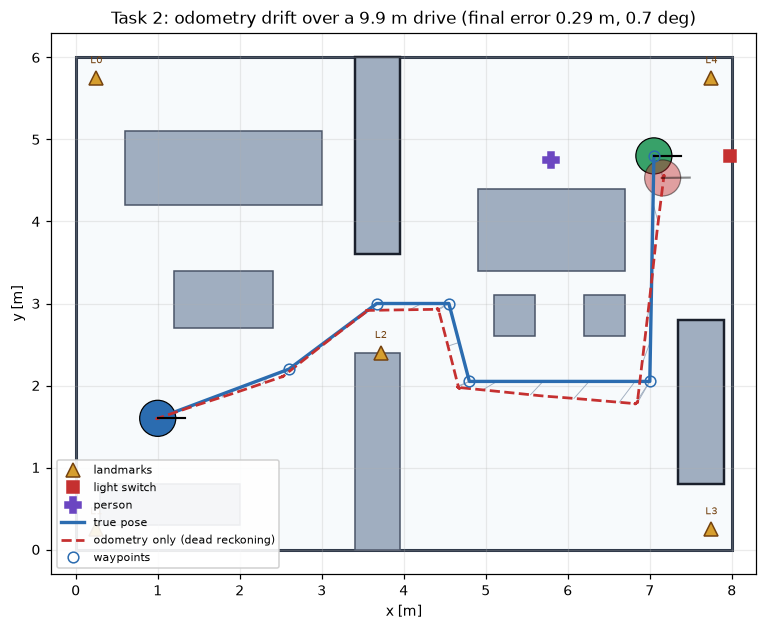

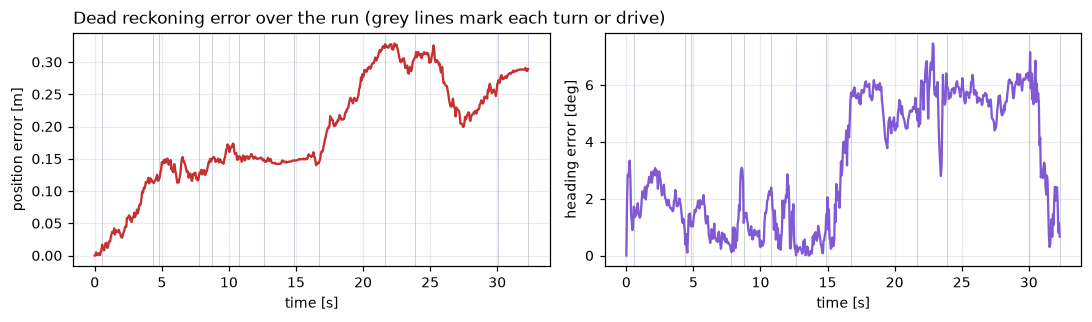

In [141]:
fig, ax = plt.subplots(figsize=(7.6, 5.8))
draw_room(ax)
ax.plot(LOG["true"][:, 0], LOG["true"][:, 1], color="#2b6cb0", lw=2.2,
        label="true pose", zorder=6)
ax.plot(LOG["odom"][:, 0], LOG["odom"][:, 1], color="#c53030", lw=1.8, ls="--",
        label="odometry only (dead reckoning)", zorder=6)
ax.plot(WAYPOINTS[:, 0], WAYPOINTS[:, 1], "o", mfc="none", mec="#2b6cb0", ms=7,
        label="waypoints", zorder=7)

# Thin lines joining the two paths at the same instant, so the growing gap is easy to see.
for k in range(0, len(LOG["true"]), 25):
    ax.plot([LOG["true"][k, 0], LOG["odom"][k, 0]],
            [LOG["true"][k, 1], LOG["odom"][k, 1]], color="#a0aec0", lw=0.6, zorder=5)

draw_robot(ax, LOG["true"][0])
draw_robot(ax, LOG["true"][-1], color="#38a169")
draw_robot(ax, LOG["odom"][-1], color="#c53030", alpha=0.45)
ax.set_title(f"Task 2: odometry drift over a {path_len:.1f} m drive "
             f"(final error {final_err:.2f} m, {head_err:.1f} deg)")
ax.legend(fontsize=7.5, loc="lower left", framealpha=0.9)
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(1, 2, figsize=(10, 3.0))
err_xy = np.linalg.norm(LOG["true"][:, :2] - LOG["odom"][:, :2], axis=1)
err_th = np.rad2deg(np.abs(wrap_to_pi(LOG["true"][:, 2] - LOG["odom"][:, 2])))
axes[0].plot(LOG["t"], err_xy, color="#c53030"); axes[0].set_ylabel("position error [m]")
axes[1].plot(LOG["t"], err_th, color="#805ad5"); axes[1].set_ylabel("heading error [deg]")
for a in axes:
    a.set_xlabel("time [s]")
    for ts in SEG_BOUNDS:
        a.axvline(ts, color="#cbd5e0", lw=0.7, zorder=0)    # turn / drive boundaries
axes[0].set_title("Dead reckoning error over the run (grey lines mark each turn or drive)",
                  loc="left")
plt.tight_layout(); plt.show()

### What the sensors actually see

On the left, one full lidar sweep from the goal pose drawn as rays in the room. The beams stop
on the real furniture and wall surfaces, and those endpoints are what Task 5 will turn into
occupied cells. The gold lines are the landmarks the robot can see from there.

On the right, the same sweep in the robot's own frame. The beams that returned nothing are
drawn in grey out at the maximum range, as a reminder that they are not obstacles.

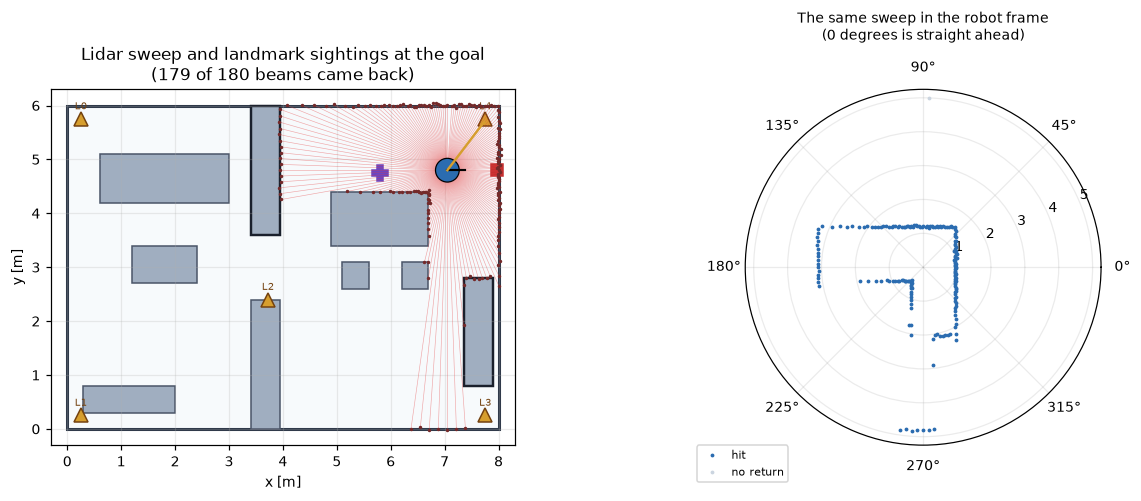

In [142]:
scan_pose = LOG["true"][-1]
angles, ranges = lidar_scan(scan_pose, ROOM, NOISE, make_rng(21))
hit = np.isfinite(ranges)

fig = plt.figure(figsize=(12, 4.6))
ax1 = fig.add_subplot(1, 2, 1)
ax2 = fig.add_subplot(1, 2, 2, projection="polar")

draw_room(ax1)
px, py, pth = scan_pose
for a, r in zip(angles[hit], ranges[hit]):
    ax1.plot([px, px + r * np.cos(pth + a)], [py, py + r * np.sin(pth + a)],
             color="#e53e3e", lw=0.4, alpha=0.45, zorder=5)
ax1.plot(px + ranges[hit] * np.cos(pth + angles[hit]),
         py + ranges[hit] * np.sin(pth + angles[hit]),
         ".", color="#742a2a", ms=2.5, zorder=6, label="beam endpoints")
for i, r, b in LOG["obs"][-1]:
    ax1.plot([px, px + r * np.cos(pth + b)], [py, py + r * np.sin(pth + b)],
             color="#d69e2e", lw=1.6, zorder=7)
draw_robot(ax1, scan_pose)
ax1.set_title(f"Lidar sweep and landmark sightings at the goal\n"
              f"({hit.sum()} of {len(ranges)} beams came back)")

ax2.plot(angles[hit], ranges[hit], ".", ms=3, color="#2b6cb0", label="hit")
ax2.plot(angles[~hit], np.full((~hit).sum(), NOISE.lidar_max_range), ".", ms=3,
         color="#cbd5e0", label="no return")
ax2.set_rmax(NOISE.lidar_max_range * 1.05)
ax2.set_title("The same sweep in the robot frame\n(0 degrees is straight ahead)",
              pad=14, fontsize=9)
ax2.legend(fontsize=7, loc="lower left", bbox_to_anchor=(-0.15, -0.12))
plt.tight_layout(); plt.show()

## 2.6 Measuring the noise we claim to have added

Each sensor is sampled a few thousand times from a fixed pose and the spread of the errors is
compared against the standard deviations in `NoiseParams`. This is how we checked the noise is
actually going in, and going in at the size we say it does. It would be easy to write a noise
model that quietly does nothing, so we measured it.

quantity                                specified     measured
--------------------------------------------------------------
landmark L1 range [m]                      0.1188       0.1184
landmark bearing [deg]                     1.6000       1.6248
lidar range [m]                            0.0200       0.0200
odometry v at v=0.45 w=0.3 [m/s]           0.1181       0.1141
odometry w at v=0.45 w=0.3 [rad/s]         0.1142       0.1146

landmark L1 was detected on 0.925 of trials (specified 0.92)


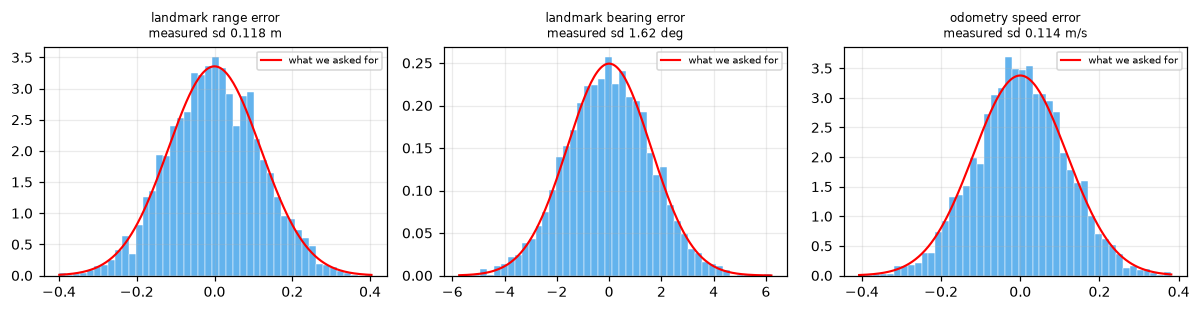

In [143]:
rng = make_rng(33)
probe = np.array([7.00, 2.05, 0.35])   # a pose on the reference path, well clear of furniture
N_TRIALS = 4000

# Take the noise free reading first, so we have something to measure the errors against.
truth = {i: (r, b) for i, r, b in observe_landmarks(probe, ROOM, NOISE.scaled(0.0), rng)}
assert truth, "the probe pose cannot see any landmarks, pick another one"
lm_id = min(truth)
r_true, b_true = truth[lm_id]

r_err = np.array([o[1] - r_true for _ in range(N_TRIALS)
                  for o in observe_landmarks(probe, ROOM, NOISE, rng) if o[0] == lm_id])
b_err = np.array([wrap_to_pi(o[2] - b_true) for _ in range(N_TRIALS)
                  for o in observe_landmarks(probe, ROOM, NOISE, rng) if o[0] == lm_id])

# For the lidar, use a cut down 8 beam sensor so we can take a lot of samples quickly.
fast_lidar = replace(NOISE, n_beams=8)
lr_true = lidar_scan(probe, ROOM, replace(fast_lidar, sigma_lidar=0.0),
                     rng, add_noise=False)[1][0]
lr_samples = np.array([lidar_scan(probe, ROOM, fast_lidar, rng)[1][0] for _ in range(1500)])
lr_err = lr_samples[np.isfinite(lr_samples)] - lr_true

v_cmd, w_cmd = 0.45, 0.30
odom_samples = np.array([sample_odometry(v_cmd, w_cmd, NOISE, rng) for _ in range(N_TRIALS)])

# What NoiseParams says these spreads should be.
exp_r = NOISE.sigma_r0 + NOISE.sigma_r1 * r_true
exp_v = np.sqrt(NOISE.a1 * v_cmd**2 + NOISE.a2 * w_cmd**2)
exp_w = np.sqrt(NOISE.a3 * v_cmd**2 + NOISE.a4 * w_cmd**2)

print(f"{'quantity':<36}{'specified':>13}{'measured':>13}")
print("-" * 62)
for label, expected, measured in [
        (f"landmark L{lm_id} range [m]", exp_r, r_err.std()),
        ("landmark bearing [deg]", np.rad2deg(NOISE.sigma_b), np.rad2deg(b_err.std())),
        ("lidar range [m]", NOISE.sigma_lidar, lr_err.std()),
        (f"odometry v at v={v_cmd} w={w_cmd} [m/s]", exp_v, odom_samples[:, 0].std()),
        (f"odometry w at v={v_cmd} w={w_cmd} [rad/s]", exp_w, odom_samples[:, 1].std())]:
    print(f"{label:<36}{expected:>13.4f}{measured:>13.4f}")

print(f"\nlandmark L{lm_id} was detected on {len(r_err) / N_TRIALS:.3f} of trials "
      f"(specified {NOISE.lm_p_detect})")

fig, axes = plt.subplots(1, 3, figsize=(11, 2.9))
for ax, data, sigma, title in [
        (axes[0], r_err, exp_r, f"landmark range error\nmeasured sd {r_err.std():.3f} m"),
        (axes[1], np.rad2deg(b_err), np.rad2deg(NOISE.sigma_b),
         f"landmark bearing error\nmeasured sd {np.rad2deg(b_err.std()):.2f} deg"),
        (axes[2], odom_samples[:, 0] - v_cmd, exp_v,
         f"odometry speed error\nmeasured sd {odom_samples[:, 0].std():.3f} m/s")]:
    ax.hist(data, bins=45, density=True, color="#63b3ed", ec="white", lw=0.3)
    xs = np.linspace(data.min(), data.max(), 200)
    ax.plot(xs, np.exp(-0.5 * (xs / sigma)**2) / (sigma * np.sqrt(2 * np.pi)),
            "r-", lw=1.4, label="what we asked for")
    ax.set_title(title, fontsize=8)
    ax.legend(fontsize=6.5)
plt.tight_layout(); plt.show()

## 2.7 Turning the noise up and down

The same drive and the same seeds, with every noise magnitude multiplied by one number. At a
scale of 0 the odometry is exact and the two paths sit on top of each other. Raising the scale
makes dead reckoning worse in a smooth, predictable way. Twelve seeds per setting, so what is
shown is the spread rather than one lucky run.

This is the knob we use on Task 4: the filter has to stay accurate as the scale goes up, and the
gap between the bands here and the filtered estimate is the localization result.

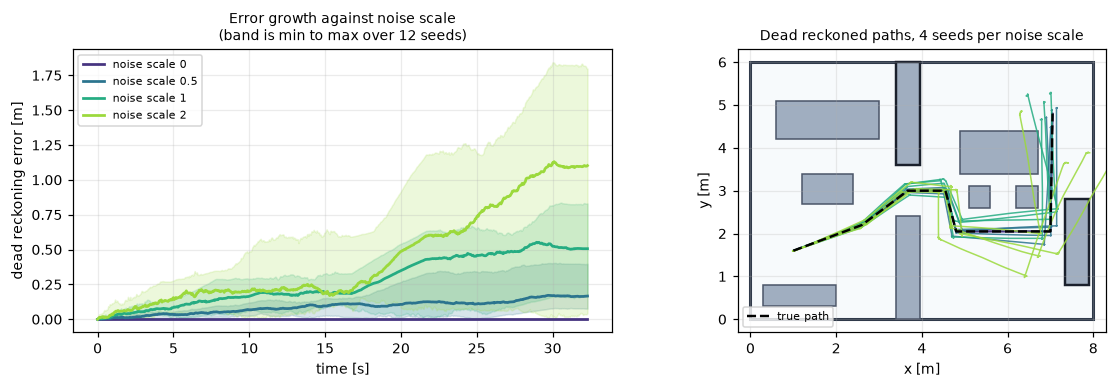

  scale    median final error [m]   worst of 12 [m]
---------------------------------------------------
      0                     0.000             0.000
    0.5                     0.167             0.398
      1                     0.506             0.830
      2                     1.102             1.798


In [144]:
SCALES = [0.0, 0.5, 1.0, 2.0]
N_SEEDS = 12

sweep = {}
for s in SCALES:
    params = NOISE.scaled(s)
    errs = []
    for seed in range(N_SEEDS):
        # scan_every is huge here so no lidar sweeps are taken. We only need the poses, and
        # sweeping would make this cell a lot slower for no benefit.
        lg = run_drive(CMDS, params, seed_stream=200 + seed, scan_every=10**6)
        errs.append(np.linalg.norm(lg["true"][:, :2] - lg["odom"][:, :2], axis=1))
    sweep[s] = np.array(errs)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.6))
colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(SCALES)))

for (s, errs), c in zip(sweep.items(), colors):
    ax1.fill_between(LOG["t"], errs.min(axis=0), errs.max(axis=0), color=c, alpha=0.18)
    ax1.plot(LOG["t"], np.median(errs, axis=0), color=c, lw=1.8, label=f"noise scale {s:g}")
ax1.set_xlabel("time [s]")
ax1.set_ylabel("dead reckoning error [m]")
ax1.set_title("Error growth against noise scale\n(band is min to max over 12 seeds)", fontsize=9)
ax1.legend(fontsize=7)

draw_room(ax2, landmarks=False, targets=False)
for (s, _), c in zip(sweep.items(), colors):
    for seed in range(4):
        lg = run_drive(CMDS, NOISE.scaled(s), seed_stream=200 + seed, scan_every=10**6)
        ax2.plot(lg["odom"][:, 0], lg["odom"][:, 1], color=c, lw=1.0, alpha=0.85)
ax2.plot(LOG["true"][:, 0], LOG["true"][:, 1], "k--", lw=1.6, label="true path")
ax2.set_title("Dead reckoned paths, 4 seeds per noise scale", fontsize=9)
ax2.legend(fontsize=7, loc="lower left")
plt.tight_layout(); plt.show()

print(f"{'scale':>7}{'median final error [m]':>26}{'worst of 12 [m]':>18}")
print("-" * 51)
for s, errs in sweep.items():
    print(f"{s:>7g}{np.median(errs[:, -1]):>26.3f}{errs[:, -1].max():>18.3f}")

## 2.8 Task 2 tests

These cover the room geometry, the ray caster, both sensors, the odometry noise and the
reference drive. Two are worth pointing out.

The occlusion tests check the height rule both ways round: a landmark behind the partition must
not be reported, and a landmark behind the coffee table must be, even though a lidar beam in the
same direction stops at the table. It would be easy to get that backwards, and it would change
how much Task 4 has to work with without anything looking broken.

The statistical tests use fixed seeds and loose tolerances. They are meant to catch noise that
is missing, doubled or attached to the wrong variable, not to test numpy's sampler.

In [145]:
# ------------------------------------------------------------ room geometry
@test("Task 2")
def test_start_and_goal_are_clear_of_the_furniture():
    assert ROOM.is_free(START_POSE[:2], margin=ROBOT_RADIUS)
    assert ROOM.is_free(GOAL_POSE[:2], margin=ROBOT_RADIUS)


@test("Task 2")
def test_points_inside_furniture_are_not_free():
    for f in ROOM.furniture:
        centre = (f.x + f.w / 2, f.y + f.h / 2)
        assert not ROOM.is_free(centre), f.name
        assert close(f.distance_to(centre), 0.0)


@test("Task 2")
def test_points_outside_the_room_are_not_free():
    for pt in [(-0.1, 3.0), (8.1, 3.0), (4.0, -0.1), (4.0, 6.1)]:
        assert not ROOM.is_free(pt, margin=0.0), pt


@test("Task 2")
def test_a_bigger_margin_never_makes_a_point_more_free():
    rng = make_rng(2001)
    pts = np.column_stack([rng.uniform(0, ROOM.width, 300), rng.uniform(0, ROOM.height, 300)])
    for pt in pts:
        if ROOM.is_free(pt, margin=0.4):
            assert ROOM.is_free(pt, margin=0.1)     # clear at 0.4 implies clear at 0.1


@test("Task 2")
def test_distance_to_a_rectangle_matches_hand_values():
    r = Rect(1.0, 1.0, 2.0, 1.0)                    # spans x 1 to 3, y 1 to 2
    assert close(r.distance_to((2.0, 1.5)), 0.0)    # inside
    assert close(r.distance_to((4.0, 1.5)), 1.0)    # straight out to the right
    assert close(r.distance_to((2.0, 3.0)), 1.0)    # straight up
    assert close(r.distance_to((4.0, 3.0)), np.hypot(1.0, 1.0))   # diagonally off a corner


@test("Task 2")
def test_the_grid_has_the_expected_shape_and_occupied_fraction():
    assert GT_GRID.shape == (NY, NX) == (120, 160)
    # The furniture does not overlap, so the occupied area is just the sum of the rectangles.
    expected = sum(f.w * f.h for f in ROOM.furniture) / (ROOM.width * ROOM.height)
    assert abs(GT_GRID.mean() - expected) < 0.02, (GT_GRID.mean(), expected)


@test("Task 2")
def test_the_furniture_does_not_overlap():
    # The occupied fraction test above relies on this, so check it rather than assume it.
    for i, a in enumerate(ROOM.furniture):
        for b in ROOM.furniture[i + 1:]:
            ax0, ay0, ax1, ay1 = a.bounds
            bx0, by0, bx1, by1 = b.bounds
            overlaps = (ax0 < bx1 and bx0 < ax1) and (ay0 < by1 and by0 < ay1)
            assert not overlaps, f"{a.name} overlaps {b.name}"


@test("Task 2")
def test_the_doorway_is_wide_enough_for_the_robot():
    # The counter ends at y = 2.40 and the partition starts at y = 3.60.
    gap = 3.60 - 2.40
    assert gap > 2 * ROBOT_RADIUS, gap
    assert ROOM.is_free((3.67, 3.00), margin=ROBOT_RADIUS)


# --------------------------------------------------------------- ray casting
@test("Task 2")
def test_ray_ranges_match_the_hand_computed_values():
    for p, a, expected, what in CAST_CHECKS:
        got = cast_ray(np.array(p), a, ROOM)
        assert abs(got - expected) < 1e-9, f"{what}: got {got}, expected {expected}"


@test("Task 2")
def test_a_ray_never_reaches_further_than_the_room_diagonal():
    diagonal = np.hypot(ROOM.width, ROOM.height)
    rng = make_rng(2002)
    for _ in range(300):
        p = np.array([rng.uniform(0.3, ROOM.width - 0.3), rng.uniform(0.3, ROOM.height - 0.3)])
        if not ROOM.is_free(p):
            continue
        r = cast_ray(p, rng.uniform(-np.pi, np.pi), ROOM)
        assert 0 < r <= diagonal + 1e-9, r


@test("Task 2")
def test_a_box_behind_the_ray_is_not_hit():
    # Box sits to the right, ray points left, so it must miss.
    assert ray_box_hit(np.array([0.0, 0.0]), np.array([-1.0, 0.0]), (1.0, -1.0, 2.0, 1.0)) == np.inf


@test("Task 2")
def test_a_ray_parallel_to_a_box_misses_it():
    # Travelling along +x at y = 5, while the box only spans y from -1 to 1.
    assert ray_box_hit(np.array([0.0, 5.0]), np.array([1.0, 0.0]), (1.0, -1.0, 2.0, 1.0)) == np.inf


@test("Task 2")
def test_casting_towards_a_wall_gives_the_distance_to_it():
    # From the middle of the room, straight up, with nothing in the way at x = 4.3.
    assert close(cast_ray(np.array([4.3, 0.6]), np.pi / 2, ROOM), ROOM.height - 0.6, 1e-9)


# --------------------------------------------------------------------- lidar
@test("Task 2")
def test_the_lidar_returns_the_number_of_beams_asked_for():
    for n in (8, 45, 180):
        angles, ranges = lidar_scan(GOAL_POSE, ROOM, replace(NOISE, n_beams=n), make_rng(2003))
        assert len(angles) == len(ranges) == n


@test("Task 2")
def test_a_noise_free_lidar_agrees_with_direct_ray_casts():
    params = replace(NOISE, n_beams=36)
    angles, ranges = lidar_scan(GOAL_POSE, ROOM, params, make_rng(2004), add_noise=False)
    for a, r in zip(angles, ranges):
        direct = cast_ray(GOAL_POSE[:2], GOAL_POSE[2] + a, ROOM)
        if np.isinf(r):
            assert direct >= params.lidar_max_range      # inf only where nothing is in range
        else:
            assert close(r, direct, 1e-9)


@test("Task 2")
def test_lidar_ranges_stay_inside_their_limits():
    _, ranges = lidar_scan(START_POSE, ROOM, NOISE, make_rng(2005))
    finite = ranges[np.isfinite(ranges)]
    assert np.all(finite >= 0) and np.all(finite <= NOISE.lidar_max_range + 1e-12)


@test("Task 2")
def test_lidar_range_noise_matches_the_setting():
    params = replace(NOISE, n_beams=8, lidar_p_dropout=0.0)
    rng = make_rng(2006)
    clean = lidar_scan(GOAL_POSE, ROOM, params, rng, add_noise=False)[1][0]
    samples = np.array([lidar_scan(GOAL_POSE, ROOM, params, rng)[1][0] for _ in range(1200)])
    assert abs(samples.std() - params.sigma_lidar) < 0.2 * params.sigma_lidar, samples.std()
    assert abs(samples.mean() - clean) < 0.01                # noise is zero mean


@test("Task 2")
def test_lidar_dropout_happens_at_about_the_stated_rate():
    # A high dropout rate makes the count easy to measure without needing huge samples.
    params = replace(NOISE, lidar_p_dropout=0.25, lidar_max_range=20.0)
    _, ranges = lidar_scan(np.array([4.3, 0.6, 0.0]), ROOM, params, make_rng(2007))
    # With a 20 m range nothing is out of reach, so every inf must be a dropout.
    dropped = np.mean(~np.isfinite(ranges))
    assert abs(dropped - 0.25) < 0.1, dropped


# ----------------------------------------------------------------- landmarks
@test("Task 2")
def test_a_noise_free_landmark_reading_is_exact():
    pose = np.array([4.3, 0.6, 0.4])
    for i, r, b in observe_landmarks(pose, ROOM, NOISE.scaled(0.0), make_rng(2008)):
        dx, dy = ROOM.landmarks[i] - pose[:2]
        assert close(r, np.hypot(dx, dy), 1e-12)
        assert close(b, wrap_to_pi(np.arctan2(dy, dx) - pose[2]), 1e-12)


@test("Task 2")
def test_landmark_readings_are_well_formed():
    rng = make_rng(2009)
    for pose in (START_POSE, GOAL_POSE, np.array([4.3, 0.6, 1.2])):
        for i, r, b in observe_landmarks(pose, ROOM, NOISE, rng):
            assert 0 <= i < len(ROOM.landmarks)              # a real landmark id
            assert r > 0
            assert -np.pi - 1e-9 < b <= np.pi + 1e-9         # bearing is wrapped


@test("Task 2")
def test_landmarks_beyond_the_range_limit_are_dropped():
    # Derive the limit from the geometry rather than hard coding one. L2 sits 0.66 m from this
    # pose, so a hand picked limit of 1 m would not actually be beyond anything.
    pose = np.array([4.0, 3.0, 0.0])
    nearest = float(np.min(np.linalg.norm(ROOM.landmarks - pose[:2], axis=1)))
    perfect = replace(NOISE, lm_p_detect=1.0, lm_occlusion=False)
    just_short = replace(perfect, lm_max_range=nearest - 0.05)
    just_long = replace(perfect, lm_max_range=nearest + 0.05)
    assert observe_landmarks(pose, ROOM, just_short, make_rng(2010), add_noise=False) == []
    # And just past it, exactly the one nearest landmark comes back.
    assert len(observe_landmarks(pose, ROOM, just_long, make_rng(2010), add_noise=False)) == 1


@test("Task 2")
def test_the_detection_rate_matches_the_setting():
    pose = np.array([4.3, 0.6, 0.0])
    params = replace(NOISE, lm_p_detect=0.6, sigma_r0=0.0, sigma_r1=0.0, sigma_b=0.0)
    rng = make_rng(2011)
    visible = len(observe_landmarks(pose, ROOM, replace(params, lm_p_detect=1.0), rng))
    assert visible > 0
    trials = 800
    seen = sum(len(observe_landmarks(pose, ROOM, params, rng)) for _ in range(trials))
    rate = seen / (trials * visible)
    assert abs(rate - 0.6) < 0.05, rate


@test("Task 2")
def test_landmark_range_noise_grows_with_distance():
    # sigma = sigma_r0 + sigma_r1 * r, so a landmark twice as far away is noisier.
    rng = make_rng(2012)
    pose = np.array([4.3, 0.6, 0.0])
    params = replace(NOISE, lm_p_detect=1.0, lm_occlusion=False)
    truth = {i: r for i, r, _ in observe_landmarks(pose, ROOM, params.scaled(0.0), rng)}
    near_id = min(truth, key=truth.get)
    far_id = max(truth, key=truth.get)
    assert truth[far_id] > truth[near_id] * 1.5, "need two landmarks at clearly different ranges"

    spread = {}
    for target in (near_id, far_id):
        errs = [o[1] - truth[target] for _ in range(1500)
                for o in observe_landmarks(pose, ROOM, params, rng) if o[0] == target]
        spread[target] = np.std(errs)
        expected = params.sigma_r0 + params.sigma_r1 * truth[target]
        assert abs(spread[target] - expected) < 0.25 * expected, (target, spread[target], expected)
    assert spread[far_id] > spread[near_id]


@test("Task 2")
def test_landmark_bearing_noise_matches_the_setting():
    rng = make_rng(2013)
    pose = np.array([4.3, 0.6, 0.0])
    params = replace(NOISE, lm_p_detect=1.0, lm_occlusion=False)
    truth = {i: b for i, _, b in observe_landmarks(pose, ROOM, params.scaled(0.0), rng)}
    target = min(truth)
    errs = [wrap_to_pi(o[2] - truth[target]) for _ in range(2000)
            for o in observe_landmarks(pose, ROOM, params, rng) if o[0] == target]
    assert abs(np.std(errs) - params.sigma_b) < 0.2 * params.sigma_b, np.std(errs)


# ---------------------------------------------------------------- occlusion
@test("Task 2")
def test_the_partition_hides_landmarks_behind_it():
    # From the goal, L0 in the far corner of the living room is behind the partition wall.
    pose = GOAL_POSE
    perfect = replace(NOISE, lm_p_detect=1.0)
    seen = {i for i, _, _ in observe_landmarks(pose, ROOM, perfect, make_rng(2014),
                                               add_noise=False)}
    assert 0 not in seen, "L0 should be hidden by the partition wall"

    # With occlusion switched off it comes back, which shows the range limit is not the reason.
    no_occlusion = replace(perfect, lm_occlusion=False)
    seen_open = {i for i, _, _ in observe_landmarks(pose, ROOM, no_occlusion, make_rng(2014),
                                                    add_noise=False)}
    assert 0 in seen_open


@test("Task 2")
def test_low_furniture_blocks_the_lidar_but_not_the_landmark_camera():
    # From the start pose, the tv stand sits between the robot and L1 in the near corner.
    pose = START_POSE
    lm = ROOM.landmarks[1]
    dx, dy = lm - pose[:2]
    bearing = np.arctan2(dy, dx)
    distance = np.hypot(dx, dy)

    # The lidar, which sees everything, stops short at the tv stand.
    assert cast_ray(pose[:2], bearing, ROOM) < distance - 0.05
    # The camera, which only cares about tall obstacles, has a clear line.
    assert cast_ray(pose[:2], bearing, ROOM, full_height_only=True) > distance

    seen = {i for i, _, _ in observe_landmarks(pose, ROOM, replace(NOISE, lm_p_detect=1.0),
                                               make_rng(2015), add_noise=False)}
    assert 1 in seen, "L1 should be visible over the top of the tv stand"


@test("Task 2")
def test_turning_occlusion_off_can_only_reveal_more_landmarks():
    rng_a, rng_b = make_rng(2016), make_rng(2016)
    on = replace(NOISE, lm_p_detect=1.0, lm_occlusion=True)
    off = replace(on, lm_occlusion=False)
    for pose in (START_POSE, GOAL_POSE, np.array([4.3, 0.6, 0.9])):
        seen_on = {i for i, _, _ in observe_landmarks(pose, ROOM, on, rng_a, add_noise=False)}
        seen_off = {i for i, _, _ in observe_landmarks(pose, ROOM, off, rng_b, add_noise=False)}
        assert seen_on <= seen_off, pose


# ----------------------------------------------------------------- odometry
@test("Task 2")
def test_noise_free_odometry_matches_the_clean_model():
    rng = make_rng(2017)
    pose = np.array([1.0, 2.0, 0.3])
    for v, w in [(0.4, 0.3), (0.0, 0.8), (-0.2, 0.0)]:
        assert poses_close(odom_step(pose, v, w, DT, NOISE.scaled(0.0), rng),
                           unicycle_step(pose, v, w, DT))


@test("Task 2")
def test_odometry_noise_matches_the_alpha_formula():
    rng = make_rng(2018)
    for v, w in [(0.45, 0.30), (0.0, 0.70), (0.50, 0.0)]:
        samples = np.array([sample_odometry(v, w, NOISE, rng) for _ in range(6000)])
        for column, expected in [
                (0, np.sqrt(NOISE.a1 * v**2 + NOISE.a2 * w**2)),
                (1, np.sqrt(NOISE.a3 * v**2 + NOISE.a4 * w**2)),
                (2, np.sqrt(NOISE.a5 * v**2 + NOISE.a6 * w**2))]:
            measured = samples[:, column].std()
            assert abs(measured - expected) < 0.2 * expected + 1e-9, (v, w, column, measured, expected)


@test("Task 2")
def test_a_stationary_robot_picks_up_no_odometry_noise():
    # The noise scales with the commanded speeds, so standing still must add nothing at all.
    rng = make_rng(2019)
    for _ in range(50):
        assert close(sample_odometry(0.0, 0.0, NOISE, rng), (0.0, 0.0, 0.0))


@test("Task 2")
def test_doubling_the_noise_scale_doubles_the_spread():
    rng = make_rng(2020)
    v, w = 0.45, 0.30
    single = np.array([sample_odometry(v, w, NOISE.scaled(1.0), rng) for _ in range(6000)])
    double = np.array([sample_odometry(v, w, NOISE.scaled(2.0), rng) for _ in range(6000)])
    ratio = double[:, 0].std() / single[:, 0].std()
    assert abs(ratio - 2.0) < 0.2, ratio


@test("Task 2")
def test_a_noise_scale_of_zero_is_completely_deterministic():
    a = run_drive(CMDS, NOISE.scaled(0.0), seed_stream=1, scan_every=10**6)
    b = run_drive(CMDS, NOISE.scaled(0.0), seed_stream=999, scan_every=10**6)
    # Different seeds, but with no noise the odometry must land on the true pose either way.
    assert close(a["odom"], a["true"], 1e-9)
    assert close(a["odom"], b["odom"], 1e-9)


# ------------------------------------------------------------ reference drive
@test("Task 2")
def test_the_reference_drive_reaches_the_goal():
    assert poses_close(LOG["true"][-1], GOAL_POSE, 1e-9), LOG["true"][-1]


@test("Task 2")
def test_the_reference_path_clears_the_furniture():
    worst = min(ROOM.clearance(p[:2]) for p in LOG["true"])
    assert worst >= ROBOT_RADIUS, f"closest approach was {worst:.3f} m"


@test("Task 2")
def test_the_drive_actually_sees_landmarks_along_the_way():
    # Task 4 has nothing to work with if the robot is blind for most of the run.
    seen = np.array([len(o) for o in LOG["obs"]])
    assert seen.mean() > 1.0, seen.mean()
    assert np.mean(seen == 0) < 0.35, np.mean(seen == 0)


@test("Task 2")
def test_the_same_seed_gives_an_identical_run():
    a = run_drive(CMDS, NOISE, seed_stream=42, scan_every=10**6)
    b = run_drive(CMDS, NOISE, seed_stream=42, scan_every=10**6)
    assert close(a["odom"], b["odom"], 0.0)


@test("Task 2")
def test_different_seeds_give_different_runs():
    a = run_drive(CMDS, NOISE, seed_stream=42, scan_every=10**6)
    b = run_drive(CMDS, NOISE, seed_stream=43, scan_every=10**6)
    assert not close(a["odom"], b["odom"], 1e-6)


@test("Task 2")
def test_dead_reckoning_drifts_away_from_the_truth():
    # The whole point of Task 4 is that this error exists and is worth removing.
    assert final_err > 0.05, final_err


@test("Task 2")
def test_more_noise_means_more_drift():
    medians = [np.median(sweep[s][:, -1]) for s in SCALES]
    assert medians[0] == 0.0                       # scale 0 is exact
    assert medians[-1] > medians[1], medians       # scale 2 is clearly worse than scale 0.5


run_tests("Task 2")

  pass    start and goal are clear of the furniture
  pass    points inside furniture are not free
  pass    points outside the room are not free
  pass    a bigger margin never makes a point more free
  pass    distance to a rectangle matches hand values
  pass    the grid has the expected shape and occupied fraction
  pass    the furniture does not overlap
  pass    the doorway is wide enough for the robot
  pass    ray ranges match the hand computed values
  pass    a ray never reaches further than the room diagonal
  pass    a box behind the ray is not hit
  pass    a ray parallel to a box misses it
  pass    casting towards a wall gives the distance to it
  pass    the lidar returns the number of beams asked for
  pass    a noise free lidar agrees with direct ray casts
  pass    lidar ranges stay inside their limits
  pass    lidar range noise matches the setting
  pass    lidar dropout happens at about the stated rate
  pass    a noise free landmark reading is exact
  pass    lan

39

---
# Task 3: Motion Planning

We wrote both a potential field and a PRM so we could compare them rather than just claim one is
better.

## 3.1 Collision checking

Both planners sit on top of this, so it comes first. The base is a disc, so we plan in $(x, y)$
and use Task 2's `Room.clearance(pt)`: the robot fits wherever the clearance is more than its
radius. We plan at 0.27 m rather than the real 0.22 m, since the base has to follow the path with
noisy odometry underneath it.

`edge_clear` samples the segment every 5 cm and asks for `pad + spacing/2` of clearance at each
sample. The extra half spacing is what makes the sampled check say something about the whole
segment: clearance is a distance, so it cannot change by more than half the spacing between one
sample and the next. Without it, a checker with a fixed number of samples can step straight over
the 0.55 m partition wall, and there is a test that tries exactly that.

In [146]:
SAFE_RADIUS = ROBOT_RADIUS + 0.05     # plan for a slightly fatter robot than we have

def in_collision(p, room=ROOM, pad=SAFE_RADIUS):
    """True if the robot, padded by `pad`, overlaps a wall or any furniture."""
    return room.clearance(np.asarray(p, dtype=float)[:2]) <= pad


def edge_clear(p, q, room=ROOM, pad=SAFE_RADIUS, spacing=0.05):
    """True if the straight segment from `p` to `q` is drivable.

    Samples every `spacing` metres and asks for `pad + spacing/2` at each one. Clearance is a
    distance, so it cannot change by more than half the spacing between neighbouring samples,
    which is what makes the sampled check cover the gaps as well.
    """
    p, q = np.asarray(p, dtype=float)[:2], np.asarray(q, dtype=float)[:2]
    steps = max(2, int(np.linalg.norm(q - p) / spacing) + 1)
    need = pad + spacing / 2
    return all(room.clearance(p + (q - p) * t) > need for t in np.linspace(0, 1, steps))


def path_length(path):
    """Total length of an (N, 2) polyline [m]."""
    path = np.asarray(path, dtype=float)
    return float(np.sum(np.linalg.norm(np.diff(path, axis=0), axis=1)))

## 3.2 The potential field

The robot takes fixed size steps downhill on an attractive pull towards the goal plus a repulsive
push off the obstacles:

$$F_{\text{rep}} = k_{\text{rep}} \left(\frac{1}{d} - \frac{1}{\rho_0}\right) \frac{1}{d^2}$$

zero once the gap $d$ is bigger than the influence radius $\rho_0$, and blowing up as $d \to 0$.
$d$ is measured from the robot's surface, so it is the gap the robot actually has. We take the
direction as uphill on the clearance field by finite differences, because our obstacles are
rectangles and there is no obvious centre to push away from.

In [147]:
def att_force(q, goal, k_att=1.0):
    """Attractive force pulling towards the goal. Returns a (2,) vector."""
    return k_att * (np.array(goal) - np.array(q))


def rep_force(q, room=ROOM, rho0=0.5, k_rep=0.02, pad=SAFE_RADIUS, eps=0.01):
    """Repulsive force pushing away from the nearest obstacle. Returns a (2,) vector.

    Magnitude k (1/d - 1/rho0) / d^2, zero once the gap d exceeds rho0. The direction is uphill
    on the clearance field, taken by finite differences.
    """
    q = np.asarray(q, dtype=float)[:2]
    d = room.clearance(q) - pad
    if d <= 0 or d >= rho0:
        return np.zeros(2)

    grad = np.array([room.clearance(q + [eps, 0]) - room.clearance(q - [eps, 0]),
                     room.clearance(q + [0, eps]) - room.clearance(q - [0, eps])]) / (2 * eps)
    n = np.linalg.norm(grad)
    if n < 1e-12:
        return np.zeros(2)
    return k_rep * (1 / d - 1 / rho0) * (1 / d**2) * (grad / n)


def plan_path(start, goal, room=ROOM, k_att=1.0, k_rep=0.02, rho0=0.5,
              step=0.04, max_iters=3000, tol=0.15):
    """Gradient descent on the attractive plus repulsive field. Returns an (N, 2) path."""
    q = np.array(start, dtype=float)[:2]
    path = [q.copy()]
    for _ in range(max_iters):
        F = att_force(q, np.asarray(goal)[:2], k_att) + rep_force(q, room, rho0, k_rep)
        n = np.linalg.norm(F)
        if n > 1e-9:
            q = q + step * F / n * min(1.0, n)
        path.append(q.copy())
        if np.linalg.norm(q - np.asarray(goal)[:2]) < tol:
            break
    return np.array(path)

## 3.3 The PRM

Scatter 100 collision free samples, join every pair closer than 1.8 m whose edge is clear, then run
Dijkstra from start to goal.

Two things follow from it being a graph search rather than a walk. The path is the best one in the
roadmap, so we did not add a smoothing step. And the roadmap can be reused, so another start to
goal query in the same room costs nothing extra.

`prm_shortest_path` returns `None` when the roadmap does not connect the two points, instead of
crashing while walking back through the parent pointers. There is a test for that, with a goal
inside the bookshelf.

In [148]:
import heapq

def build_prm(room=ROOM, n_samples=100, r_conn=1.8, seed=301, pad=SAFE_RADIUS):
    """Build a roadmap of collision free samples. Returns (samples (N, 2), edges [(i, j)])."""
    rng = make_rng(seed)
    samples = []
    while len(samples) < n_samples:
        p = np.array([rng.uniform(0, room.width), rng.uniform(0, room.height)])
        if not in_collision(p, room, pad):
            samples.append(p)
    samples = np.array(samples)

    edges = [(i, j) for i in range(len(samples)) for j in range(i + 1, len(samples))
             if np.linalg.norm(samples[i] - samples[j]) < r_conn
             and edge_clear(samples[i], samples[j], room, pad)]
    return samples, edges


def prm_shortest_path(samples, edges, start, goal, r_conn=1.8, room=ROOM, pad=SAFE_RADIUS):
    """Shortest path from start to goal over the roadmap, by Dijkstra.

    Returns an (N, 2) polyline, or None if the roadmap does not connect the two.
    """
    nodes = list(samples) + [np.array(start, dtype=float)[:2], np.array(goal, dtype=float)[:2]]
    n = len(nodes)
    adj = {i: [] for i in range(n)}

    for (i, j) in edges:
        d = np.linalg.norm(samples[i] - samples[j])
        adj[i].append((j, d)); adj[j].append((i, d))

    # Connect the start (node n-2) and the goal (node n-1) to every sample they can see.
    for idx in (n - 2, n - 1):
        for i in range(len(samples)):
            d = np.linalg.norm(nodes[idx] - samples[i])
            if d < r_conn and edge_clear(nodes[idx], samples[i], room, pad):
                adj[idx].append((i, d)); adj[i].append((idx, d))

    dist = {i: np.inf for i in range(n)}
    prev = {}
    dist[n - 2] = 0.0
    pq = [(0.0, n - 2)]
    while pq:
        d, u = heapq.heappop(pq)
        if d > dist[u]:
            continue
        for v, w in adj[u]:
            if d + w < dist[v]:
                dist[v] = d + w
                prev[v] = u
                heapq.heappush(pq, (d + w, v))

    if np.isinf(dist[n - 1]):
        return None                       # start and goal are in different components

    path_idx, cur = [n - 1], n - 1
    while cur != n - 2:
        cur = prev[cur]
        path_idx.append(cur)
    return np.array([nodes[i] for i in path_idx[::-1]])

## 3.4 Comparing the two

We expected the potential field to lose here and it did not, so we are writing up what actually
happened.

At $k_{\text{rep}} = 0.02$ the potential field **reaches the goal**, and does it well: 8.15 m
against the PRM's 8.04 m, with 0.43 m of minimum clearance against the PRM path's 0.30 m. The
repulsive term keeps pushing it away from the furniture, so it gives obstacles more room than a
shortest path would.

At $k_{\text{rep}} = 0.05$ it stalls 2.9 m short, stuck where the pull to the goal and the push
off the dining table cancel out: robot, obstacle and goal line up, the two forces oppose, and there
is no direction left that makes progress.

So on this map, with the gain tuned, the potential field is competitive on both length and
clearance. What it does not have is everything around the result: **it only works inside a narrow
band of gains, it gives no warning when it leaves that band, and it cannot tell you it failed.**

We drive the PRM path for three reasons: no gain to tune, an explicit `None` when it fails, and 8
waypoints instead of 250 dense points, which is what `waypoint_commands` wants.

In [149]:
GOAL_TOL = 0.15

# The potential field at two repulsive gains.
K_SOFT, K_STIFF = 0.02, 0.05
PF_PATH = plan_path(START_POSE, GOAL_POSE, k_rep=K_SOFT)
PF_STIFF = plan_path(START_POSE, GOAL_POSE, k_rep=K_STIFF)
reached = lambda path: np.linalg.norm(path[-1] - GOAL_POSE[:2]) < GOAL_TOL
pf_ok, pf_stiff_ok = reached(PF_PATH), reached(PF_STIFF)
pf_clear = min(ROOM.clearance(p) for p in PF_PATH)

# The PRM, built once and then queried.
SAMPLES, EDGES = build_prm()
PLANNED_PATH = prm_shortest_path(SAMPLES, EDGES, START_POSE, GOAL_POSE)
assert PLANNED_PATH is not None, "the roadmap does not connect the start to the goal"

straight = float(np.linalg.norm(GOAL_POSE[:2] - START_POSE[:2]))
print(f"potential field, k_rep={K_SOFT:<5}: reached {pf_ok}, "
      f"{path_length(PF_PATH):.2f} m, min clearance {pf_clear:.2f} m")
print(f"potential field, k_rep={K_STIFF:<5}: reached {pf_stiff_ok}, stalled "
      f"{np.linalg.norm(PF_STIFF[-1] - GOAL_POSE[:2]):.2f} m short at "
      f"{np.round(PF_STIFF[-1], 2)}")
print()
print(f"PRM roadmap  : {len(SAMPLES)} samples, {len(EDGES)} collision free edges")
print(f"PRM path     : {path_length(PLANNED_PATH):.2f} m over {len(PLANNED_PATH)} waypoints")
print(f"straight line: {straight:.2f} m (blocked, so a lower bound only)")
print(f"hand made    : {path_len:.2f} m (the Task 2 waypoints, for comparison)")

potential field, k_rep=0.02 : reached True, 8.15 m, min clearance 0.43 m
potential field, k_rep=0.05 : reached False, stalled 2.92 m short at [4.45 3.47]

PRM roadmap  : 100 samples, 746 collision free edges
PRM path     : 8.04 m over 8 waypoints
straight line: 6.84 m (blocked, so a lower bound only)
hand made    : 9.86 m (the Task 2 waypoints, for comparison)


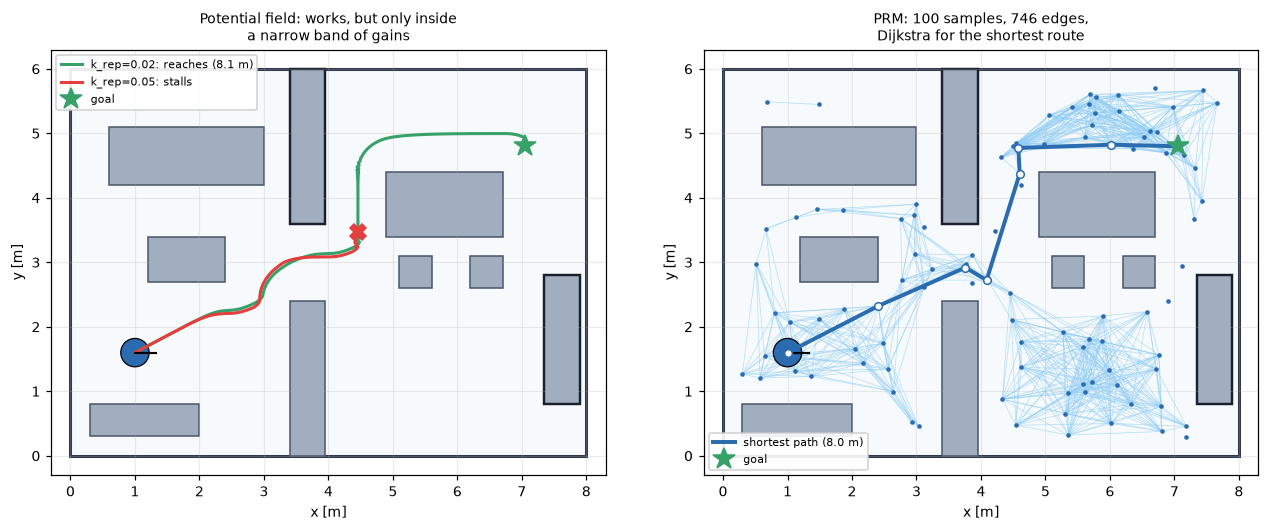

In [150]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.6))

draw_room(ax1, landmarks=False, targets=False)
ax1.plot(PF_PATH[:, 0], PF_PATH[:, 1], color="#38a169", lw=2.0,
         label=f"k_rep={K_SOFT}: reaches ({path_length(PF_PATH):.1f} m)", zorder=6)
ax1.plot(PF_STIFF[:, 0], PF_STIFF[:, 1], color="#e53e3e", lw=2.0,
         label=f"k_rep={K_STIFF}: stalls", zorder=6)
ax1.plot(*PF_STIFF[-1], "X", color="#e53e3e", ms=11, zorder=7)
draw_robot(ax1, START_POSE)
ax1.plot(*GOAL_POSE[:2], "*", color="#38a169", ms=15, zorder=7, label="goal")
ax1.set_title("Potential field: works, but only inside\na narrow band of gains", fontsize=9)
ax1.legend(fontsize=7, loc="upper left", framealpha=0.9)

draw_room(ax2, landmarks=False, targets=False)
for (i, j) in EDGES:
    ax2.plot([SAMPLES[i][0], SAMPLES[j][0]], [SAMPLES[i][1], SAMPLES[j][1]],
             color="#90cdf4", lw=0.5, alpha=0.6, zorder=3)
ax2.plot(SAMPLES[:, 0], SAMPLES[:, 1], ".", color="#2b6cb0", ms=4, zorder=4)
ax2.plot(PLANNED_PATH[:, 0], PLANNED_PATH[:, 1], color="#2b6cb0", lw=2.6,
         label=f"shortest path ({path_length(PLANNED_PATH):.1f} m)", zorder=7)
ax2.plot(PLANNED_PATH[:, 0], PLANNED_PATH[:, 1], "o", mfc="white", mec="#2b6cb0", ms=5, zorder=8)
draw_robot(ax2, START_POSE)
ax2.plot(*GOAL_POSE[:2], "*", color="#38a169", ms=15, zorder=8, label="goal")
ax2.set_title(f"PRM: {len(SAMPLES)} samples, {len(EDGES)} edges,\nDijkstra for the shortest route",
              fontsize=9)
ax2.legend(fontsize=7, loc="lower left", framealpha=0.9)
plt.tight_layout(); plt.show()

## 3.5 From a path to wheel commands

`waypoint_commands` from Task 2 turns on the spot to face each waypoint, then drives straight to
it. The robot stops dead at every corner, which is slower and jerkier than something like pure
pursuit would be. We kept it because it is exactly reproducible: every rate is back solved from a
whole number of steps, so with no noise the trajectory hits each waypoint to machine precision.
That means the drift below is the noise model rather than a controller cutting corners.

The gap between the green and red curves is Task 4's problem.

commands      : 517 steps, 25.9 s
min clearance : 0.299 m (robot radius 0.22 m, planned with 0.27 m)
final true pose: [7.05 4.8  0.  ]
final odom pose: [ 7.245  4.365 -0.092]
dead reckoning error at the goal: 0.476 m


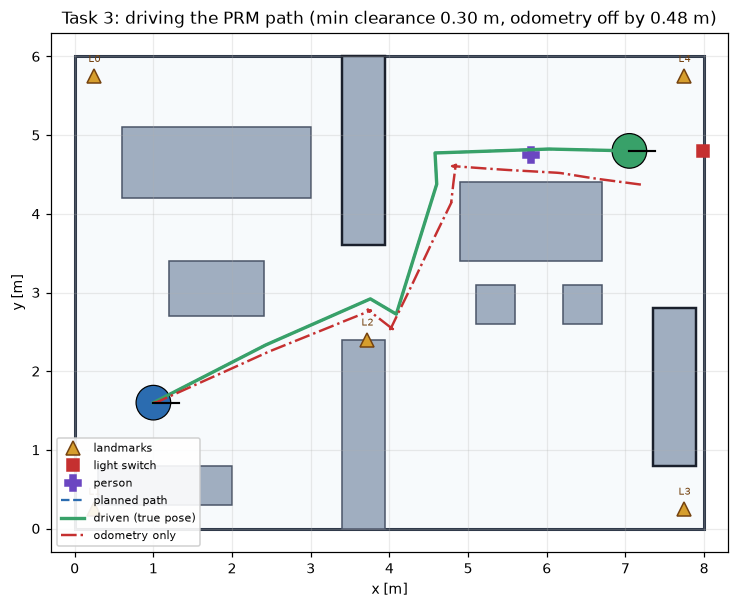

In [151]:
PLANNED_CMDS, PLAN_BOUNDS = waypoint_commands(START_POSE, PLANNED_PATH[1:],
                                              final_heading=GOAL_POSE[2])
PLAN_LOG = run_drive(PLANNED_CMDS, NOISE, seed_stream=310, scan_every=5)

plan_clear = min(ROOM.clearance(p[:2]) for p in PLAN_LOG["true"])
plan_err = float(np.linalg.norm(PLAN_LOG["true"][-1][:2] - PLAN_LOG["odom"][-1][:2]))

print(f"commands      : {len(PLANNED_CMDS)} steps, {len(PLANNED_CMDS) * DT:.1f} s")
print(f"min clearance : {plan_clear:.3f} m (robot radius {ROBOT_RADIUS} m, "
      f"planned with {SAFE_RADIUS} m)")
print(f"final true pose: {np.round(PLAN_LOG['true'][-1], 3)}")
print(f"final odom pose: {np.round(PLAN_LOG['odom'][-1], 3)}")
print(f"dead reckoning error at the goal: {plan_err:.3f} m")

fig, ax = plt.subplots(figsize=(7.4, 5.6))
draw_room(ax)
ax.plot(PLANNED_PATH[:, 0], PLANNED_PATH[:, 1], color="#2b6cb0", lw=1.5, ls="--",
        label="planned path", zorder=6)
ax.plot(PLAN_LOG["true"][:, 0], PLAN_LOG["true"][:, 1], color="#38a169", lw=2.2,
        label="driven (true pose)", zorder=6)
ax.plot(PLAN_LOG["odom"][:, 0], PLAN_LOG["odom"][:, 1], color="#c53030", lw=1.6, ls="-.",
        label="odometry only", zorder=6)
draw_robot(ax, PLAN_LOG["true"][0])
draw_robot(ax, PLAN_LOG["true"][-1], color="#38a169")
ax.set_title(f"Task 3: driving the PRM path (min clearance {plan_clear:.2f} m, "
             f"odometry off by {plan_err:.2f} m)")
ax.legend(fontsize=7.5, loc="lower left", framealpha=0.9)
plt.tight_layout(); plt.show()

## 3.6 Task 3 tests

The collision checker gets the most attention, since both planners trust it completely: through
the doorway is clear, through the partition is not, the straight line to the goal is not, and the
sampling argument from 3.1 holds up even at a ridiculous sample spacing.

The planner tests are structural: every roadmap edge is drivable, the path starts and ends where it
should, every centimetre of it clears the *true* robot radius, and other random seeds still find a
path. Two of them assert claims we make above, so the writeup cannot go stale without a test
failing: that the field reaches the goal at one gain and stalls at the other, and that the PRM path
is shorter.

In [152]:
@test("Task 3")
def test_collision_checks_agree_with_the_room():
    assert in_collision((1.8, 4.65))                      # middle of the sofa
    assert not in_collision(START_POSE[:2])
    assert not in_collision(GOAL_POSE[:2])


@test("Task 3")
def test_an_edge_through_the_doorway_is_clear():
    assert edge_clear((3.00, 3.00), (4.40, 3.00))


@test("Task 3")
def test_an_edge_through_the_partition_is_not():
    assert not edge_clear((3.00, 4.50), (4.50, 4.50))
    # Still blocked with a sample spacing far wider than the wall is thick.
    assert not edge_clear((3.00, 4.50), (4.50, 4.50), spacing=5.0)


@test("Task 3")
def test_the_straight_line_to_the_goal_is_blocked():
    # The reason the planner has to exist at all.
    assert not edge_clear(START_POSE[:2], GOAL_POSE[:2])


@test("Task 3")
def test_the_repulsive_force_pushes_away_from_the_wall():
    # Just left of the counter face at x = 3.40, the push must be in -x.
    F = rep_force((3.05, 1.20))
    assert F[0] < 0 and abs(F[1]) < abs(F[0])
    # And it switches off once the gap is wider than the influence radius.
    assert close(rep_force((3.05, 1.20), rho0=0.05), 0.0)


@test("Task 3")
def test_the_potential_field_is_sensitive_to_its_repulsive_gain():
    # Both of these are claims we make above, so both get asserted.
    assert pf_ok
    assert not pf_stiff_ok


@test("Task 3")
def test_the_potential_field_path_stays_out_of_the_furniture():
    assert pf_clear > ROBOT_RADIUS, pf_clear


@test("Task 3")
def test_the_prm_path_is_shorter_than_the_potential_field_path():
    # Dijkstra returns the best path the roadmap holds; gradient descent only follows the slope.
    assert path_length(PLANNED_PATH) < path_length(PF_PATH)


@test("Task 3")
def test_the_roadmap_edges_are_all_drivable():
    for (i, j) in EDGES:
        assert edge_clear(SAMPLES[i], SAMPLES[j])


@test("Task 3")
def test_the_prm_path_starts_and_ends_where_it_should():
    assert close(PLANNED_PATH[0], START_POSE[:2])
    assert close(PLANNED_PATH[-1], GOAL_POSE[:2])


@test("Task 3")
def test_the_prm_path_is_collision_free_at_the_true_robot_radius():
    # Stricter than the planner's own check: every centimetre, at the real radius.
    for i in range(len(PLANNED_PATH) - 1):
        a, b = PLANNED_PATH[i], PLANNED_PATH[i + 1]
        for t in np.linspace(0, 1, max(2, int(np.linalg.norm(b - a) / 0.01))):
            assert ROOM.clearance(a + t * (b - a)) > ROBOT_RADIUS


@test("Task 3")
def test_the_prm_path_has_to_detour():
    assert path_length(PLANNED_PATH) > straight


@test("Task 3")
def test_the_prm_finds_a_path_from_other_seeds_too():
    for seed in (302, 303):
        s, e = build_prm(seed=seed)
        assert prm_shortest_path(s, e, START_POSE, GOAL_POSE) is not None, seed


@test("Task 3")
def test_the_prm_reports_failure_when_the_goal_is_walled_in():
    # A goal inside the bookshelf has no clear edge to any sample, so Dijkstra cannot reach it.
    assert prm_shortest_path(SAMPLES, EDGES, START_POSE, (7.60, 1.80)) is None


@test("Task 3")
def test_the_planned_commands_reach_the_goal_without_noise():
    clean = run_drive(PLANNED_CMDS, NOISE.scaled(0.0), seed_stream=399, scan_every=10**6)
    assert poses_close(clean["true"][-1], GOAL_POSE, 1e-9), clean["true"][-1]


@test("Task 3")
def test_the_driven_path_clears_the_furniture():
    assert plan_clear > ROBOT_RADIUS, plan_clear


run_tests("Task 3")

  pass    collision checks agree with the room
  pass    an edge through the doorway is clear
  pass    an edge through the partition is not
  pass    the straight line to the goal is blocked
  pass    the repulsive force pushes away from the wall
  pass    the potential field is sensitive to its repulsive gain
  pass    the potential field path stays out of the furniture
  pass    the prm path is shorter than the potential field path
  pass    the roadmap edges are all drivable
  pass    the prm path starts and ends where it should
  pass    the prm path is collision free at the true robot radius
  pass    the prm path has to detour
  pass    the prm finds a path from other seeds too
  pass    the prm reports failure when the goal is walled in
  pass    the planned commands reach the goal without noise
  pass    the driven path clears the furniture

16/16 tests passed (Task 3)


16

---
# Task 4: Probabilistic Localization

Dead reckoning drifts about half a metre over this 26 second drive. Task 6 has to put a gripper on
a light switch, so that has to come down.

## 4.1 Why an EKF and not a particle filter

Our belief about the pose is one tight blob, which is the case a Gaussian describes well: the state
is only 3 dimensional, the robot starts on a known dock, landmarks come in already identified, and
one range and bearing reading at $\sigma_r = 3.5$ cm, $\sigma_b = 1.6°$ pins the pose down to a few
centimetres. A particle filter would work too, but nothing here seems to need one, and it costs per
particle where the EKF costs three by three matrices.

The trade off is that **an EKF cannot recover from being badly lost.** A belief that means
"somewhere in one of several places" is not a Gaussian, so a filter started without knowing where it
was would settle confidently on the wrong answer. A particle filter can handle that; we are relying
on the known dock instead.

## 4.2 The filter

$$\bar\mu = g(\mu, u), \quad \bar\Sigma = F \Sigma F^{\mathsf T} + Q,
\qquad K = \bar\Sigma H^{\mathsf T}\left(H \bar\Sigma H^{\mathsf T} + R\right)^{-1}$$

The algorithm is the standard one. The two choices we made are about the noise matrices:

**$Q$ is derived rather than tuned.** Task 2 already says how noisy the odometry is, so `motion_cov`
turns those alphas into a per step covariance. It shrinks when the robot slows down and grows when
it turns hard.

**$R$ is rebuilt for each reading**, since the range noise grows with range, and floored at 0.1 mm.
The floor took us a while to work out: with a noise free sensor $R = 0$, and then
$H \bar\Sigma H^{\mathsf T} + R$ goes singular as soon as $\bar\Sigma$ collapses and the update
cannot be solved at all.

One thing we left approximate: the predict step uses the Euler update while Task 1 integrates the
arc exactly. At a 0.05 s step the two differ by about 0.4 mm, which is well under what $Q$ already
models, so we left it. There is a test on that gap, since at a 1 s step it would matter.

In [153]:
def ekf_predict(mu, Sigma, v, omega, dt, Q):
    """Predict step: move the mean, grow the covariance. Returns (mu, Sigma)."""
    x, y, th = mu
    mu_pred = np.array([x + v * np.cos(th) * dt, y + v * np.sin(th) * dt, th + omega * dt])
    F = np.array([[1, 0, -v * np.sin(th) * dt],
                  [0, 1,  v * np.cos(th) * dt],
                  [0, 0, 1]])
    return mu_pred, F @ Sigma @ F.T + Q


def ekf_update(mu_pred, Sigma_pred, z, landmark, R):
    """Correct the state with one range and bearing reading. Returns (mu, Sigma)."""
    lx, ly = landmark
    dx, dy = lx - mu_pred[0], ly - mu_pred[1]
    q = dx**2 + dy**2
    z_hat = np.array([np.sqrt(q), np.arctan2(dy, dx) - mu_pred[2]])
    H = np.array([[-dx / np.sqrt(q), -dy / np.sqrt(q), 0],
                  [dy / q, -dx / q, -1]])
    S_cov = H @ Sigma_pred @ H.T + R
    K = Sigma_pred @ H.T @ np.linalg.inv(S_cov)
    y_err = z - z_hat
    y_err[1] = wrap_to_pi(y_err[1])       # a bearing residual has to be wrapped
    mu = mu_pred + K @ y_err
    Sigma = (np.eye(3) - K @ H) @ Sigma_pred
    return mu, Sigma


def motion_cov(v, omega, dt, noise: NoiseParams = NOISE):
    """Motion noise covariance Q for one step, from the Task 2 odometry alphas.

    The velocity standard deviations sqrt(a1 v^2 + a2 w^2) and sqrt(a3 v^2 + a4 w^2) become
    position and heading standard deviations of sigma * dt over one step.
    """
    var_v = noise.a1 * v**2 + noise.a2 * omega**2
    var_w = noise.a3 * v**2 + noise.a4 * omega**2
    return np.diag([var_v * dt**2, var_v * dt**2, var_w * dt**2])


def rmse(est, truth):
    """Root mean square position error between two (N, 2) tracks [m]."""
    return float(np.sqrt(np.mean(np.sum((np.asarray(est) - np.asarray(truth))**2, axis=1))))


def run_ekf(log, room=ROOM, noise=NOISE, start_pose=START_POSE, dt=DT):
    """Run predict and update once per control step over a recorded drive.

    Returns (estimates (N, 3), position standard deviation (N,)). The filter only gets the
    commands and the landmark readings, never the true pose; `start_pose` is the known dock.
    """
    mu = np.array(start_pose, dtype=float)
    Sigma = np.diag([0.05**2, 0.05**2, np.deg2rad(3.0)**2])
    est, sd = [mu.copy()], [np.sqrt(Sigma[0, 0] + Sigma[1, 1])]

    for k, (v, omega) in enumerate(log["cmds"]):
        mu, Sigma = ekf_predict(mu, Sigma, v, omega, dt, motion_cov(v, omega, dt, noise))
        for lm_id, r, b in log["obs"][k]:
            # Range noise grows with range, so R is rebuilt per reading rather than fixed. The
            # floors matter: a noise free sensor gives R = 0, and then H Sigma H^T + R goes
            # singular as soon as Sigma collapses. Treating it as a 0.1 mm sensor avoids that.
            sigma_r = max(noise.sigma_r0 + noise.sigma_r1 * r, 1e-4)
            sigma_b = max(noise.sigma_b, 1e-6)
            R = np.diag([sigma_r**2, sigma_b**2])
            mu, Sigma = ekf_update(mu, Sigma, np.array([r, b]), room.landmarks[lm_id], R)
        mu[2] = wrap_to_pi(mu[2])
        est.append(mu.copy())
        sd.append(np.sqrt(Sigma[0, 0] + Sigma[1, 1]))

    return np.array(est), np.array(sd)

## 4.3 Results

The filter is handed the wheel commands and the landmark readings, and nothing else. The true pose
is used afterwards to score it.

In [154]:
EKF_EST, EKF_SD = run_ekf(PLAN_LOG)

odom_err = np.linalg.norm(PLAN_LOG["true"][:, :2] - PLAN_LOG["odom"][:, :2], axis=1)
ekf_err = np.linalg.norm(PLAN_LOG["true"][:, :2] - EKF_EST[:, :2], axis=1)
odom_rmse = rmse(PLAN_LOG["odom"][:, :2], PLAN_LOG["true"][:, :2])
ekf_rmse = rmse(EKF_EST[:, :2], PLAN_LOG["true"][:, :2])
n_seen = np.array([0] + [len(o) for o in PLAN_LOG["obs"]])

print(f"{len(PLAN_LOG['cmds'])} steps, {n_seen.mean():.2f} landmarks visible per step "
      f"(none on {100 * np.mean(n_seen == 0):.0f}% of steps)\n")
print(f"{'':<20}{'RMSE [m]':>10}{'final [m]':>11}{'worst [m]':>11}")
print("-" * 52)
for name, e in [("dead reckoning", odom_err), ("EKF", ekf_err)]:
    print(f"{name:<20}{np.sqrt(np.mean(e**2)):>10.3f}{e[-1]:>11.3f}{e.max():>11.3f}")
print(f"\nEKF error is {ekf_rmse / odom_rmse:.2f}x the dead reckoning error")
print(f"final heading error: dead reckoning "
      f"{np.rad2deg(abs(wrap_to_pi(PLAN_LOG['true'][-1, 2] - PLAN_LOG['odom'][-1, 2]))):.1f} deg, "
      f"EKF {np.rad2deg(abs(wrap_to_pi(PLAN_LOG['true'][-1, 2] - EKF_EST[-1, 2]))):.1f} deg")

517 steps, 3.64 landmarks visible per step (none on 0% of steps)

                      RMSE [m]  final [m]  worst [m]
----------------------------------------------------
dead reckoning           0.241      0.476      0.476
EKF                      0.015      0.028      0.037

EKF error is 0.06x the dead reckoning error
final heading error: dead reckoning 5.3 deg, EKF 0.6 deg


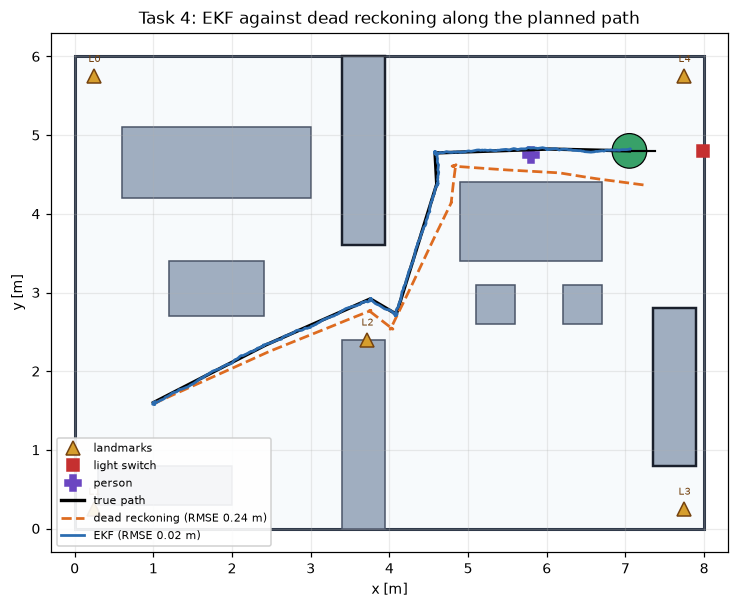

In [155]:
fig, ax = plt.subplots(figsize=(7.4, 5.6))
draw_room(ax)
ax.plot(PLAN_LOG["true"][:, 0], PLAN_LOG["true"][:, 1], "k-", lw=2.2, label="true path", zorder=7)
ax.plot(PLAN_LOG["odom"][:, 0], PLAN_LOG["odom"][:, 1], "--", color="#dd6b20", lw=1.8,
        label=f"dead reckoning (RMSE {odom_rmse:.2f} m)", zorder=7)
ax.plot(EKF_EST[:, 0], EKF_EST[:, 1], "-", color="#2b6cb0", lw=1.8,
        label=f"EKF (RMSE {ekf_rmse:.2f} m)", zorder=8)
draw_robot(ax, PLAN_LOG["true"][-1], color="#38a169")
ax.set_title("Task 4: EKF against dead reckoning along the planned path")
ax.legend(fontsize=7.5, loc="lower left", framealpha=0.9)
plt.tight_layout(); plt.show()

## 4.4 Is the filter honest, and does it hold up

The dotted line on the left is the $2\sigma$ the EKF claims **for itself**. If the solid error line
sat above it much of the time the filter would be overconfident, which is the usual EKF complaint,
since linearising tends to understate the real uncertainty. Ours does not, so the covariance is
usable by whatever reads it later.

The right panel reruns the drive at each noise scale from section 2.7. The odometry gets worse as
expected and the EKF barely moves. At a scale of 0 both are exact, which is our check that the
filter adds no error of its own.

We should be honest about why the result looks this good. The filter takes out over 90% of the dead
reckoning error, but a lot of that is the sensor: five separately identified beacons, visible on
nearly every step. Making localization actually hard would mean changing the **information** rather
than the noise scale — anonymous landmarks that need data association, or lidar only scan matching
with no beacons at all.

 noise scale   dead reckoning RMSE [m]   EKF RMSE [m]
-----------------------------------------------------
           0                     0.000          0.000
         0.5                     0.314          0.007
           1                     0.297          0.013
           2                     0.331          0.027


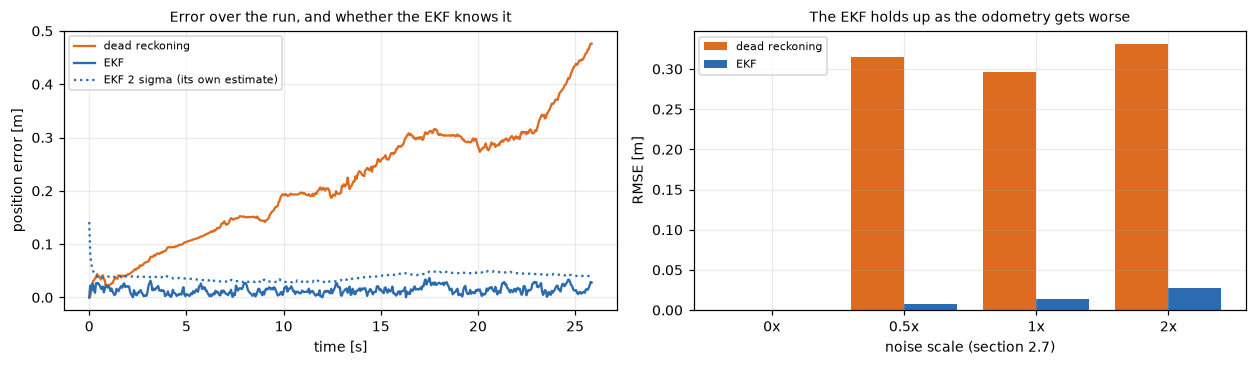

In [156]:
SWEEP_SCALES = [0.0, 0.5, 1.0, 2.0]
rows = []
for s in SWEEP_SCALES:
    params = NOISE.scaled(s)
    lg = run_drive(PLANNED_CMDS, params, seed_stream=430, scan_every=10**6)
    est, _ = run_ekf(lg, noise=params)
    rows.append((s, rmse(lg["odom"][:, :2], lg["true"][:, :2]),
                 rmse(est[:, :2], lg["true"][:, :2])))

print(f"{'noise scale':>12}{'dead reckoning RMSE [m]':>26}{'EKF RMSE [m]':>15}")
print("-" * 53)
for s, o, e in rows:
    print(f"{s:>12g}{o:>26.3f}{e:>15.3f}")

fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.4))
axes[0].plot(PLAN_LOG["t"], odom_err, color="#dd6b20", label="dead reckoning")
axes[0].plot(PLAN_LOG["t"], ekf_err, color="#2b6cb0", label="EKF")
axes[0].plot(PLAN_LOG["t"], 2 * EKF_SD, ":", color="#2b6cb0",
             label="EKF 2 sigma (its own estimate)")
axes[0].set_xlabel("time [s]"); axes[0].set_ylabel("position error [m]")
axes[0].set_title("Error over the run, and whether the EKF knows it", fontsize=9)
axes[0].legend(fontsize=7)

r = np.array(rows)
idx = np.arange(len(SWEEP_SCALES))
axes[1].bar(idx - 0.2, r[:, 1], 0.4, label="dead reckoning", color="#dd6b20")
axes[1].bar(idx + 0.2, r[:, 2], 0.4, label="EKF", color="#2b6cb0")
axes[1].set_xticks(idx, [f"{s:g}x" for s in SWEEP_SCALES])
axes[1].set_xlabel("noise scale (section 2.7)"); axes[1].set_ylabel("RMSE [m]")
axes[1].set_title("The EKF holds up as the odometry gets worse", fontsize=9)
axes[1].legend(fontsize=7.5)
plt.tight_layout(); plt.show()

## 4.5 Task 4 tests

We test the two steps separately before testing the whole filter, since a filter that works overall
can still hide a broken piece: predict moves the mean the way the robot drove, predict grows the
covariance and update shrinks it, an update pulls a deliberately wrong estimate back towards the
truth, and the bearing residual is wrapped (without that, a reading across the $\pm\pi$ join gives a
residual of about $2\pi$ and throws the estimate across the room).

Then the behaviour: beating dead reckoning by more than 3x, tracking a noise free run to within a
centimetre, still winning at double noise, and the covariance only ever growing while the robot
cannot see a landmark, which is the case where the EKF turns back into dead reckoning.

In [157]:
@test("Task 4")
def test_the_predict_step_moves_the_mean_the_way_the_robot_drove():
    # Driving straight along +x for 1 s at 0.5 m/s from the origin pose.
    mu, _ = ekf_predict(np.zeros(3), np.zeros((3, 3)), 0.5, 0.0, 1.0, np.zeros((3, 3)))
    assert close(mu, [0.5, 0.0, 0.0])
    # A pure rotation moves the heading and nothing else.
    mu, _ = ekf_predict(np.zeros(3), np.zeros((3, 3)), 0.0, 0.4, 0.5, np.zeros((3, 3)))
    assert close(mu, [0.0, 0.0, 0.2])


@test("Task 4")
def test_the_euler_predict_barely_differs_from_task_1s_exact_arc():
    # The predict step uses the Euler update while Task 1 integrates the arc exactly. At a 0.05 s
    # step the gap is a fraction of a millimetre, far below Q, so it costs nothing here.
    mu = np.array([1.0, 2.0, 0.3])
    euler, _ = ekf_predict(mu, np.zeros((3, 3)), 0.45, 0.70, DT, np.zeros((3, 3)))
    exact = unicycle_step(mu, 0.45, 0.70, DT)
    assert np.linalg.norm(euler[:2] - exact[:2]) < 1e-3


@test("Task 4")
def test_predicting_makes_the_robot_less_sure_and_updating_makes_it_more_sure():
    mu, Sigma = np.array([2.0, 2.0, 0.0]), np.diag([0.05, 0.05, 0.01])
    mu_p, Sigma_p = ekf_predict(mu, Sigma, 0.45, 0.2, DT, motion_cov(0.45, 0.2, DT))
    assert np.trace(Sigma_p) > np.trace(Sigma)

    lm = ROOM.landmarks[2]
    z = np.array([np.linalg.norm(lm - mu_p[:2]),
                  wrap_to_pi(np.arctan2(lm[1] - mu_p[1], lm[0] - mu_p[0]) - mu_p[2])])
    _, Sigma_u = ekf_update(mu_p, Sigma_p, z, lm, np.diag([0.035**2, np.deg2rad(1.6)**2]))
    assert np.trace(Sigma_u) < np.trace(Sigma_p)


@test("Task 4")
def test_an_update_pulls_the_estimate_towards_the_truth():
    truth = np.array([4.30, 0.60, 0.40])
    wrong = truth + [0.30, -0.25, 0.05]                # the filter's guess, deliberately off
    mu, Sigma = wrong.copy(), np.diag([0.2, 0.2, 0.05])
    for lm_id, r, b in observe_landmarks(truth, ROOM, NOISE.scaled(0.0), make_rng(4001)):
        mu, Sigma = ekf_update(mu, Sigma, np.array([r, b]), ROOM.landmarks[lm_id],
                               np.diag([0.035**2, np.deg2rad(1.6)**2]))
    assert np.linalg.norm(mu[:2] - truth[:2]) < np.linalg.norm(wrong[:2] - truth[:2]) / 3


@test("Task 4")
def test_the_bearing_residual_is_wrapped():
    # A reading taken across the +/-pi join. Without wrapping, the residual comes out at about
    # 2 pi and the update throws the estimate right across the room.
    mu = np.array([4.0, 3.0, np.pi - 0.02])
    lm = np.array([1.0, 3.0])
    z = np.array([3.0, wrap_to_pi(np.pi - mu[2])])     # the true reading, just over the join
    out, _ = ekf_update(mu, np.diag([0.1, 0.1, 0.05]), z, lm,
                        np.diag([0.035**2, np.deg2rad(1.6)**2]))
    assert np.linalg.norm(out[:2] - mu[:2]) < 0.2, out


@test("Task 4")
def test_the_motion_covariance_grows_with_speed_and_vanishes_at_rest():
    assert close(motion_cov(0.0, 0.0, DT), 0.0)
    assert np.trace(motion_cov(0.45, 0.0, DT)) < np.trace(motion_cov(0.45, 0.7, DT))


@test("Task 4")
def test_rmse_is_zero_for_a_perfect_estimate():
    truth = PLAN_LOG["true"][:, :2]
    assert close(rmse(truth, truth), 0.0)
    assert rmse(truth + 0.1, truth) > 0.1


@test("Task 4")
def test_the_ekf_beats_dead_reckoning():
    # The main claim of this task, asserted rather than eyeballed off the plot.
    assert ekf_rmse < 0.3 * odom_rmse, (ekf_rmse, odom_rmse)
    assert ekf_err[-1] < odom_err[-1]


@test("Task 4")
def test_the_ekf_stays_accurate_the_whole_way():
    assert ekf_err.max() < 0.20, ekf_err.max()


@test("Task 4")
def test_a_noise_free_run_is_tracked_almost_exactly():
    clean = run_drive(PLANNED_CMDS, NOISE.scaled(0.0), seed_stream=4002, scan_every=10**6)
    est, _ = run_ekf(clean, noise=NOISE.scaled(0.0))
    # The only error left is the Euler versus arc mismatch in the predict step.
    assert np.max(np.linalg.norm(clean["true"][:, :2] - est[:, :2], axis=1)) < 0.01


@test("Task 4")
def test_the_ekf_is_deterministic_and_still_wins_at_double_noise():
    params = NOISE.scaled(2.0)
    lg = run_drive(PLANNED_CMDS, params, seed_stream=4003, scan_every=10**6)
    a, _ = run_ekf(lg, noise=params)
    b, _ = run_ekf(lg, noise=params)
    assert close(a, b, 0.0)
    assert rmse(a[:, :2], lg["true"][:, :2]) < 0.5 * rmse(lg["odom"][:, :2], lg["true"][:, :2])


@test("Task 4")
def test_the_uncertainty_grows_while_the_robot_is_blind():
    # No landmarks in range at all, so there is nothing to correct with and the covariance can
    # only grow. This is also the case where the EKF degenerates to plain dead reckoning.
    params = replace(NOISE, lm_max_range=0.01)
    blind = run_drive(PLANNED_CMDS, params, seed_stream=4004, scan_every=10**6)
    _, sd = run_ekf(blind, noise=params)
    assert np.all(np.isfinite(sd)) and np.all(sd > 0)
    assert np.all(np.diff(sd) > -1e-12), "covariance shrank with no measurements"
    assert sd[-1] > sd[0]


run_tests("Task 4")

  pass    the predict step moves the mean the way the robot drove
  pass    the euler predict barely differs from task 1s exact arc
  pass    predicting makes the robot less sure and updating makes it more sure
  pass    an update pulls the estimate towards the truth
  pass    the bearing residual is wrapped
  pass    the motion covariance grows with speed and vanishes at rest
  pass    rmse is zero for a perfect estimate
  pass    the ekf beats dead reckoning
  pass    the ekf stays accurate the whole way
  pass    a noise free run is tracked almost exactly
  pass    the ekf is deterministic and still wins at double noise
  pass    the uncertainty grows while the robot is blind

12/12 tests passed (Task 4)


12

---
# Task 5: Occupancy Grid Mapping

## 5.1 Log odds

Each cell holds $\ell = \log\frac{p}{1-p}$, which means combining evidence is **addition** instead
of Bayes' rule: a new reading is `grid[cx, cy] += l_free` or `+= l_occ`, and that is the whole
inverse sensor model. $\ell = 0$ is exactly $p = 0.5$, which is a convenient way to say nobody has
looked at this cell yet.

The two values are $\log(0.3/0.7) = -0.85$ and $\log(0.9/0.1) = +2.20$. We made them asymmetric on
purpose: a beam bouncing back is strong evidence of a surface, while a beam passing through is
weaker evidence of empty space, so it takes about three free readings to undo one hit.

We also clamp $|\ell| \le 6$. Without it, a cell seen fifty times ends up at a $p$ so close to 1
that fifty readings saying otherwise could not bring it back down.

## 5.2 Two things we got wrong first time

**A beam that hit nothing is not an obstacle.** Task 2's lidar returns `inf` when nothing is within
5 m, and marking that endpoint occupied puts a ring of walls round the robot at exactly 5 m.

**The end cell gets occupied evidence only.** If it is included in the free sweep too, every
obstacle gets $-0.85 + 2.20$ instead of $+2.20$ and the walls come out grey.

Both have tests now. We feed in every 4th beam, so 45 of the 180, which is plenty at 104 sweeps and
keeps this section quick to run.

In [158]:
def logodds(p):
    """Probability to log odds."""
    return np.log(p / (1 - p))


def prob(l):
    """Log odds to probability."""
    return 1 / (1 + np.exp(-l))


CELL = 0.10                                   # metres per cell
GRID_NX = int(round(ROOM.width / CELL))       # 80
GRID_NY = int(round(ROOM.height / CELL))      # 60
L_FREE, L_OCC = logodds(0.3), logodds(0.9)    # -0.85 and +2.20
L_CLAMP = 6.0                                 # cap on |log odds|, i.e. p inside [0.0025, 0.9975]
BEAM_STRIDE = 4                               # use every 4th lidar beam, so 45 of the 180


def world_to_cell(x, y):
    """(x, y) in metres to (col, row) cell indices, clipped to the grid."""
    return (int(np.clip(x / CELL, 0, GRID_NX - 1)),
            int(np.clip(y / CELL, 0, GRID_NY - 1)))


def update_beam(grid, pose, angle, r, max_range):
    """Fold one beam into the grid: free along the ray, occupied at the cell it stopped in.

    The two `+=` lines below are the whole inverse sensor model. A beam that got all the way to
    `max_range` found nothing, so it marks free space and no obstacle.
    """
    x0, y0, theta = pose
    ang = theta + angle
    n_samples = int(max(r, 0.1) / CELL) * 2 + 2      # two samples per cell

    for s in np.linspace(0, min(r, max_range), n_samples):
        px, py = x0 + s * np.cos(ang), y0 + s * np.sin(ang)
        if not (0 <= px <= ROOM.width and 0 <= py <= ROOM.height):
            continue
        cx, cy = world_to_cell(px, py)
        if s < r - CELL:
            grid[cx, cy] += L_FREE
        elif r < max_range - 0.05:
            grid[cx, cy] += L_OCC

    # Clamping is what lets the map change its mind later: a cell pinned at p = 1 would need
    # hundreds of readings saying otherwise to come back down.
    np.clip(grid, -L_CLAMP, L_CLAMP, out=grid)


def build_map(place_poses, log=None, max_range=NOISE.lidar_max_range):
    """Build a log odds grid from the recorded scans, filed at `place_poses`.

    Returns the (GRID_NX, GRID_NY) grid. The beams are always the ones taken at the true pose,
    since that is where the robot actually was; only where we think it was changes.
    """
    log = log or PLAN_LOG
    grid = np.zeros((GRID_NX, GRID_NY))
    for k, scan in enumerate(log["scans"]):
        if scan is None:
            continue
        angles, ranges = scan
        for angle, r in zip(angles[::BEAM_STRIDE], ranges[::BEAM_STRIDE]):
            # Task 2's lidar reports inf for a beam that found nothing; the model wants max_range.
            update_beam(grid, place_poses[k + 1], angle,
                        max_range if not np.isfinite(r) else r, max_range)
    return grid

## 5.3 Four maps from the same beams

The lidar always fires from the true pose, since that is where the robot actually was. The only
thing that changes between these four maps is **where we think it was** when the readings get
filed. We report two numbers each, because accuracy on its own means nothing: a map that says
"unknown" everywhere would score 100%.

The last row is the one that caught us out. Poses corrupted by 0.5 m give the **highest** coverage
of the four while being wrong a quarter of the time. Smearing the readings across neighbouring
cells makes the robot commit to more of the room and get more of it wrong, which is the worst of
both. So mapping quality is capped by localization quality.

In [159]:
# Ground truth at the mapping resolution. `rasterize` indexes [row, col] = [y, x] while these
# grids are [x, y], hence the transpose. A beam that stops on a wall lands in the outermost ring
# of cells, so the truth we score against marks that ring occupied too.
GT_MAP = rasterize(ROOM, CELL)[0].T.astype(float)
GT_MAP[0, :] = GT_MAP[-1, :] = 1
GT_MAP[:, 0] = GT_MAP[:, -1] = 1


def score_map(grid, gt=GT_MAP, p_occ=0.65, p_free=0.35):
    """Compare a grid against the ground truth.

    Returns a dict of `coverage` (fraction of cells committed to either way), `accuracy`
    (fraction of those that are right) and `false_walls`. Coverage has to be reported next to
    accuracy, or a map that says "unknown" everywhere scores 100%.
    """
    p = prob(grid)
    said_occ, said_free = p > p_occ, p < p_free
    known = said_occ | said_free
    correct = (said_occ & (gt == 1)) | (said_free & (gt == 0))
    return dict(coverage=float(known.mean()),
                accuracy=float(correct[known].mean()) if known.any() else 0.0,
                false_walls=int(np.sum(said_occ & (gt == 0))))


# Four maps from the same beams, differing only in the pose they are filed under.
bad_rng = make_rng(501)
BAD_POSES = PLAN_LOG["true"].copy()
BAD_POSES[:, :2] += bad_rng.normal(0, 0.5, (len(BAD_POSES), 2))
BAD_POSES[:, 2] += bad_rng.normal(0, np.deg2rad(10), len(BAD_POSES))

MAPS = {"true pose": build_map(PLAN_LOG["true"]),
        "EKF estimate": build_map(EKF_EST),
        "odometry only": build_map(PLAN_LOG["odom"]),
        "0.5 m error": build_map(BAD_POSES)}
ESTIMATED_MAP = MAPS["EKF estimate"]     # the only one a real robot could build

n_scans = sum(1 for s in PLAN_LOG["scans"] if s is not None)
print(f"{n_scans} sweeps x {len(range(0, NOISE.n_beams, BEAM_STRIDE))} beams into a "
      f"{GRID_NX} x {GRID_NY} grid at {CELL} m\n")
print(f"{'beams placed at':<18}{'coverage':>10}{'accuracy':>10}{'false walls':>13}")
print("-" * 51)
for name, grid in MAPS.items():
    s = score_map(grid)
    print(f"{name:<18}{s['coverage']:>9.1%}{s['accuracy']:>10.1%}{s['false_walls']:>13d}")

104 sweeps x 45 beams into a 80 x 60 grid at 0.1 m

beams placed at     coverage  accuracy  false walls
---------------------------------------------------
true pose             79.4%     91.3%          144
EKF estimate          79.3%     91.7%          141
odometry only         80.9%     79.9%          287
0.5 m error           93.8%     74.7%          109


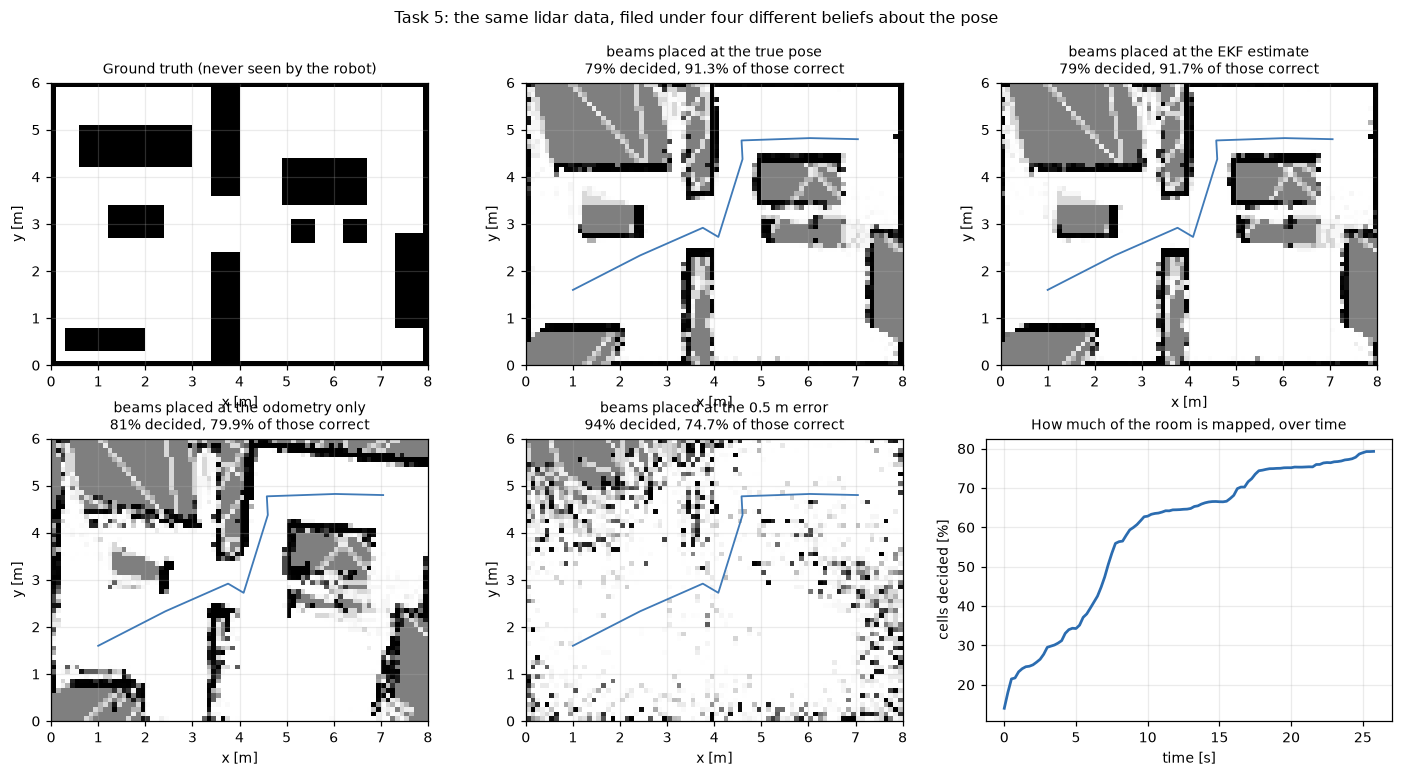

In [160]:
fig, axes = plt.subplots(2, 3, figsize=(13, 7.0))
extent = [0, ROOM.width, 0, ROOM.height]

axes[0, 0].imshow(GT_MAP.T, origin="lower", cmap="gray_r", extent=extent, vmin=0, vmax=1)
axes[0, 0].set_title("Ground truth (never seen by the robot)", fontsize=9)

for ax, (name, grid) in zip(axes.flat[1:], MAPS.items()):
    s = score_map(grid)
    # Dark = probably occupied, white = probably free, mid grey = never observed.
    ax.imshow(prob(grid).T, origin="lower", cmap="gray_r", extent=extent, vmin=0, vmax=1)
    ax.plot(PLAN_LOG["true"][:, 0], PLAN_LOG["true"][:, 1], color="#2b6cb0", lw=1.2, alpha=0.9)
    ax.set_title(f"beams placed at the {name}\n"
                 f"{s['coverage']:.0%} decided, {s['accuracy']:.1%} of those correct", fontsize=9)

# The last panel: how the map fills in over time, using the EKF poses.
ax = axes[1, 2]
fill = []
grid = np.zeros((GRID_NX, GRID_NY))
for k, scan in enumerate(PLAN_LOG["scans"]):
    if scan is not None:
        angles, ranges = scan
        for angle, r in zip(angles[::BEAM_STRIDE], ranges[::BEAM_STRIDE]):
            update_beam(grid, EKF_EST[k + 1], angle,
                        NOISE.lidar_max_range if not np.isfinite(r) else r,
                        NOISE.lidar_max_range)
        fill.append((k * DT, score_map(grid)["coverage"]))
fill = np.array(fill)
ax.plot(fill[:, 0], 100 * fill[:, 1], color="#2b6cb0", lw=1.8)
ax.set_xlabel("time [s]"); ax.set_ylabel("cells decided [%]")
ax.set_title("How much of the room is mapped, over time", fontsize=9)
ax.set_aspect("auto")

for ax in axes.flat[:5]:
    ax.set_xlabel("x [m]"); ax.set_ylabel("y [m]")
fig.suptitle("Task 5: the same lidar data, filed under four different beliefs about the pose",
             y=1.00, fontsize=10.5)
plt.tight_layout(); plt.show()

## 5.4 Task 5 tests

The sensor model is tested one beam at a time, using a ray we hand checked back in Task 2: from the
start pose straight ahead the counter face is 2.40 m away, so the cells in front have to come out
free, the cell at 2.40 m occupied, and a cell off to the side untouched. A separate test fires a
maximum range beam and checks nothing anywhere is marked occupied.

The map level test goes down the ladder of pose quality and asserts each rung is worse than the one
above it: true pose, EKF, odometry, 0.5 m error, with the EKF map required to stay within two
percentage points of the perfect one. That assertion is our argument for feeding Task 4's estimate
into Task 5 instead of mapping off the wheel encoders.

In [161]:
@test("Task 5")
def test_log_odds_and_probability_round_trip():
    assert close(prob(0.0), 0.5)                      # an untouched cell means "no idea"
    for p in (0.05, 0.3, 0.5, 0.9, 0.99):
        assert close(prob(logodds(p)), p, 1e-12)


@test("Task 5")
def test_evidence_accumulates_and_is_deliberately_asymmetric():
    assert prob(2 * L_FREE) < prob(L_FREE) < 0.5
    assert prob(2 * L_OCC) > prob(L_OCC) > 0.5
    # The two values are not symmetric: +2.20 against -0.85, so one reflection outweighs one
    # pass-through. That is the right way round, and it means a cell needs roughly three free
    # readings to undo one hit.
    assert L_OCC > -L_FREE
    assert prob(L_FREE + L_OCC) > 0.5


@test("Task 5")
def test_cells_cover_the_room_and_clip_at_its_edges():
    assert world_to_cell(0.0, 0.0) == (0, 0)
    assert world_to_cell(0.05, 0.05) == (0, 0)
    assert world_to_cell(0.15, 0.15) == (1, 1)
    assert world_to_cell(ROOM.width, ROOM.height) == (GRID_NX - 1, GRID_NY - 1)
    assert world_to_cell(99.0, -99.0) == (GRID_NX - 1, 0)      # clipped, not wrapped


@test("Task 5")
def test_one_beam_marks_free_space_and_one_obstacle():
    # From the start pose, straight ahead, the counter face is 2.40 m away (a Task 2 hand check).
    grid = np.zeros((GRID_NX, GRID_NY))
    update_beam(grid, (1.00, 1.60, 0.0), 0.0, 2.40, NOISE.lidar_max_range)
    cx, cy = world_to_cell(1.00 + 2.40, 1.60)
    assert grid[cx, cy] > 0, "the obstacle at the end of the beam was not marked"
    for x in (1.5, 2.0, 3.0):
        cx, cy = world_to_cell(x, 1.60)
        assert grid[cx, cy] < 0, x
    cx, cy = world_to_cell(1.00, 3.00)                          # well off the beam
    assert close(grid[cx, cy], 0.0)


@test("Task 5")
def test_a_beam_that_hit_nothing_marks_no_obstacle():
    grid = np.zeros((GRID_NX, GRID_NY))
    update_beam(grid, (1.00, 3.00, 0.0), 0.0, NOISE.lidar_max_range, NOISE.lidar_max_range)
    assert np.all(grid <= 0), "a maximum range return must not create an obstacle"
    cx, cy = world_to_cell(1.00 + NOISE.lidar_max_range - 0.2, 3.00)
    assert grid[cx, cy] < 0, "it should still clear the space it passed through"


@test("Task 5")
def test_the_log_odds_stay_clamped():
    grid = np.zeros((GRID_NX, GRID_NY))
    for _ in range(200):
        update_beam(grid, (1.00, 1.60, 0.0), 0.0, 2.40, NOISE.lidar_max_range)
    assert np.max(np.abs(grid)) <= L_CLAMP + 1e-12
    assert prob(grid.max()) < 1.0


@test("Task 5")
def test_the_map_from_the_true_pose_is_accurate():
    s = score_map(MAPS["true pose"])
    assert s["accuracy"] > 0.90, s
    assert s["coverage"] > 0.50, s


@test("Task 5")
def test_localization_quality_sets_mapping_quality():
    # The point of wiring Task 4 into Task 5. Each step of the ladder should be worse than the one
    # above it, and the deliberately bad poses worst of all.
    acc = [score_map(MAPS[k])["accuracy"] for k in
           ("true pose", "EKF estimate", "odometry only", "0.5 m error")]
    assert acc[1] > acc[0] - 0.02, acc          # the EKF map is as good as the perfect one
    assert acc[1] > acc[2] > acc[3], acc
    assert (score_map(MAPS["EKF estimate"])["false_walls"]
            < score_map(MAPS["odometry only"])["false_walls"])


@test("Task 5")
def test_the_map_has_free_occupied_and_unknown_cells():
    p = prob(ESTIMATED_MAP)
    assert np.any(p > 0.65) and np.any(p < 0.35)
    assert np.any((p >= 0.35) & (p <= 0.65))


@test("Task 5")
def test_the_furniture_beside_the_path_shows_up():
    p = prob(ESTIMATED_MAP)
    for name in ("kitchen counter", "partition wall"):
        f = next(f for f in ROOM.furniture if f.name == name)
        c0, r0 = world_to_cell(f.x, f.y)
        c1, r1 = world_to_cell(f.x + f.w, f.y + f.h)
        assert np.any(p[c0:c1 + 1, r0:r1 + 1] > 0.65), f"{name} was never seen"


@test("Task 5")
def test_what_the_robot_never_looked_at_stays_unknown():
    # The inside of the bookshelf is never in view, so the map must not guess about it.
    cx, cy = world_to_cell(7.60, 1.80)
    assert 0.35 <= prob(ESTIMATED_MAP[cx, cy]) <= 0.65


@test("Task 5")
def test_mapping_is_deterministic():
    assert close(build_map(EKF_EST), build_map(EKF_EST), 0.0)


run_tests("Task 5")

  pass    log odds and probability round trip
  pass    evidence accumulates and is deliberately asymmetric
  pass    cells cover the room and clip at its edges
  pass    one beam marks free space and one obstacle
  pass    a beam that hit nothing marks no obstacle
  pass    the log odds stay clamped
  pass    the map from the true pose is accurate
  pass    localization quality sets mapping quality
  pass    the map has free occupied and unknown cells
  pass    the furniture beside the path shows up
  pass    what the robot never looked at stays unknown
  pass    mapping is deterministic

12/12 tests passed (Task 5)


12

---
# Task 6: Arm Forward and Inverse Kinematics

## 6.1 The arm

A 3-DOF arm on a 0.70 m mast with 0.60 m and 0.50 m links, so 1.10 m of reach.

| link $i$ | $\theta_i$ | $d_i$ | $a_i$ | $\alpha_i$ |
|---|---|---|---|---|
| 1 | $q_1$ | 0.70 | 0 | $\pi/2$ |
| 2 | $q_2$ | 0 | 0.60 | 0 |
| 3 | $q_3$ | 0 | 0.50 | 0 |

Forward kinematics is $T = A_1 A_2 A_3$ and the gripper position is the last column. The entry that
matters is the $\alpha = \pi/2$ on the first link: it tips the second joint's axis over, so $q_1$
**yaws** the whole arm about the vertical while $q_2$ and $q_3$ lift it in whichever vertical plane
that yaw picks out.

That yaw joint is why **the base does not have to be square on to what it is reaching for.** The
handover base pose below sits off to one side of the person and the arm twists 47° to make up for
it. With a planar arm the base would have had to line itself up first, which is a lot to ask of a
base that only knows its own pose to a few centimetres.

`world_to_base` and `base_to_world` connect the two frames. Task 11 goes through here, and it is
the base's *estimated* pose that goes in, so every centimetre of localization error turns into a
centimetre of arm error.

In [162]:
def dh_matrix(theta, d, a, alpha):
    """One standard DH link transform. Returns a 4x4 matrix."""
    ct, st = np.cos(theta), np.sin(theta)
    ca, sa = np.cos(alpha), np.sin(alpha)
    return np.array([
        [ct, -st * ca,  st * sa, a * ct],
        [st,  ct * ca, -ct * sa, a * st],
        [0,   sa,      ca,       d],
        [0,   0,       0,        1],
    ])


D1, L2, L3 = 0.70, 0.60, 0.50     # mast height and the two link lengths [m]
ARM_REACH = L2 + L3               # 1.10 m


def fk_3dof(q1, q2, q3):
    """Forward kinematics: joint angles to the 4x4 gripper pose in the base frame.

    The alpha = pi/2 on the first link means q1 yaws the whole arm about the vertical while q2
    and q3 lift it in the plane that yaw picks out.
    """
    T01 = dh_matrix(q1, d=D1, a=0,  alpha=np.pi / 2)
    T12 = dh_matrix(q2, d=0,  a=L2, alpha=0)
    T23 = dh_matrix(q3, d=0,  a=L3, alpha=0)
    return T01 @ T12 @ T23


def position_fk(q):
    """Gripper (x, y, z) in the base frame."""
    return fk_3dof(q[0], q[1], q[2])[:3, 3]


def jacobian_fd(q, eps=1e-6):
    """Position Jacobian by central differences. Returns a 3x3 matrix."""
    # Defined here because the IK below needs it; Task 7 goes into it properly.
    n = len(q)
    J = np.zeros((3, n))
    for i in range(n):
        dq = np.zeros(n)
        dq[i] = eps
        J[:, i] = (position_fk(q + dq) - position_fk(q - dq)) / (2 * eps)
    return J


def base_to_world(base_pose, p):
    """A point in the base frame to world coordinates."""
    x, y, th = base_pose
    return np.array([x + p[0] * np.cos(th) - p[1] * np.sin(th),
                     y + p[0] * np.sin(th) + p[1] * np.cos(th),
                     p[2]])


def world_to_base(base_pose, target):
    """A world point to the base frame, which is what the arm works in."""
    x, y, th = base_pose
    dx, dy = target[0] - x, target[1] - y
    return np.array([dx * np.cos(th) + dy * np.sin(th),
                     -dx * np.sin(th) + dy * np.cos(th),
                     target[2]])


# The two contact tasks, each with the base pose it is done from. The handover base pose is
# *not* square on to the person, so the yaw joint has to do something.
SWITCH_XYZ = np.array([ROOM.switch_xy[0], ROOM.switch_xy[1], ROOM.switch_z])
PERSON_XYZ = np.array([ROOM.person_xy[0], ROOM.person_xy[1], ROOM.person_z])
HANDOVER_POSE = np.array([5.20, 5.40, 0.0])

SWITCH_TARGET = world_to_base(GOAL_POSE, SWITCH_XYZ)
PERSON_TARGET = world_to_base(HANDOVER_POSE, PERSON_XYZ)

print(f"arm: d1={D1} m, L2={L2} m, L3={L3} m, reach {ARM_REACH} m")
print(f"{'target':<14}{'base pose':<26}{'in the base frame':<26}{'from the shoulder':>18}")
print("-" * 86)
for name, base, t in [("light switch", GOAL_POSE, SWITCH_TARGET),
                      ("person", HANDOVER_POSE, PERSON_TARGET)]:
    d = float(np.linalg.norm(t - np.array([0, 0, D1])))
    print(f"{name:<14}{str(np.round(base, 2)):<26}{str(np.round(t, 3)):<26}"
          f"{d:>10.3f} m ({100 * d / ARM_REACH:.0f}%)")
print(f"\nhandover base pose is clear of the furniture: "
      f"{ROOM.is_free(HANDOVER_POSE[:2], margin=ROBOT_RADIUS)}")

arm: d1=0.7 m, L2=0.6 m, L3=0.5 m, reach 1.1 m
target        base pose                 in the base frame          from the shoulder
--------------------------------------------------------------------------------------
light switch  [7.05 4.8  0.  ]          [0.93 0.   1.02]               0.984 m (89%)
person        [5.2 5.4 0. ]             [ 0.6  -0.65  0.95]            0.919 m (84%)

handover base pose is clear of the furniture: True


## 6.2 Four configurations we can check by hand

With the links straight out or square on, the answers are sums of link lengths.

In [163]:
FK_CASES = [
    # (name, q [deg], expected (x, y, z) worked out by hand)
    ("straight out", [0, 0, 0], [L2 + L3, 0, D1]),
    ("yawed 90 deg", [90, 0, 0], [0, L2 + L3, D1]),
    ("straight up", [0, 90, 0], [0, 0, D1 + L2 + L3]),
    ("elbow square", [0, 0, 90], [L2, 0, D1 + L3]),
]

print(f"{'case':<15}{'q [deg]':<18}{'FK (x, y, z)':<28}{'by hand':<28}{'err':>9}")
print("-" * 98)
for name, q_deg, expected in FK_CASES:
    got = position_fk(np.deg2rad(q_deg))
    fmt = lambda p: f"({p[0]:+.3f}, {p[1]:+.3f}, {p[2]:+.3f})"
    print(f"{name:<15}{str(q_deg):<18}{fmt(got):<28}{fmt(np.array(expected)):<28}"
          f"{np.max(np.abs(got - expected)):>9.1e}")

case           q [deg]           FK (x, y, z)                by hand                           err
--------------------------------------------------------------------------------------------------
straight out   [0, 0, 0]         (+1.100, +0.000, +0.700)    (+1.100, +0.000, +0.700)      0.0e+00
yawed 90 deg   [90, 0, 0]        (+0.000, +1.100, +0.700)    (+0.000, +1.100, +0.700)      6.7e-17
straight up    [0, 90, 0]        (+0.000, +0.000, +1.800)    (+0.000, +0.000, +1.800)      6.7e-17
elbow square   [0, 0, 90]        (+0.600, +0.000, +1.200)    (+0.600, +0.000, +1.200)      3.1e-17


## 6.3 The workspace

Forward kinematics on 3000 random joint vectors. The side view is easier to read than the cloud,
since the reach limit becomes a circle and the floor a line.

Both contact targets sit at 89% and 84% of full reach. We left that margin on purpose: a target at
the very edge of the workspace can only be reached with a straight arm, and Task 7 shows a straight
arm is badly conditioned.

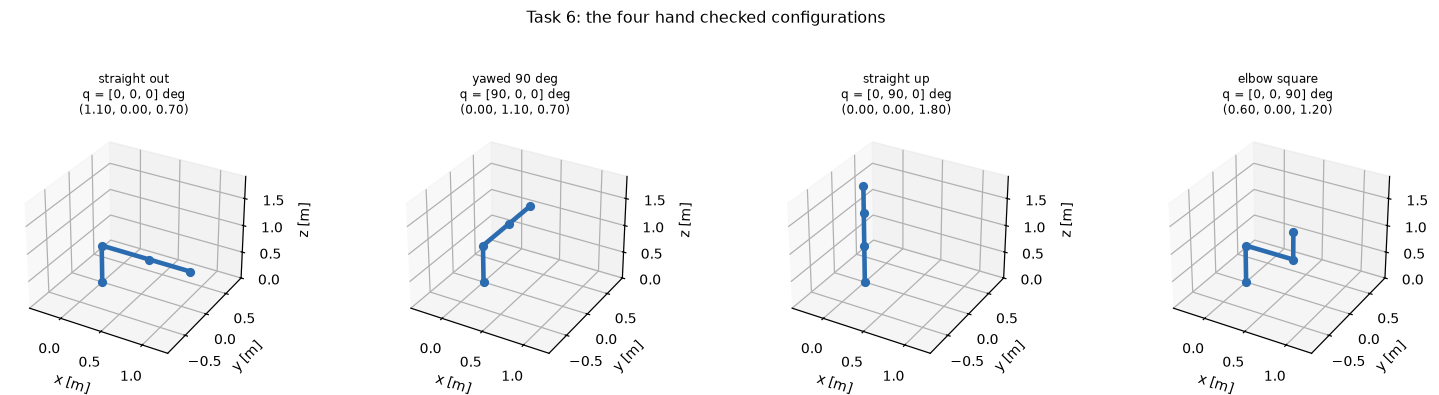

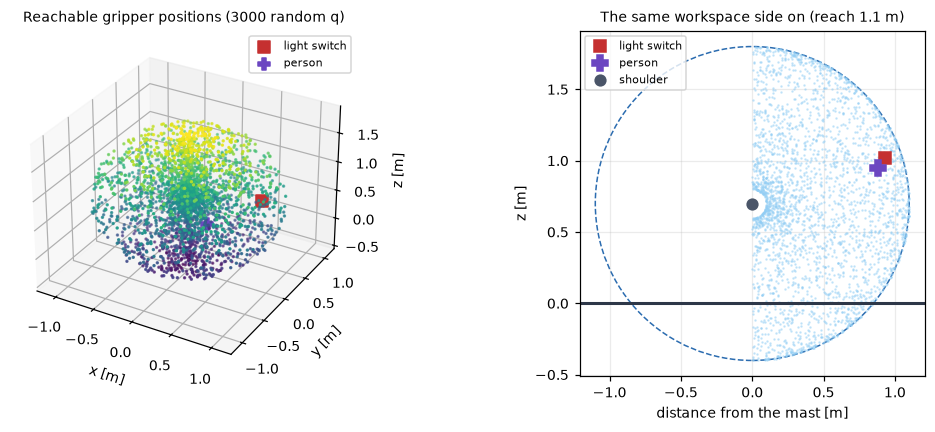

In [164]:
def plot_arm(ax, q, color="#2b6cb0", alpha=1.0, lw=3.0, label=None):
    """Draw the arm on an existing 3D axis."""
    T01 = dh_matrix(q[0], D1, 0, np.pi / 2)
    T02 = T01 @ dh_matrix(q[1], 0, L2, 0)
    T03 = fk_3dof(*q)
    pts = np.array([[0, 0, 0], T01[:3, 3], T02[:3, 3], T03[:3, 3]])
    ax.plot(pts[:, 0], pts[:, 1], pts[:, 2], "o-", color=color, lw=lw, ms=5,
            alpha=alpha, label=label)


def set_arm_axes(ax, title=""):
    ax.set_xlim(-0.4, 1.3); ax.set_ylim(-0.9, 0.9); ax.set_zlim(0, 1.9)
    ax.set_xlabel("x [m]"); ax.set_ylabel("y [m]"); ax.set_zlabel("z [m]")
    ax.set_title(title, fontsize=8)


fig = plt.figure(figsize=(14, 3.2))
for i, (name, q_deg, _) in enumerate(FK_CASES):
    ax = fig.add_subplot(1, 4, i + 1, projection="3d")
    plot_arm(ax, np.deg2rad(q_deg))
    p = position_fk(np.deg2rad(q_deg))
    set_arm_axes(ax, f"{name}\nq = {q_deg} deg\n({p[0]:.2f}, {p[1]:.2f}, {p[2]:.2f})")
fig.suptitle("Task 6: the four hand checked configurations", y=1.06, fontsize=10.5)
plt.tight_layout(); plt.show()

# Forward kinematics on random joint angles traces out the reachable workspace.
rng = make_rng(601)
samples = rng.uniform(-np.pi, np.pi, (3000, 3))
tips = np.array([position_fk(q) for q in samples])

fig = plt.figure(figsize=(10.5, 4.0))
ax1 = fig.add_subplot(1, 2, 1, projection="3d")
sc = ax1.scatter(tips[:, 0], tips[:, 1], tips[:, 2], c=tips[:, 2], s=1.5, cmap="viridis")
ax1.scatter(*SWITCH_TARGET, color="#c53030", s=60, marker="s", label="light switch")
ax1.scatter(*PERSON_TARGET, color="#6b46c1", s=60, marker="P", label="person")
ax1.set_xlabel("x [m]"); ax1.set_ylabel("y [m]"); ax1.set_zlabel("z [m]")
ax1.set_title("Reachable gripper positions (3000 random q)", fontsize=9)
ax1.legend(fontsize=7)

# A side view makes the reach limit and the floor easier to read than the 3D cloud.
ax2 = fig.add_subplot(1, 2, 2)
radial = np.hypot(tips[:, 0], tips[:, 1])
ax2.plot(radial, tips[:, 2], ".", ms=1.2, color="#90cdf4", alpha=0.5)
ax2.plot(np.hypot(*SWITCH_TARGET[:2]), SWITCH_TARGET[2], "s", color="#c53030", ms=8,
         label="light switch")
ax2.plot(np.hypot(*PERSON_TARGET[:2]), PERSON_TARGET[2], "P", color="#6b46c1", ms=10,
         label="person")
ax2.plot(0, D1, "o", color="#4a5568", ms=7, label="shoulder")
ax2.add_patch(plt.Circle((0, D1), ARM_REACH, fill=False, ec="#2b6cb0", ls="--", lw=1.0))
ax2.axhline(0, color="#2d3748", lw=2)
ax2.set_xlabel("distance from the mast [m]"); ax2.set_ylabel("z [m]")
ax2.set_title(f"The same workspace side on (reach {ARM_REACH} m)", fontsize=9)
ax2.set_aspect("equal"); ax2.legend(fontsize=7)
plt.tight_layout(); plt.show()

## 6.4 Inverse kinematics

Newton's method on the position error. The Jacobian says how the gripper moves when the joints move,
so we ask it the other way round, take that step, and repeat:

$$\Delta q = \alpha J^{+} \Delta p
\qquad\text{or, damped,}\qquad
\Delta q = \alpha \left(J^{\mathsf T} J + \lambda I\right)^{-1} J^{\mathsf T} \Delta p$$

We use the damped version by default. Near a singularity the plain pseudoinverse asks for a huge
joint change to chase a direction the arm cannot move in, and the damping refuses. Task 7 plots
that on a log axis.

### What it does when the target is out of reach

The best point it finds is as good as the geometry allows, within 0.1 mm of the nearest point of
the reach sphere. It does not **settle** there though: with no exact solution there is no fixed
point to converge to, so it wanders along the edge of the workspace and the $q$ it hands back after
200 iterations is not the best one it saw. Worth knowing before Task 11 asks this function for a
pose it cannot reach.

In [165]:
def ik_pseudoinverse(p_target, q_init, alpha=0.5, tol=1e-4, max_iter=200):
    """Iterative IK using the Jacobian pseudoinverse, dq = alpha J^+ dp.

    Returns (q, converged, error history).
    """
    q = np.asarray(q_init, dtype=float).copy()
    errors = []
    for i in range(max_iter):
        delta_p = np.asarray(p_target, dtype=float) - position_fk(q)
        err = np.linalg.norm(delta_p)
        errors.append(err)
        if err < tol:
            return q, True, errors
        q += alpha * (np.linalg.pinv(jacobian_fd(q)) @ delta_p)
    return q, False, errors


def ik_pseudoinverse_damped(p_target, q_init, alpha=0.5, tol=1e-4, max_iter=200, damping=0.01):
    """Iterative IK using damped least squares, dq = alpha (J^T J + lambda I)^-1 J^T dp.

    Same idea as the pseudoinverse but biased towards smaller steps, which is what keeps it
    stable near a singularity. Returns (q, converged, error history).
    """
    q = np.asarray(q_init, dtype=float).copy()
    errors = []
    for i in range(max_iter):
        delta_p = np.asarray(p_target, dtype=float) - position_fk(q)
        err = np.linalg.norm(delta_p)
        errors.append(err)
        if err < tol:
            return q, True, errors
        J = jacobian_fd(q)
        q += alpha * np.linalg.solve(J.T @ J + damping * np.eye(3), J.T @ delta_p)
    return q, False, errors


HOME_Q = np.deg2rad([0.0, 100.0, -120.0])      # folded in over the base, where it rides while driving
SWITCH_Q, switch_ok, switch_errs = ik_pseudoinverse_damped(SWITCH_TARGET, HOME_Q)
PERSON_Q, person_ok, _ = ik_pseudoinverse_damped(PERSON_TARGET, HOME_Q)

print(f"home configuration: q = {np.round(np.rad2deg(HOME_Q), 1)} deg, "
      f"gripper at {np.round(position_fk(HOME_Q), 3)}")
print(f"\nIK to the switch at {np.round(SWITCH_TARGET, 3)}:")
print(f"  converged : {switch_ok} in {len(switch_errs)} iterations")
print(f"  q         : {np.round(np.rad2deg(SWITCH_Q), 2)} deg")
print(f"  FK of q   : {np.round(position_fk(SWITCH_Q), 5)}")
print(f"  residual  : {switch_errs[-1]:.2e} m")
print(f"\nIK to the person at {np.round(PERSON_TARGET, 3)}: converged {person_ok} in "
      f"{len(_)} iterations, yaw q1 = {np.rad2deg(PERSON_Q[0]):.1f} deg "
      f"(the base is not square on to the person, so the arm has to twist)")

# What happens when the target is out of reach.
far = np.array([1.6, 0.0, 1.6])
far_q, far_ok, far_errs = ik_pseudoinverse_damped(far, HOME_Q)
far_limit = np.linalg.norm(far - np.array([0, 0, D1])) - ARM_REACH
print(f"\nIK to {far}, which is beyond the {ARM_REACH} m reach: converged {far_ok}")
print(f"  closest it got   : {min(far_errs):.4f} m")
print(f"  geometry says    : {far_limit:.4f} m is the best possible")
print(f"  error of the q it returned after {len(far_errs)} iterations: "
      f"{np.linalg.norm(position_fk(far_q) - far):.3f} m")
print("  ...so it finds the best reachable point but does not settle there: with no exact")
print("  solution there is no fixed point, and the last q is not the best q it saw.")

home configuration: q = [   0.  100. -120.] deg, gripper at [0.366 0.    1.12 ]

IK to the switch at [0.93 0.   1.02]:
  converged : True in 17 iterations
  q         : [ -0.    43.1  -53.47] deg
  FK of q   : [0.92992 0.      1.01998]
  residual  : 8.41e-05 m

IK to the person at [ 0.6  -0.65  0.95]: converged True in 17 iterations, yaw q1 = -47.3 deg (the base is not square on to the person, so the arm has to twist)

IK to [1.6 0.  1.6], which is beyond the 1.1 m reach: converged False
  closest it got   : 0.7358 m
  geometry says    : 0.7358 m is the best possible
  error of the q it returned after 200 iterations: 0.915 m
  ...so it finds the best reachable point but does not settle there: with no exact
  solution there is no fixed point, and the last q is not the best q it saw.


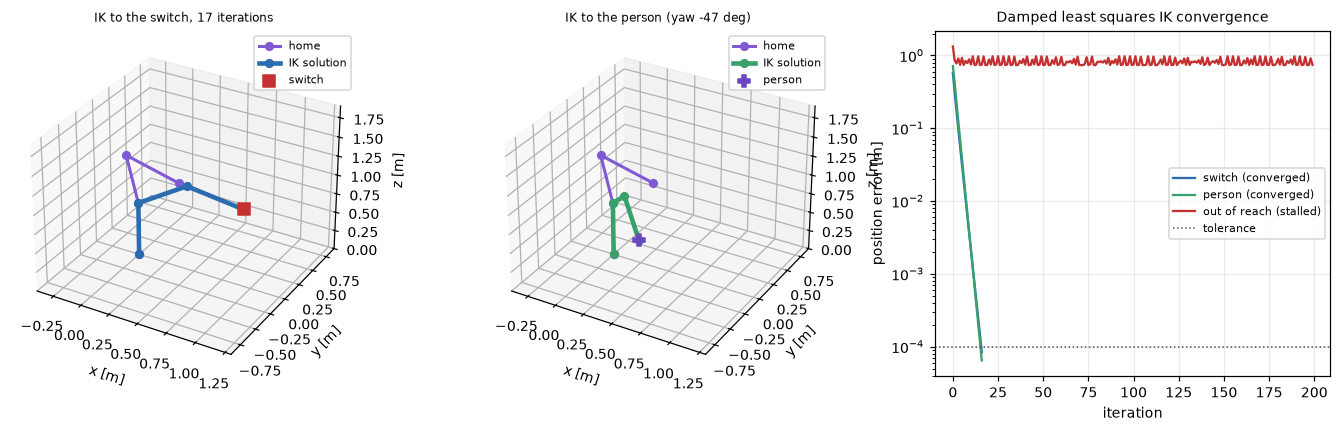

In [166]:
fig = plt.figure(figsize=(12.5, 4.0))

ax1 = fig.add_subplot(1, 3, 1, projection="3d")
plot_arm(ax1, HOME_Q, color="#805ad5", lw=2.0, label="home")
plot_arm(ax1, SWITCH_Q, color="#2b6cb0", lw=3.0, label="IK solution")
ax1.scatter(*SWITCH_TARGET, color="#c53030", s=70, marker="s", label="switch")
set_arm_axes(ax1, f"IK to the switch, {len(switch_errs)} iterations")
ax1.legend(fontsize=7)

ax2 = fig.add_subplot(1, 3, 2, projection="3d")
plot_arm(ax2, HOME_Q, color="#805ad5", lw=2.0, label="home")
plot_arm(ax2, PERSON_Q, color="#38a169", lw=3.0, label="IK solution")
ax2.scatter(*PERSON_TARGET, color="#6b46c1", s=70, marker="P", label="person")
set_arm_axes(ax2, f"IK to the person (yaw {np.rad2deg(PERSON_Q[0]):.0f} deg)")
ax2.legend(fontsize=7)

ax3 = fig.add_subplot(1, 3, 3)
for target, name, color in [(SWITCH_TARGET, "switch", "#2b6cb0"),
                            (PERSON_TARGET, "person", "#38a169"),
                            (far, "out of reach", "#c53030")]:
    _, ok, errs = ik_pseudoinverse_damped(target, HOME_Q)
    ax3.semilogy(errs, color=color, lw=1.5, label=f"{name} ({'converged' if ok else 'stalled'})")
ax3.axhline(1e-4, color="#4a5568", ls=":", lw=1, label="tolerance")
ax3.set_xlabel("iteration"); ax3.set_ylabel("position error [m]")
ax3.set_title("Damped least squares IK convergence", fontsize=9)
ax3.legend(fontsize=7)
plt.tight_layout(); plt.show()

## 6.5 Task 6 tests

We check the DH matrices are rigid first: every rotation block has to be orthonormal with
determinant $+1$, or the chain is stretching space instead of moving through it. Then the four hand
calculations.

The property tests turned out to be the more useful ones. The gripper can never be further from the
shoulder than $L_2 + L_3$, and is exactly that far when straight out. Adding an angle to $q_1$
rotates the gripper about the vertical by that angle and leaves its height alone, which is what the
"base need not be square on" claim rests on. The frame conversions undo each other.

For IK: both solvers reach both targets and agree on where the gripper ends up (they can disagree
about the joint angles, since the arm has more than one way to get there), random reachable targets
in the front upper workspace all get solved, the error falls monotonically on a solvable target, and
the unreachable target is reported as a failure while still getting as close as the geometry
allows.

In [167]:
@test("Task 6")
def test_dh_matrix_basics():
    assert close(dh_matrix(0, 0, 0, 0), np.eye(4))
    assert close(dh_matrix(0, 0.7, 0, 0)[:3, 3], [0, 0, 0.7])      # slide along z
    assert close(dh_matrix(0, 0, 0.4, 0)[:3, 3], [0.4, 0, 0])      # slide along x
    assert close(dh_matrix(np.pi / 2, 0, 0, 0)[:2, :2], [[0, -1], [1, 0]])


@test("Task 6")
def test_dh_matrices_stay_rigid():
    # The rotation block must be orthonormal with determinant +1, or the chain is stretching or
    # reflecting space rather than just moving through it.
    rng = make_rng(6001)
    for _ in range(50):
        R = dh_matrix(*rng.uniform(-1, 1, 4))[:3, :3]
        assert close(R @ R.T, np.eye(3), 1e-12) and close(np.linalg.det(R), 1.0, 1e-12)


@test("Task 6")
def test_forward_kinematics_matches_the_hand_calculations():
    for name, q_deg, expected in FK_CASES:
        assert close(position_fk(np.deg2rad(q_deg)), expected, 1e-12), name


@test("Task 6")
def test_the_gripper_never_gets_further_out_than_the_reach():
    shoulder = np.array([0, 0, D1])
    rng = make_rng(6002)
    for _ in range(300):
        assert np.linalg.norm(position_fk(rng.uniform(-np.pi, np.pi, 3)) - shoulder) \
            <= ARM_REACH + 1e-12
    # And straight out, it reaches exactly that far.
    assert close(np.linalg.norm(position_fk([0, 0, 0]) - shoulder), ARM_REACH, 1e-12)


@test("Task 6")
def test_the_first_joint_yaws_the_whole_arm():
    # Adding an angle to q1 must rotate the gripper about the vertical by that angle and leave its
    # height alone. This is the property that lets the base park off to one side.
    q = np.deg2rad([20.0, 55.0, -40.0])
    extra = np.deg2rad(35.0)
    p0, p1 = position_fk(q), position_fk(q + [extra, 0, 0])
    c, s = np.cos(extra), np.sin(extra)
    assert close(p1[:2], [c * p0[0] - s * p0[1], s * p0[0] + c * p0[1]], 1e-12)
    assert close(p1[2], p0[2], 1e-12)


@test("Task 6")
def test_the_base_and_world_frames_undo_each_other():
    rng = make_rng(6003)
    for _ in range(100):
        base = np.array([rng.uniform(1, 7), rng.uniform(1, 5), rng.uniform(-np.pi, np.pi)])
        target = np.array([rng.uniform(0, 8), rng.uniform(0, 6), rng.uniform(0, 2)])
        assert close(base_to_world(base, world_to_base(base, target)), target, 1e-12)


@test("Task 6")
def test_both_contact_targets_are_reachable_from_their_base_poses():
    for target, base in [(SWITCH_TARGET, GOAL_POSE), (PERSON_TARGET, HANDOVER_POSE)]:
        assert np.linalg.norm(target - np.array([0, 0, D1])) < ARM_REACH
        assert ROOM.is_free(base[:2], margin=ROBOT_RADIUS)


@test("Task 6")
def test_ik_reaches_both_targets():
    for target in (SWITCH_TARGET, PERSON_TARGET):
        q, ok, errs = ik_pseudoinverse_damped(target, HOME_Q)
        assert ok and errs[-1] < 1e-4
        assert close(position_fk(q), target, 1e-4)


@test("Task 6")
def test_both_ik_solvers_agree_on_a_comfortable_target():
    plain, ok_p, _ = ik_pseudoinverse(SWITCH_TARGET, HOME_Q)
    damped, ok_d, _ = ik_pseudoinverse_damped(SWITCH_TARGET, HOME_Q)
    assert ok_p and ok_d
    # They may pick different joint angles, but the gripper must end up in the same place.
    assert close(position_fk(plain), position_fk(damped), 1e-3)


@test("Task 6")
def test_ik_solves_random_reachable_targets():
    # Targets generated by running FK on random joint angles are reachable by construction. We
    # keep to the part of the workspace in front of the robot and above the floor, which is where
    # the contact tasks live.
    rng = make_rng(6004)
    checked = 0
    while checked < 20:
        target = position_fk(rng.uniform(-np.pi, np.pi, 3))
        if not (target[0] > 0.3 and target[2] > 0.3):
            continue
        q, ok, _ = ik_pseudoinverse_damped(target, HOME_Q)
        assert ok, target
        assert close(position_fk(q), target, 1e-4)
        checked += 1


@test("Task 6")
def test_ik_reports_failure_and_gets_as_close_as_the_geometry_allows():
    target = np.array([1.6, 0.0, 1.6])
    q, ok, errs = ik_pseudoinverse_damped(target, HOME_Q)
    assert not ok
    # The best it manages is the geometric limit: the nearest point of the reach sphere, which is
    # |target - shoulder| - reach away. It gets there to within a tenth of a millimetre.
    geometric_min = np.linalg.norm(target - np.array([0, 0, D1])) - ARM_REACH
    assert abs(min(errs) - geometric_min) < 0.01, (min(errs), geometric_min)
    # It does not *settle* there, though. With no exact solution there is no fixed point to
    # converge to, so the iteration wanders along the edge of the workspace and the q handed back
    # after 200 tries is not the best one it saw.
    assert np.linalg.norm(position_fk(q) - target) > min(errs)


@test("Task 6")
def test_ik_error_falls_monotonically_on_a_reachable_target():
    # Damped least squares on a solvable problem should never make things worse.
    for target in (SWITCH_TARGET, PERSON_TARGET):
        _, ok, errs = ik_pseudoinverse_damped(target, HOME_Q)
        assert ok and np.all(np.diff(errs) < 1e-12)


@test("Task 6")
def test_ik_is_deterministic():
    a, _, _ = ik_pseudoinverse_damped(SWITCH_TARGET, HOME_Q)
    b, _, _ = ik_pseudoinverse_damped(SWITCH_TARGET, HOME_Q)
    assert close(a, b, 0.0)


run_tests("Task 6")

  pass    dh matrix basics
  pass    dh matrices stay rigid
  pass    forward kinematics matches the hand calculations
  pass    the gripper never gets further out than the reach
  pass    the first joint yaws the whole arm
  pass    the base and world frames undo each other
  pass    both contact targets are reachable from their base poses
  pass    ik reaches both targets
  pass    both ik solvers agree on a comfortable target
  pass    ik solves random reachable targets
  pass    ik reports failure and gets as close as the geometry allows
  pass    ik error falls monotonically on a reachable target
  pass    ik is deterministic

13/13 tests passed (Task 6)


13

---
# Task 7: Jacobian and Velocity Control

## 7.1 The Jacobian

We take $J$ by central differences, $J_{:,i} = \frac{f(q + \varepsilon e_i) - f(q - \varepsilon e_i)}{2\varepsilon}$.
We chose that over deriving it by hand for two reasons: the error is $O(\varepsilon^2)$, about
$10^{-12}$ here, and it **cannot disagree with the forward kinematics we are actually using**. A
hand derived Jacobian with a sign error in it still gives an IK solver that converges, just more
slowly and less reliably, which would have been an unpleasant bug to track down.

We did still want an independent check, so `det_closed_form` writes the determinant out by hand.
The two agree to $10^{-7}$ over 200 random configurations.

## 7.2 Singularities and manipulability

$$\det J = -L_2 L_3 \sin q_3 \left(L_2 \cos q_2 + L_3 \cos(q_2 + q_3)\right)$$

so there are two families. **Elbow straight** ($\sin q_3 = 0$): the links line up and the gripper
cannot move along the arm. **Gripper over the mast** (the second factor zero): yawing $q_1$ moves it
nowhere, so that column of $J$ is exactly zero and a direction disappears.

Neither one mentions $q_1$, which makes sense: swinging the arm round changes which directions are
easy, not how easy they are. In terms of the matrix, a $q_1$ shift multiplies $J$ by a rotation, and
that cannot change a singular value.

**Manipulability** is the product of the singular values, which for a square $J$ is $|\det J|$. It
does *not* fall off monotonically as the elbow straightens, which surprised us until we looked at
the closed form: it is a product of $\sin q_3$, which shrinks, and the radial distance, which grows.
The two work against each other and the product peaks in the middle, then from about 60° inwards
$\sin q_3$ wins and it collapses.

In [168]:
def manipulability(q):
    """Product of the singular values of J. Zero exactly at a singularity.

    For a square J this is |det J|. It is proportional to the volume of the ellipsoid of gripper
    velocities you can get from joint rates of unit length.
    """
    return float(np.prod(np.linalg.svd(jacobian_fd(q), compute_uv=False)))


def det_closed_form(q):
    """det J worked out by hand, as an independent check on the numerical Jacobian.

        det J = -L2 L3 sin(q3) (L2 cos q2 + L3 cos(q2 + q3))

    The second factor is the gripper's distance from the mast, so both families of singularity
    can be read off it.
    """
    q1, q2, q3 = q
    radial = L2 * np.cos(q2) + L3 * np.cos(q2 + q3)
    return -L2 * L3 * np.sin(q3) * radial


print("The Jacobian at four configurations\n")
print(f"{'q [deg]':<22}{'|det J|':>10}{'manipulability':>16}{'condition number':>19}{'':>4}")
print("-" * 74)
for q_deg, note in [([0, 0, 0], "straight out"),
                    ([0, 90, 0], "straight up, over the mast"),
                    ([30, 45, -60], "a generic pose"),
                    ([0, 100, -120], "our home pose")]:
    q = np.deg2rad(q_deg)
    J = jacobian_fd(q)
    sv = np.linalg.svd(J, compute_uv=False)
    cond = np.inf if sv[-1] < 1e-12 else sv[0] / sv[-1]
    print(f"{str(q_deg):<22}{abs(np.linalg.det(J)):>10.5f}{manipulability(q):>16.5f}"
          f"{cond:>19.1f}   {note}")

print(f"\nnumerical vs closed form determinant, worst of 200 random configurations: ", end="")
rng = make_rng(701)
worst = max(abs(np.linalg.det(jacobian_fd(q)) - det_closed_form(q))
            for q in rng.uniform(-np.pi, np.pi, (200, 3)))
print(f"{worst:.2e}")

print("\nSo this arm has two families of singularity:")
print("  1. elbow straight (q3 = 0 or 180 deg): the two links line up and the gripper cannot")
print("     move along the arm any more.")
print("  2. gripper directly over the mast (L2 cos q2 + L3 cos(q2+q3) = 0): yawing the base")
print("     joint moves it nowhere, so a whole direction is lost.")
print("Neither depends on q1, which makes sense: swinging the whole arm round cannot change how")
print("freely the gripper moves, only which way it moves.")

The Jacobian at four configurations

q [deg]                  |det J|  manipulability   condition number    
--------------------------------------------------------------------------
[0, 0, 0]                0.00000         0.00000                inf   straight out
[0, 90, 0]               0.00000         0.00000                inf   straight up, over the mast
[30, 45, -60]            0.23570         0.23570                4.2   a generic pose
[0, 100, -120]           0.09500         0.09500                1.7   our home pose

numerical vs closed form determinant, worst of 200 random configurations: 1.12e-10

So this arm has two families of singularity:
  1. elbow straight (q3 = 0 or 180 deg): the two links line up and the gripper cannot
     move along the arm any more.
  2. gripper directly over the mast (L2 cos q2 + L3 cos(q2+q3) = 0): yawing the base
     joint moves it nowhere, so a whole direction is lost.
Neither depends on q1, which makes sense: swinging the whole arm round ca

## 7.3 Resolved rate control

$$\dot q = J^{+}(q)\, \dot x_d
\qquad\text{or, damped,}\qquad
\dot q = \left(J^{\mathsf T} J + \lambda I\right)^{-1} J^{\mathsf T} \dot x_d$$

The command is a constant Cartesian velocity along the straight line from the home pose to a **pre
contact pose 8 cm short of the wall**. Stopping short is on purpose: the last few centimetres are
Task 10's job, under force control, since position control is the wrong thing to be doing when you
are about to touch a wall.

The point of doing it this way is that the straight line is in *task space*. Interpolating in joint
space between the same two configurations gets to the same place, but the gripper swings along an
arc on the way, which is no good for approaching a wall or handing something to a person.

### The drift

We get 0.63 mm over a 0.49 m move. The controller is **open loop**: it integrates
$\dot q = J^{+} \dot x_d$ and never checks where the gripper actually got to, so every Euler step
leaves a little error behind. The table under the run is us checking that this is integration error
and not a bug: quartering the step quarters the drift, which is the same first order behaviour Task
1 measured for forward Euler on the base. Closing the loop would get rid of it. We left it open
because 0.6 mm does not matter when the whole point is to stop 80 mm short.

In [169]:
def resolved_rate_control(q0, xdot_d_func, T=1.0, dt=0.01):
    """Integrate q_dot = J^+(q) xdot_d forward in time. Returns (t, q, p) histories."""
    n_steps = int(T / dt)
    q = np.asarray(q0, dtype=float).copy()
    t_hist, q_hist, p_hist = [0.0], [q.copy()], [position_fk(q)]
    for k in range(n_steps):
        xdot_d = xdot_d_func(k * dt)
        J = jacobian_fd(q)
        q = q + dt * (np.linalg.pinv(J) @ xdot_d)
        t_hist.append((k + 1) * dt)
        q_hist.append(q.copy())
        p_hist.append(position_fk(q))
    return np.array(t_hist), np.array(q_hist), np.array(p_hist)


def resolved_rate_control_damped(q0, xdot_d_func, T=1.0, dt=0.01, damping=0.01):
    """As `resolved_rate_control` but with damped least squares in place of the pseudoinverse.

    Returns (t, q, p) histories.
    """
    n_steps = int(T / dt)
    q = np.asarray(q0, dtype=float).copy()
    t_hist, q_hist, p_hist = [0.0], [q.copy()], [position_fk(q)]
    for k in range(n_steps):
        xdot_d = xdot_d_func(k * dt)
        J = jacobian_fd(q)
        q = q + dt * np.linalg.solve(J.T @ J + damping * np.eye(3), J.T @ xdot_d)
        t_hist.append((k + 1) * dt)
        q_hist.append(q.copy())
        p_hist.append(position_fk(q))
    return np.array(t_hist), np.array(q_hist), np.array(p_hist)


# The approach: a straight line from the home pose to a pre contact pose 8 cm off the wall. The
# last few centimetres are Task 10's job, under force control, since position control is the
# wrong thing to be doing when you are about to touch a wall.
STANDOFF = 0.08
PRE_CONTACT = SWITCH_TARGET - np.array([STANDOFF, 0, 0])
SPEED = 0.15                                     # m/s along the straight line
DT_ARM = 0.01                                    # control step [s]

p_home = position_fk(HOME_Q)
delta = PRE_CONTACT - p_home
T_MOVE = float(np.linalg.norm(delta) / SPEED)
xdot_d = lambda t: delta / T_MOVE                # constant Cartesian velocity

t_hist, q_hist, p_hist = resolved_rate_control(HOME_Q, xdot_d, T=T_MOVE, dt=DT_ARM)
p_ideal = p_home + np.outer(t_hist, delta / T_MOVE)
drift = np.linalg.norm(p_hist - p_ideal, axis=1)
q_dot_hist = np.diff(q_hist, axis=0) / DT_ARM

print(f"straight line from {np.round(p_home, 3)} to {np.round(PRE_CONTACT, 3)}")
print(f"  distance          : {np.linalg.norm(delta):.3f} m at {SPEED} m/s, so T = {T_MOVE:.2f} s")
print(f"  final position    : {np.round(p_hist[-1], 4)}")
print(f"  ideal position    : {np.round(p_ideal[-1], 4)}")
print(f"  drift from the ideal straight line: {drift[-1] * 1000:.4f} mm (worst "
      f"{drift.max() * 1000:.4f} mm)")
print(f"  peak joint rate   : {np.abs(q_dot_hist).max():.3f} rad/s "
      f"({np.rad2deg(np.abs(q_dot_hist).max()):.1f} deg/s)")
print(f"  manipulability    : {min(manipulability(q) for q in q_hist):.4f} at worst along the way")
print(f"  condition number  : "
      f"{max(np.linalg.cond(jacobian_fd(q)) for q in q_hist):.1f} at worst along the way")

# Where the drift comes from. The controller is open loop: it integrates q_dot = J^+ xdot_d and
# never checks where the gripper actually got to, so every Euler step leaves a little behind.
# Halving the step halves the drift, so this is integration error rather than a bug.
unit = delta / np.linalg.norm(delta)
print(f"\n{'dt [s]':>8}{'sideways [mm]':>15}{'lag along the line [mm]':>25}")
print("-" * 48)
for d in (0.04, 0.02, 0.01, 0.005):
    _, _, p_d = resolved_rate_control(HOME_Q, xdot_d, T=T_MOVE, dt=d)
    rel = p_d - p_home
    sideways = np.linalg.norm(rel - np.outer(rel @ unit, unit), axis=1).max()
    lag = abs(rel[-1] @ unit - np.linalg.norm(delta))
    print(f"{d:>8}{sideways * 1000:>15.3f}{lag * 1000:>25.3f}")

straight line from [0.366 0.    1.12 ] to [0.85 0.   1.02]
  distance          : 0.495 m at 0.15 m/s, so T = 3.30 s
  final position    : [ 0.8488 -0.      1.0196]
  ideal position    : [0.849  0.     1.0202]
  drift from the ideal straight line: 0.6262 mm (worst 0.6262 mm)
  peak joint rate   : 0.409 rad/s (23.4 deg/s)
  manipulability    : 0.0950 at worst along the way
  condition number  : 3.5 at worst along the way

  dt [s]  sideways [mm]  lag along the line [mm]
------------------------------------------------
    0.04          2.482                    2.801
    0.02          1.241                    2.669
    0.01          0.622                    1.103
   0.005          0.312                    0.318


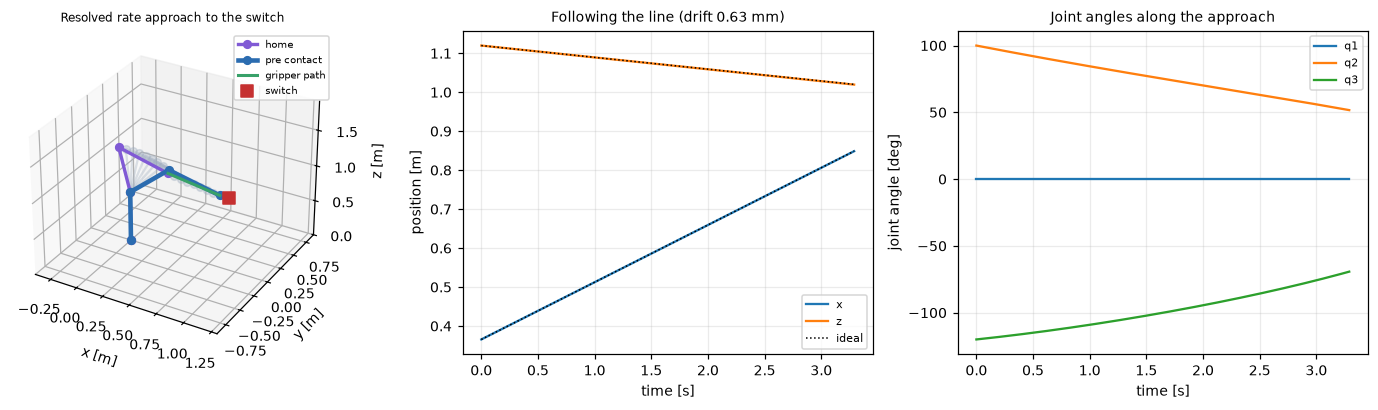

In [170]:
fig = plt.figure(figsize=(13, 3.8))

ax1 = fig.add_subplot(1, 3, 1, projection="3d")
for k in range(0, len(q_hist), max(1, len(q_hist) // 8)):
    plot_arm(ax1, q_hist[k], color="#a0aec0", alpha=0.35, lw=1.5)
plot_arm(ax1, q_hist[0], color="#805ad5", lw=2.2, label="home")
plot_arm(ax1, q_hist[-1], color="#2b6cb0", lw=3.0, label="pre contact")
ax1.plot(p_hist[:, 0], p_hist[:, 1], p_hist[:, 2], color="#38a169", lw=2.0, label="gripper path")
ax1.scatter(*SWITCH_TARGET, color="#c53030", s=60, marker="s", label="switch")
set_arm_axes(ax1, "Resolved rate approach to the switch")
ax1.legend(fontsize=6.5)

ax2 = fig.add_subplot(1, 3, 2)
ax2.plot(t_hist, p_hist[:, 0], label="x")
ax2.plot(t_hist, p_hist[:, 2], label="z")
ax2.plot(t_hist, p_ideal[:, 0], "k:", lw=1, label="ideal")
ax2.plot(t_hist, p_ideal[:, 2], "k:", lw=1)
ax2.set_xlabel("time [s]"); ax2.set_ylabel("position [m]")
ax2.set_title(f"Following the line (drift {drift.max() * 1000:.2f} mm)", fontsize=9)
ax2.legend(fontsize=7)

ax3 = fig.add_subplot(1, 3, 3)
for j in range(3):
    ax3.plot(t_hist, np.rad2deg(q_hist[:, j]), label=f"q{j + 1}")
ax3.set_xlabel("time [s]"); ax3.set_ylabel("joint angle [deg]")
ax3.set_title("Joint angles along the approach", fontsize=9)
ax3.legend(fontsize=7)
plt.tight_layout(); plt.show()

## 7.4 What actually goes wrong at a singularity

Straighten the elbow towards zero and ask the gripper to move **radially outwards**, which is
the one direction a straight arm cannot move in.

With the plain pseudoinverse the joint rates it asks for go roughly as $1/q_3$: 0.4 rad/s at a 30°
elbow, 2 rad/s at 7°, over 200 rad/s at 0.08°. On real hardware that is a violent motion, a tripped
current limit, or a broken arm. Damping stays under a quarter of a rad/s all the way down.

The middle panel is the cost, because damping is not free: the damped controller **does not deliver
the velocity it was asked for**, and near the singularity it delivers almost none of it, because
almost none of it was possible in the first place. Damping does not make an impossible motion
possible, it just makes the controller give up gracefully instead of asking for infinite speed.
Actually getting that motion would need the base to move or the arm to take a different posture,
which is a planning decision rather than a control one.

The run at the bottom is the part we did not expect. Starting 2° from the singularity, the damped
controller is not only about 1000x gentler on the joints, it also ends up **closer to where it was
aiming**: the plain version's huge joint rates fling the arm straight past the target. So near a
singularity, refusing to move fast is the accurate option as well as the safe one.

Pushing the gripper radially outwards at 0.10 m/s as the elbow straightens

  q3 [deg]   |q_dot| plain   |q_dot| damped   damped shortfall
--------------------------------------------------------------
     30.00             0.4             0.24             0.0180
      6.74             2.3             0.19             0.0608
      1.52            10.6             0.07             0.0694
      0.34            47.7             0.06             0.0705
      0.08           212.8             0.06             0.0707


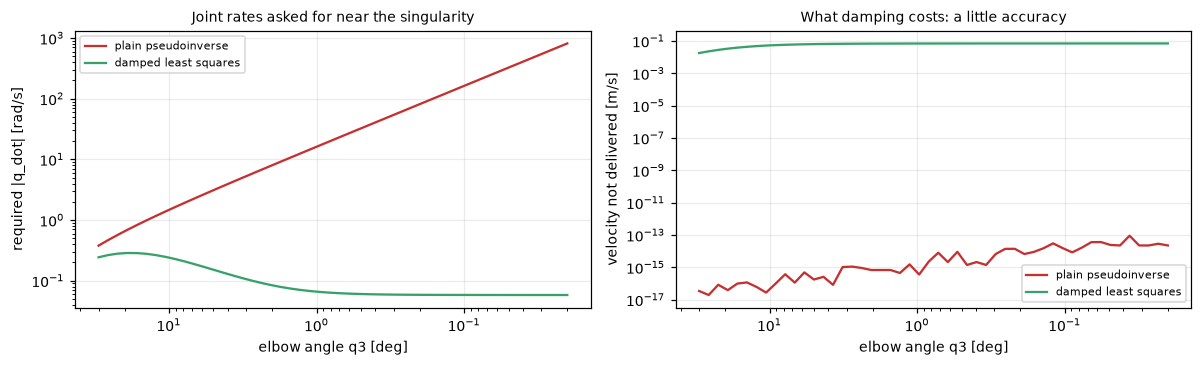


Starting 2 deg from the singularity and commanding 0.07 m/s along +x for 1 s:
  plain  : peak |q_dot|    104.3 rad/s, ended  165.0 mm from the ideal point
  damped : peak |q_dot|      0.1 rad/s, ended   51.2 mm from the ideal point


In [171]:
def joint_rates_for_radial_push(q3, damping=0.0, speed=0.10):
    """Joint rates needed to push the gripper straight out from the mast.

    Radially outwards is the one direction a straight arm cannot move in, so this is the command
    that exposes the q3 = 0 singularity. Returns (|q_dot|, velocity not delivered).
    """
    q = np.array([0.0, np.deg2rad(45.0), q3])
    p = position_fk(q)
    radial = np.array([p[0], p[1], 0.0])
    radial = radial / np.linalg.norm(radial)
    v = radial * speed

    J = jacobian_fd(q)
    if damping > 0:
        q_dot = np.linalg.solve(J.T @ J + damping * np.eye(3), J.T @ v)
    else:
        q_dot = np.linalg.pinv(J) @ v
    return float(np.linalg.norm(q_dot)), float(np.linalg.norm(J @ q_dot - v))


q3_sweep = np.deg2rad(np.logspace(np.log10(30.0), np.log10(0.02), 50))
plain = np.array([joint_rates_for_radial_push(q3) for q3 in q3_sweep])
damped = np.array([joint_rates_for_radial_push(q3, damping=0.01) for q3 in q3_sweep])

print("Pushing the gripper radially outwards at 0.10 m/s as the elbow straightens\n")
print(f"{'q3 [deg]':>10}{'|q_dot| plain':>16}{'|q_dot| damped':>17}{'damped shortfall':>19}")
print("-" * 62)
for q3, p, d in list(zip(q3_sweep, plain, damped))[::10]:
    print(f"{np.rad2deg(q3):>10.2f}{p[0]:>16.1f}{d[0]:>17.2f}{d[1]:>19.4f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
axes[0].loglog(np.rad2deg(q3_sweep), plain[:, 0], color="#c53030", label="plain pseudoinverse")
axes[0].loglog(np.rad2deg(q3_sweep), damped[:, 0], color="#38a169", label="damped least squares")
axes[0].set_xlabel("elbow angle q3 [deg]"); axes[0].set_ylabel("required |q_dot| [rad/s]")
axes[0].set_title("Joint rates asked for near the singularity", fontsize=9)
axes[0].legend(fontsize=7); axes[0].invert_xaxis()

axes[1].loglog(np.rad2deg(q3_sweep), np.maximum(plain[:, 1], 1e-18), color="#c53030",
               label="plain pseudoinverse")
axes[1].loglog(np.rad2deg(q3_sweep), np.maximum(damped[:, 1], 1e-18), color="#38a169",
               label="damped least squares")
axes[1].set_xlabel("elbow angle q3 [deg]"); axes[1].set_ylabel("velocity not delivered [m/s]")
axes[1].set_title("What damping costs: a little accuracy", fontsize=9)
axes[1].legend(fontsize=7); axes[1].invert_xaxis()
plt.tight_layout(); plt.show()

# The same commanded motion, started 2 degrees from the singularity.
q_near = np.deg2rad([0.0, 45.0, -2.0])
_, q_plain, p_plain = resolved_rate_control(q_near, lambda t: np.array([0.07, 0, 0]),
                                            T=1.0, dt=0.01)
_, q_damp, p_damp = resolved_rate_control_damped(q_near, lambda t: np.array([0.07, 0, 0]),
                                                 T=1.0, dt=0.01)
print(f"\nStarting 2 deg from the singularity and commanding 0.07 m/s along +x for 1 s:")
for name, qh, ph in [("plain", q_plain, p_plain), ("damped", q_damp, p_damp)]:
    rates = np.linalg.norm(np.diff(qh, axis=0) / 0.01, axis=1)
    ideal = position_fk(q_near) + np.array([0.07, 0, 0])
    print(f"  {name:<7}: peak |q_dot| {rates.max():>8.1f} rad/s, "
          f"ended {np.linalg.norm(ph[-1] - ideal) * 1000:6.1f} mm from the ideal point")

## 7.5 Task 7 tests

We check the Jacobian three ways: against its defining property (for small $\Delta q$ the gripper
moves by $J \Delta q$), against two column lengths we can work out exactly (turning only $q_3$
swings the gripper on a circle of radius $L_3$, so that column has length exactly $L_3$, and
likewise $q_1$ and the radial distance), and against the closed form determinant.

The singularity tests assert what 7.2 claims: a straight elbow gives rank 2 and zero
manipulability, the gripper over the mast gives an exactly zero first column, a $q_1$ shift leaves
every singular value alone, and the contact configuration is well clear of all of it (condition
number 4.8, elbow at 53°, never worse than 3.5 along the approach).

For the controller: it arrives within 2 mm, never goes more than 1 mm sideways off the line
(measured perpendicular, since lagging behind it is still straight), the drift shrinks with the step
the way first order error should, the approach really does stop 8 cm short, and damping keeps the
joint rates finite where the pseudoinverse does not.

In [172]:
@test("Task 7")
def test_the_jacobian_predicts_where_a_small_joint_move_goes():
    # The defining property: for a small dq the gripper moves by J dq.
    rng = make_rng(7001)
    for _ in range(50):
        q = rng.uniform(-2, 2, 3)
        dq = rng.normal(0, 1, 3) * 1e-7
        assert close(jacobian_fd(q) @ dq, position_fk(q + dq) - position_fk(q), 1e-11)


@test("Task 7")
def test_the_last_joint_moves_the_gripper_by_its_own_link_length():
    # Turning only q3 swings the gripper on a circle of radius L3, so that column of J must have
    # length exactly L3. Same for the whole arm about q1, at its radial distance.
    rng = make_rng(7002)
    for _ in range(20):
        q = rng.uniform(-np.pi, np.pi, 3)
        J = jacobian_fd(q)
        assert close(np.linalg.norm(J[:, 2]), L3, 1e-6)
        radial = np.hypot(*position_fk(q)[:2])
        assert close(np.linalg.norm(J[:, 0]), radial, 1e-6)


@test("Task 7")
def test_the_determinant_matches_the_closed_form():
    rng = make_rng(7003)
    for q in rng.uniform(-np.pi, np.pi, (200, 3)):
        assert close(np.linalg.det(jacobian_fd(q)), det_closed_form(q), 1e-7)


@test("Task 7")
def test_a_straight_elbow_is_singular():
    for q3 in (0.0, np.pi, -np.pi):
        q = np.array([0.3, 0.7, q3])
        assert abs(np.linalg.det(jacobian_fd(q))) < 1e-9
        assert np.linalg.matrix_rank(jacobian_fd(q), tol=1e-7) == 2
        assert manipulability(q) < 1e-9


@test("Task 7")
def test_the_gripper_over_the_mast_is_singular():
    # Straight up: yawing q1 does not move the gripper at all, so that column of J is zero.
    q = np.array([0.4, np.pi / 2, 0.0])
    J = jacobian_fd(q)
    assert close(J[:, 0], 0.0, 1e-9)
    assert manipulability(q) < 1e-9


@test("Task 7")
def test_a_generic_configuration_is_not_singular():
    q = np.deg2rad([30.0, 45.0, -60.0])
    assert np.linalg.matrix_rank(jacobian_fd(q)) == 3
    assert manipulability(q) > 0.05
    assert np.linalg.cond(jacobian_fd(q)) < 10


@test("Task 7")
def test_yaw_does_not_change_how_well_conditioned_the_arm_is():
    # Changing q1 rotates the whole arm, which multiplies J by a rotation, so the singular values
    # cannot move.
    q = np.array([0.3, 0.9, -0.7])
    sv = lambda qq: np.linalg.svd(jacobian_fd(qq), compute_uv=False)
    assert close(sv(q), sv(q + [1.4, 0, 0]), 1e-6)


@test("Task 7")
def test_manipulability_falls_as_the_elbow_straightens():
    # Only over part of the range. det J = -L2 L3 sin(q3) * radial, and straightening the elbow
    # raises the radial distance while lowering sin(q3), so the product peaks in the middle rather
    # than falling everywhere. From 60 degrees inwards, sin(q3) wins and it falls to zero.
    values = [manipulability(np.array([0.0, np.deg2rad(45.0), q3]))
              for q3 in np.deg2rad([-60, -30, -10, -2])]
    assert np.all(np.diff(values) < 0), values
    assert values[-1] < 0.01
    # Near the fully folded end it is not monotonic, which is the closed form's doing, not a bug.
    assert manipulability(np.array([0.0, np.deg2rad(45.0), np.deg2rad(-90)])) \
        < manipulability(np.array([0.0, np.deg2rad(45.0), np.deg2rad(-60)]))


@test("Task 7")
def test_the_contact_configuration_is_well_clear_of_a_singularity():
    # The arm has to be controllable exactly where the contact task happens.
    assert manipulability(SWITCH_Q) > 0.05, manipulability(SWITCH_Q)
    assert np.linalg.cond(jacobian_fd(SWITCH_Q)) < 10
    assert abs(np.rad2deg(SWITCH_Q[2])) > 20


@test("Task 7")
def test_resolved_rate_control_arrives_and_goes_in_a_straight_line():
    # A couple of millimetres, not microns: the controller is open loop, so each step leaves a
    # little error behind and they add up. Closing the loop would remove it.
    assert np.linalg.norm(p_hist[-1] - PRE_CONTACT) < 2e-3
    assert drift.max() < 2e-3, drift.max()
    # Straightness measured perpendicular to the line, since lagging along it is still straight.
    offsets = (p_hist - p_home) - np.outer((p_hist - p_home) @ unit, unit)
    assert np.linalg.norm(offsets, axis=1).max() < 1e-3


@test("Task 7")
def test_the_drift_is_integration_error_and_halves_with_the_step():
    def sideways_and_lag(dt):
        _, _, p_d = resolved_rate_control(HOME_Q, xdot_d, T=T_MOVE, dt=dt)
        rel = p_d - p_home
        return (np.linalg.norm(rel - np.outer(rel @ unit, unit), axis=1).max(),
                abs(rel[-1] @ unit - np.linalg.norm(delta)))
    coarse, fine = sideways_and_lag(0.04), sideways_and_lag(0.01)
    # Four times the step should give roughly four times the error, so at least three times.
    assert coarse[0] > 3 * fine[0], (coarse, fine)


@test("Task 7")
def test_the_approach_stops_short_of_the_wall():
    # The gap is what leaves Task 10 something to do.
    assert abs((SWITCH_TARGET[0] - p_hist[-1][0]) - STANDOFF) < 2e-3


@test("Task 7")
def test_the_joint_rates_stay_sensible_along_the_approach():
    assert np.abs(q_dot_hist).max() < np.deg2rad(120), np.abs(q_dot_hist).max()


@test("Task 7")
def test_damping_keeps_the_joint_rates_finite_where_the_pseudoinverse_does_not():
    tiny = np.deg2rad(0.05)
    plain_rate, _ = joint_rates_for_radial_push(tiny)
    damped_rate, shortfall = joint_rates_for_radial_push(tiny, damping=0.01)
    assert plain_rate > 50, plain_rate            # the pseudoinverse asks for the impossible
    assert damped_rate < 5, damped_rate           # damping refuses
    assert shortfall > 0                          # and that refusal costs delivered speed


@test("Task 7")
def test_resolved_rate_control_is_deterministic():
    _, a, _ = resolved_rate_control(HOME_Q, xdot_d, T=0.5, dt=DT_ARM)
    _, b, _ = resolved_rate_control(HOME_Q, xdot_d, T=0.5, dt=DT_ARM)
    assert close(a, b, 0.0)


run_tests("Task 7")

  pass    the jacobian predicts where a small joint move goes
  pass    the last joint moves the gripper by its own link length
  pass    the determinant matches the closed form
  pass    a straight elbow is singular
  pass    the gripper over the mast is singular
  pass    a generic configuration is not singular
  pass    yaw does not change how well conditioned the arm is
  pass    manipulability falls as the elbow straightens
  pass    the contact configuration is well clear of a singularity
  pass    resolved rate control arrives and goes in a straight line
  pass    the drift is integration error and halves with the step
  pass    the approach stops short of the wall
  pass    the joint rates stay sensible along the approach
  pass    damping keeps the joint rates finite where the pseudoinverse does not
  pass    resolved rate control is deterministic

15/15 tests passed (Task 7)


15

---
# Task 8: Dynamics and Joint Control

Tasks 6 and 7 moved the arm by kinematics: we said where the joints should be and they were there.
Holding this arm straight out with its payload takes 25 N m at the elbow before it moves at all, so
Task 8 puts the physics in and then puts controllers round it that have to live with the physics.

## 8.1 The model

$$\tau = M(q)\,\ddot q + C(q, \dot q)\,\dot q + g(q)$$

Everything here is that equation solved for $\tau$, which is a controller working out what to ask
for, or for $\ddot q$, which is the simulated arm working out what happens next.

All three come from Task 6's forward kinematics, for the reason Task 7 gave for the Jacobian: a
hand derivation with a sign error still gives a controller that mostly works. Each moving mass gets
a position Jacobian $J_i$ by central differences, and then

$$M(q) = I_\text{rotor} + \sum_i m_i J_i^{\mathsf T} J_i,
\qquad
g(q) = \frac{\partial U}{\partial q} = \sum_i m_i\, g\, J_{i,z},
\qquad
U(q) = \sum_i m_i\, g\, z_i(q)$$

both exact for point masses. $C$ comes from the Christoffel symbols of the first kind,

$$C_{ij} = \sum_k \frac{1}{2}\left(
\frac{\partial M_{ij}}{\partial q_k} + \frac{\partial M_{ik}}{\partial q_j}
- \frac{\partial M_{jk}}{\partial q_i}\right) \dot q_k$$

which needs $\partial M / \partial q$, again by central differences. Of the many $C$ with the right
$C\dot q$, this is the one that also makes $\dot M - 2C$ skew symmetric, which 8.2 leans on.

| | |
|---|---|
| link 2 | 2.5 kg, uniform along its 0.60 m |
| link 3 | 1.5 kg, uniform along its 0.50 m |
| payload | 0.5 kg at the gripper |
| joints | 0.05, 0.02, 0.01 kg m² of rotor and mast inertia |
| torque limits | 40, 60, 20 N m |

Treating a rod as a point mass at its centre would understate the elbow's inertia by a third. Two
masses of $m/2$ at $L/2\sqrt{3}$ either side of the centre have the same mass, centre and second
moment as the rod, exactly, so each link is two point masses and the arm is five. The rotor inertia
keeps $M$ invertible where the arm stands straight up and every mass sits on the yaw axis, which is
Task 7's singularity from the other side.

**Left out:** joint friction, motor dynamics, link flexibility. Friction would both damp 8.2 and
add a term 8.3 has to fight.

In [ ]:
G_ACCEL = 9.81                                 
M_LINK2, M_LINK3, M_PAYLOAD = 2.5, 1.5, 0.5     
ROTOR_I = np.array([0.05, 0.02, 0.01])          
TAU_MAX = np.array([40.0, 60.0, 20.0])         


ROD_HALF = 1.0 / (2 * np.sqrt(3))
LINK2_AT = L2 * np.array([0.5 - ROD_HALF, 0.5 + ROD_HALF])   
LINK3_AT = L3 * np.array([0.5 - ROD_HALF, 0.5 + ROD_HALF])  


def arm_masses(payload=M_PAYLOAD):
    """The five point masses: two per link, plus whatever is in the gripper."""
    return np.array([M_LINK2 / 2, M_LINK2 / 2, M_LINK3 / 2, M_LINK3 / 2, payload])


MASSES = arm_masses()


def mass_points(q):
    """Positions of the five point masses in the base frame. Returns a (5, 3) array.

    Written out in closed form rather than as DH products because it sits inside every dynamics
    call and gets evaluated a few hundred thousand times a run. The Task 8 tests check it against
    the DH chain and against `position_fk`.
    """
    q1, q2, q3 = q
    c1, s1 = np.cos(q1), np.sin(q1)
    c2, s2 = np.cos(q2), np.sin(q2)
    c23, s23 = np.cos(q2 + q3), np.sin(q2 + q3)
    r_elbow, z_elbow = L2 * c2, D1 + L2 * s2
    radial = np.concatenate([LINK2_AT * c2, r_elbow + LINK3_AT * c23, [r_elbow + L3 * c23]])
    height = np.concatenate([D1 + LINK2_AT * s2, z_elbow + LINK3_AT * s23, [z_elbow + L3 * s23]])
    return np.stack([radial * c1, radial * s1, height], axis=1)


def mass_jacobians(q, eps=1e-6):
    """Position Jacobian of every point mass, by central differences. Returns (5, 3, 3)."""
    J = np.zeros((5, 3, 3))
    for j in range(3):
        dq = np.zeros(3)
        dq[j] = eps
        J[:, :, j] = (mass_points(q + dq) - mass_points(q - dq)) / (2 * eps)
    return J


def mass_matrix(q, masses=MASSES):
    """M(q), from the kinetic energy of the point masses plus the rotor inertia."""
    M = np.diag(ROTOR_I).astype(float)
    for m, J in zip(masses, mass_jacobians(q)):
        M += m * (J.T @ J)
    return M


def gravity_torque(q, masses=MASSES):
    """g(q) = dU/dq: the torque each joint must hold just to stop the arm falling."""
    return sum(m * G_ACCEL * J[2, :] for m, J in zip(masses, mass_jacobians(q)))


def potential_energy(q, masses=MASSES):
    return float(np.sum(np.asarray(masses) * G_ACCEL * mass_points(q)[:, 2]))


def kinetic_energy(q, qdot, masses=MASSES):
    return float(0.5 * qdot @ mass_matrix(q, masses) @ qdot)


def dmass_dq(q, masses=MASSES, eps=1e-5):
    """dM/dq_k for each k, by central differences. Returns (3, 3, 3), indexed [k, i, j]."""
    out = np.zeros((3, 3, 3))
    for k in range(3):
        dq = np.zeros(3)
        dq[k] = eps
        out[k] = (mass_matrix(q + dq, masses) - mass_matrix(q - dq, masses)) / (2 * eps)
    return out


def coriolis_matrix(q, qdot, masses=MASSES):
    """C(q, qdot) from the Christoffel symbols of the first kind.

    Any C with C qdot equal to the true centrifugal and Coriolis vector would move the arm
    correctly. This one is the choice that also makes Mdot - 2C skew symmetric, which is the
    property the energy argument (and every Lyapunov proof of these controllers) leans on.
    """
    dM = dmass_dq(q, masses)
    C = np.zeros((3, 3))
    for i in range(3):
        for j in range(3):
            C[i, j] = 0.5 * sum((dM[k][i, j] + dM[j][i, k] - dM[i][j, k]) * qdot[k]
                                for k in range(3))
    return C


def inverse_dynamics(q, qdot, qddot, masses=MASSES):
    """The torque needed to produce a wanted acceleration. Task 8's controllers are built on it."""
    return (mass_matrix(q, masses) @ qddot + coriolis_matrix(q, qdot, masses) @ qdot
            + gravity_torque(q, masses))


def forward_dynamics(q, qdot, tau, masses=MASSES):
    """The acceleration a torque produces. This is the simulated arm itself."""
    velocity_and_gravity = coriolis_matrix(q, qdot, masses) @ qdot + gravity_torque(q, masses)
    return np.linalg.solve(mass_matrix(q, masses), tau - velocity_and_gravity)


print("Mass matrix at the home pose")
print(np.round(mass_matrix(HOME_Q), 4))
print(f"  eigenvalues {np.round(np.linalg.eigvalsh(mass_matrix(HOME_Q)), 4)}, "
      f"symmetric to {np.abs(mass_matrix(HOME_Q) - mass_matrix(HOME_Q).T).max():.1e}")
print("\nStraight up, where every mass sits on the yaw axis and only the rotors resist q1:")
print(f"  eigenvalues {np.round(np.linalg.eigvalsh(mass_matrix(np.deg2rad([0, 90, 0]))), 4)} "
      f"(M[0,0] = {mass_matrix(np.deg2rad([0, 90, 0]))[0, 0]:.3f}, which is ROTOR_I[0] exactly)")

print(f"\n{'configuration':<24}{'q [deg]':<16}{'gravity torque [N m]':>30}{'by hand':>30}")
print("-" * 100)

GRAVITY_CASES = [
    ("straight out", [0, 0, 0], [0.0,
                                 G_ACCEL * (M_LINK2 * L2 / 2 + M_LINK3 * (L2 + L3 / 2)
                                            + M_PAYLOAD * (L2 + L3)),
                                 G_ACCEL * (M_LINK3 * L3 / 2 + M_PAYLOAD * L3)]),
    ("straight up", [0, 90, 0], [0.0, 0.0, 0.0]),
    ("elbow square", [0, 0, 90], [0.0,
                                  G_ACCEL * L2 * (M_LINK2 / 2 + M_LINK3 + M_PAYLOAD),
                                  0.0]),
    ("yawed 40 deg", [40, 0, 0], [0.0,
                                  G_ACCEL * (M_LINK2 * L2 / 2 + M_LINK3 * (L2 + L3 / 2)
                                             + M_PAYLOAD * (L2 + L3)),
                                  G_ACCEL * (M_LINK3 * L3 / 2 + M_PAYLOAD * L3)]),
]
for name, q_deg, expect in GRAVITY_CASES:
    got = gravity_torque(np.deg2rad(q_deg))
    print(f"{name:<24}{str(q_deg):<16}{str(np.round(got, 3)):>30}{str(np.round(expect, 3)):>30}")
print("\nYawing the arm round changes nothing in that table, which is the point of the last row:")
print("gravity does not care which way the arm is pointing, only how far out it is holding mass.")

Mass matrix at the home pose
[[0.1791 0.     0.    ]
 [0.     0.915  0.0625]
 [0.     0.0625 0.26  ]]
  eigenvalues [0.1791 0.2541 0.9209], symmetric to 0.0e+00

Straight up, where every mass sits on the yaw axis and only the rotors resist q1:
  eigenvalues [0.05   0.0625 2.2375] (M[0,0] = 0.050, which is ROTOR_I[0] exactly)

configuration           q [deg]                   gravity torque [N m]                       by hand
----------------------------------------------------------------------------------------------------
straight out            [0, 0, 0]               [ 0.    25.261  6.131]        [ 0.    25.261  6.131]
straight up             [0, 90, 0]                          [0. 0. 0.]                    [0. 0. 0.]
elbow square            [0, 0, 90]                 [ 0.   19.13  0.  ]           [ 0.   19.13  0.  ]
yawed 40 deg            [40, 0, 0]              [ 0.    25.261  6.131]        [ 0.    25.261  6.131]

Yawing the arm round changes nothing in that table, which is the 

## 8.2 The model with no controller on it

Take the controller away and the arm should fall, swing, and keep swinging: nothing in the model
dissipates anything, so the total energy has to stay where it started. It does, to two parts in a
million. That is a stronger check than it looks, because a Coriolis term with a sign error still
gives a motion that looks like an arm falling; what it cannot do is conserve energy while falling.

The drop also walks the arm through its own mast and the floor, since nothing checks for that. And
690 deg/s at the elbow is what losing power looks like on an arm working next to a person, which is
why nothing in Task 11 runs open loop.

Motors off from straight out, so the only thing acting is the model itself
  peak joint speed  : 12.1 rad/s (692 deg/s) at the elbow
  yaw joint q1      : moved 0.0e+00 deg, because gravity has no moment about a vertical axis
  total energy      : 30.9015 J to 30.9014 J, worst wander 5.80e-05 J (1.9e-06 of it)
  inverse then forward dynamics returns the acceleration it was given, worst of 40 random
  states: 1.3e-14 rad/s^2. Mdot - 2C skew symmetric to 4.4e-16.


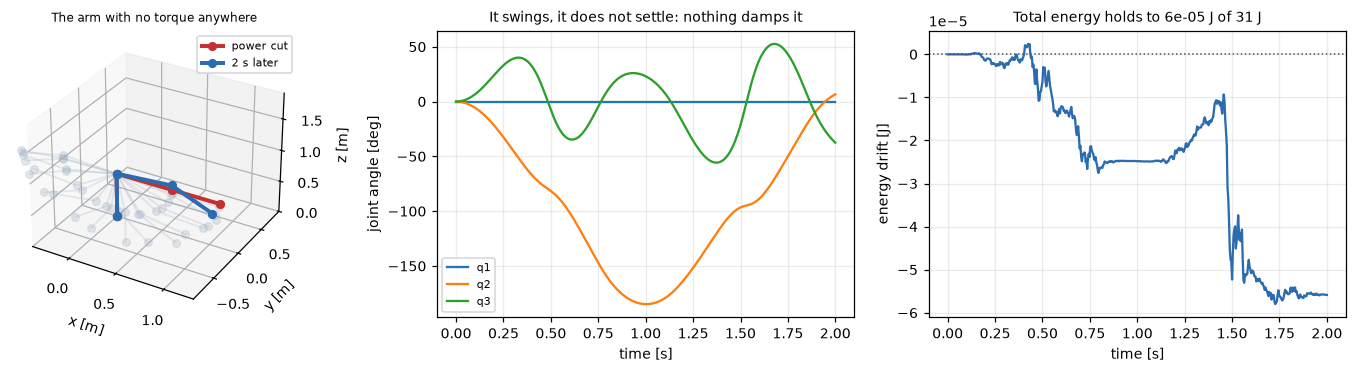

In [ ]:
DT_CTRL = 0.004   


def simulate_arm(controller, reference, T, q0=None, qdot0=None, dt=DT_CTRL,
                 plant_masses=MASSES, model_masses=None, tau_max=TAU_MAX):
    """Run the arm under a controller. Returns a log dict of t, q, qdot, tau and error.

    The torque is worked out once per control step and then held while the plant integrates
    through it with RK4, which is what a real digital controller does. `plant_masses` is the arm
    that exists and `model_masses` is the arm the controller believes in; 8.4 makes them differ.
    """
    model_masses = plant_masses if model_masses is None else model_masses
    q = np.asarray(reference(0.0)[0] if q0 is None else q0, dtype=float).copy()
    qdot = np.zeros(3) if qdot0 is None else np.asarray(qdot0, dtype=float).copy()
    memory = {"dt": dt}                      # anywhere a controller needs to remember something
    ts, qs, vs, taus = [0.0], [q.copy()], [qdot.copy()], []

    for k in range(int(round(T / dt))):
        tau = np.clip(controller(k * dt, q, qdot, reference, memory, model_masses),
                      -tau_max, tau_max)

        def deriv(state):
            return np.concatenate([state[3:],
                                   forward_dynamics(state[:3], state[3:], tau, plant_masses)])

        state = np.concatenate([q, qdot])
        k1 = deriv(state)
        k2 = deriv(state + dt / 2 * k1)
        k3 = deriv(state + dt / 2 * k2)
        k4 = deriv(state + dt * k3)
        state = state + dt / 6 * (k1 + 2 * k2 + 2 * k3 + k4)
        q, qdot = state[:3], state[3:]
        ts.append((k + 1) * dt)
        qs.append(q.copy())
        vs.append(qdot.copy())
        taus.append(tau)

    ts, qs, vs = np.array(ts), np.array(qs), np.array(vs)
    q_ref = np.array([reference(t)[0] for t in ts])
    return {"t": ts, "q": qs, "qdot": vs, "tau": np.array(taus), "q_ref": q_ref,
            "err": qs - q_ref}


motors_off = lambda t, q, qdot, ref, memory, masses: np.zeros(3)
hold = lambda q0: (lambda t: (np.asarray(q0, dtype=float), np.zeros(3), np.zeros(3)))

DROP_Q = np.zeros(3)                     # straight out, the worst pose to lose power in
DROP = simulate_arm(motors_off, hold(DROP_Q), T=2.0, q0=DROP_Q)
energy = np.array([kinetic_energy(q, v) + potential_energy(q)
                   for q, v in zip(DROP["q"], DROP["qdot"])])

print("Motors off from straight out, so the only thing acting is the model itself")
print(f"  peak joint speed  : {np.abs(DROP['qdot']).max():.1f} rad/s "
      f"({np.rad2deg(np.abs(DROP['qdot']).max()):.0f} deg/s) at the elbow")
print(f"  yaw joint q1      : moved {np.rad2deg(np.abs(DROP['q'][:, 0]).max()):.1e} deg, "
      f"because gravity has no moment about a vertical axis")
print(f"  total energy      : {energy[0]:.4f} J to {energy[-1]:.4f} J, "
      f"worst wander {np.abs(energy - energy[0]).max():.2e} J "
      f"({np.abs(energy - energy[0]).max() / abs(energy[0]):.1e} of it)")


rng = make_rng(801)
worst_round_trip, worst_skew = 0.0, 0.0
for _ in range(40):
    q, qdot, qddot = rng.uniform(-2, 2, 3), rng.uniform(-2, 2, 3), rng.uniform(-5, 5, 3)
    worst_round_trip = max(worst_round_trip,
                           np.abs(forward_dynamics(q, qdot, inverse_dynamics(q, qdot, qddot))
                                  - qddot).max())
    Mdot = sum(dmass_dq(q)[k] * qdot[k] for k in range(3))
    S = Mdot - 2 * coriolis_matrix(q, qdot)
    worst_skew = max(worst_skew, np.abs(S + S.T).max())
print(f"  inverse then forward dynamics returns the acceleration it was given, worst of 40 random")
print(f"  states: {worst_round_trip:.1e} rad/s^2. Mdot - 2C skew symmetric to {worst_skew:.1e}.")

fig = plt.figure(figsize=(13, 3.6))

ax1 = fig.add_subplot(1, 3, 1, projection="3d")
for k in range(0, len(DROP["q"]), 25):
    shade = 0.15 + 0.85 * k / len(DROP["q"])
    plot_arm(ax1, DROP["q"][k], color="#a0aec0", alpha=0.25, lw=1.2)
plot_arm(ax1, DROP["q"][0], color="#c53030", lw=2.6, label="power cut")
plot_arm(ax1, DROP["q"][-1], color="#2b6cb0", lw=2.6, label="2 s later")
set_arm_axes(ax1, "The arm with no torque anywhere")
ax1.legend(fontsize=7)

ax2 = fig.add_subplot(1, 3, 2)
for j in range(3):
    ax2.plot(DROP["t"], np.rad2deg(DROP["q"][:, j]), label=f"q{j + 1}")
ax2.set_xlabel("time [s]"); ax2.set_ylabel("joint angle [deg]")
ax2.set_title("It swings, it does not settle: nothing damps it", fontsize=9)
ax2.legend(fontsize=7)

ax3 = fig.add_subplot(1, 3, 3)
ax3.plot(DROP["t"], energy - energy[0], color="#2b6cb0", lw=1.5)
ax3.axhline(0, color="#4a5568", ls=":", lw=1)
ax3.set_xlabel("time [s]"); ax3.set_ylabel("energy drift [J]")
ax3.set_title(f"Total energy holds to {np.abs(energy - energy[0]).max():.0e} J of "
              f"{energy[0]:.0f} J", fontsize=9)
plt.tight_layout(); plt.show()

## 8.3 Four controllers

All four follow the same commanded trajectory: every joint swings out and back, then holds still.
The hold is deliberate, since steady state is where these controllers differ most plainly.

$$\begin{aligned}
\textbf{PD} &: \tau = K_P e + K_D \dot e \\
\textbf{PD + gravity} &: \tau = K_P e + K_D \dot e + g(q) \\
\textbf{PID} &: \tau = K_P e + K_D \dot e + K_I \textstyle\int e \\
\textbf{computed torque} &: \tau = M(q)\big[\ddot q_d + K_D \dot e + K_P e\big]
+ C(q,\dot q)\dot q + g(q)
\end{aligned}$$

with $e = q_d - q$. The first three treat the arm as three independent springs; the fourth cancels
the dynamics first, leaving $\ddot e + K_D \dot e + K_P e = 0$ at every configuration, which is why
its gains are single numbers rather than one per joint.

The fixed gains are sized against the inertia the arm has at the home pose, $K_P = \omega^2
\operatorname{diag} M$ and $K_D = 2\omega \operatorname{diag} M$ at $\omega = 12$ rad/s and critical
damping, so the comparison is between structures and not between someone's tuning. Computed torque
gets the same 12 rad/s. Torque is computed once per control step at 250 Hz and held, as a digital
controller really does.

Plain PD never stops being wrong: at rest it is a spring holding exactly the error that makes
$K_P e$ carry the gravity torque, which is 8.2° at the elbow and several centimetres at the gripper.
One term, $g(q)$, removes it. PID reaches the same place by integrating instead of being told, and
pays for it by being the worst of the four while moving, since the integral term always works from
error that has already happened. It also has the least margin: above about $8 K_P$ the arm goes
unstable. Computed torque is two to three orders of magnitude better than any of them, because it
works out what the arm is about to need instead of responding to error.

In [ ]:

WAVE_AMP = np.deg2rad([25.0, 20.0, 30.0])
WAVE_HZ = 0.6
WAVE_W = 2 * np.pi * WAVE_HZ
T_WAVE = 1 / WAVE_HZ
T_HOLD = 1.2


def wave_reference(t):
    """(q_d, qdot_d, qddot_d) at time t. Smooth, and exactly differentiable, so no controller is
    handicapped by a numerically differentiated acceleration."""
    if t >= T_WAVE:
        return HOME_Q + WAVE_AMP * (1 - np.cos(WAVE_W * T_WAVE)), np.zeros(3), np.zeros(3)
    return (HOME_Q + WAVE_AMP * (1 - np.cos(WAVE_W * t)),
            WAVE_AMP * WAVE_W * np.sin(WAVE_W * t),
            WAVE_AMP * WAVE_W**2 * np.cos(WAVE_W * t))



W_N = 12.0
KP = np.round(W_N**2 * np.diag(mass_matrix(HOME_Q)), 1)
KD = np.round(2 * W_N * np.diag(mass_matrix(HOME_Q)), 1)
KI = 5 * KP
I_LIMIT = 0.5                    

KP_CT, KD_CT = W_N**2, 2 * W_N


def pd_control(t, q, qdot, reference, memory, masses):
    q_d, qdot_d, _ = reference(t)
    return KP * (q_d - q) + KD * (qdot_d - qdot)


def pd_gravity_control(t, q, qdot, reference, memory, masses):
    """PD with the gravity model added as a feedforward. One term, and the droop goes."""
    return pd_control(t, q, qdot, reference, memory, masses) + gravity_torque(q, masses)


def pid_control(t, q, qdot, reference, memory, masses):
    """PD plus an integral term, which learns the gravity torque instead of being told it."""
    q_d, qdot_d, _ = reference(t)
    error = q_d - q
    memory["I"] = np.clip(memory.get("I", np.zeros(3)) + error * memory["dt"], -I_LIMIT, I_LIMIT)
    return KP * error + KD * (qdot_d - qdot) + KI * memory["I"]


def computed_torque_control(t, q, qdot, reference, memory, masses):
    """Inverse dynamics control: ask for an acceleration, then use the model to pay for it.

    tau = M(q) [qddot_d + KD e_dot + KP e] + C qdot + g. If the model were perfect the error
    would obey e_ddot + KD e_dot + KP e = 0 at every configuration, which is why one pair of
    gains works everywhere instead of being a compromise across poses.
    """
    q_d, qdot_d, qddot_d = reference(t)
    a = qddot_d + KD_CT * (qdot_d - qdot) + KP_CT * (q_d - q)
    return (mass_matrix(q, masses) @ a + coriolis_matrix(q, qdot, masses) @ qdot
            + gravity_torque(q, masses))


CONTROLLERS = [("PD", pd_control), ("PD + gravity", pd_gravity_control),
               ("PID", pid_control), ("computed torque", computed_torque_control)]
RUNS = {name: simulate_arm(ctl, wave_reference, T=T_WAVE + T_HOLD) for name, ctl in CONTROLLERS}

print(f"KP = {KP}, KD = {KD}, KI = {KI}   (computed torque: KP {KP_CT:.0f}, KD {KD_CT:.0f})")
print(f"{T_WAVE:.2f} s of motion then {T_HOLD} s holding still, at {1 / DT_CTRL:.0f} Hz\n")
print(f"{'controller':<18}{'RMS moving':>12}{'worst moving':>14}{'worst holding':>15}"
      f"{'left at the end':>17}{'peak torque [N m]':>26}")
print(f"{'':<18}{'[deg]':>12}{'[deg]':>14}{'[deg]':>15}{'[deg]':>17}")
print("-" * 102)
for name, run in RUNS.items():
    e = np.rad2deg(run["err"])
    moving = run["t"] <= T_WAVE
    print(f"{name:<18}{np.sqrt((e[moving]**2).mean()):>12.3f}{np.abs(e[moving]).max():>14.3f}"
          f"{np.abs(e[~moving]).max():>15.3f}{np.abs(e[-1]).max():>17.4f}"
          f"{str(np.round(np.abs(run['tau']).max(axis=0), 1)):>26}")
print(f"\ntorque limits are {TAU_MAX} N m, so nothing here is clipping; the limits are in the")
print("simulator so that a bad gain choice shows up as a saturated motor rather than a fantasy.")

KP = [ 25.8 131.8  37.4], KD = [ 4.3 22.   6.2], KI = [129. 659. 187.]   (computed torque: KP 144, KD 24)
1.67 s of motion then 1.2 s holding still, at 250 Hz

controller          RMS moving  worst moving  worst holding  left at the end         peak torque [N m]
                         [deg]         [deg]          [deg]            [deg]
------------------------------------------------------------------------------------------------------
PD                       5.434        11.937         10.236           8.1970          [ 5.2 32.5  8.7]
PD + gravity             3.065         6.945          2.490           0.0001          [ 4.6 30.   8.2]
PID                      6.886        15.178          5.648           0.1112          [ 7.2 42.1  9.7]
computed torque          0.018         0.032          0.012           0.0000          [ 3.5 25.1  8. ]

torque limits are [40. 60. 20.] N m, so nothing here is clipping; the limits are in the
simulator so that a bad gain choice shows up as a satura

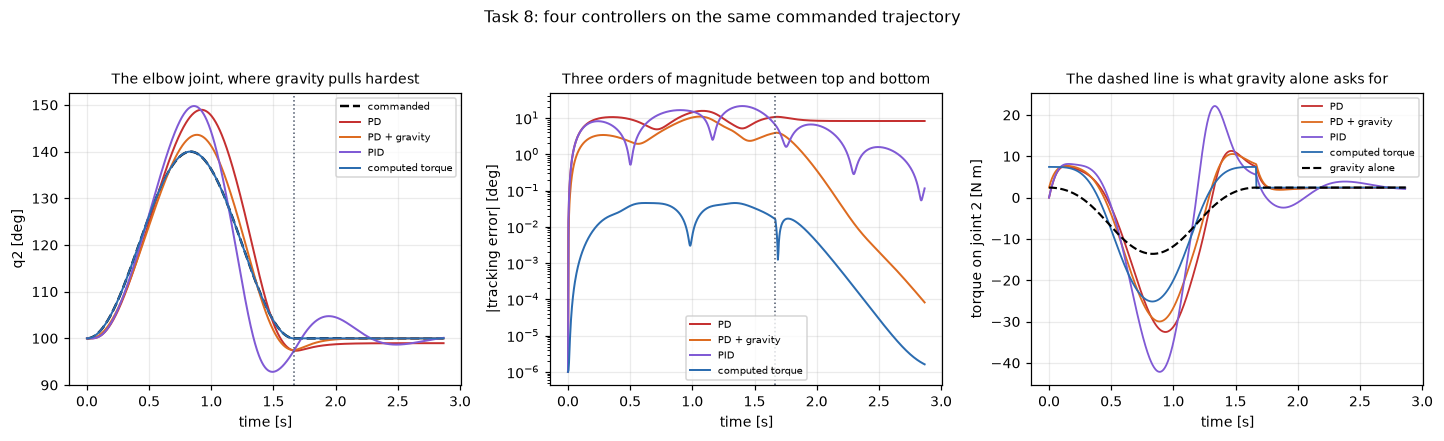

In [176]:
COLOURS = {"PD": "#c53030", "PD + gravity": "#dd6b20", "PID": "#805ad5",
           "computed torque": "#2b6cb0"}

fig, axes = plt.subplots(1, 3, figsize=(13.2, 3.8))
t = RUNS["PD"]["t"]

axes[0].plot(t, np.rad2deg(RUNS["PD"]["q_ref"][:, 1]), "k--", lw=1.6, label="commanded")
for name, run in RUNS.items():
    axes[0].plot(t, np.rad2deg(run["q"][:, 1]), color=COLOURS[name], lw=1.3, label=name)
axes[0].axvline(T_WAVE, color="#4a5568", ls=":", lw=1)
axes[0].set_xlabel("time [s]"); axes[0].set_ylabel("q2 [deg]")
axes[0].set_title("The elbow joint, where gravity pulls hardest", fontsize=9)
axes[0].legend(fontsize=6.5)

for name, run in RUNS.items():
    axes[1].semilogy(t, np.rad2deg(np.linalg.norm(run["err"], axis=1)) + 1e-6,
                     color=COLOURS[name], lw=1.3, label=name)
axes[1].axvline(T_WAVE, color="#4a5568", ls=":", lw=1)
axes[1].set_xlabel("time [s]"); axes[1].set_ylabel("|tracking error| [deg]")
axes[1].set_title("Three orders of magnitude between top and bottom", fontsize=9)
axes[1].legend(fontsize=6.5)

for name, run in RUNS.items():
    axes[2].plot(t[:-1], run["tau"][:, 1], color=COLOURS[name], lw=1.2, label=name)
axes[2].plot(t, [gravity_torque(q)[1] for q in RUNS["computed torque"]["q"]], "k--", lw=1.4,
             label="gravity alone")
axes[2].set_xlabel("time [s]"); axes[2].set_ylabel("torque on joint 2 [N m]")
axes[2].set_title("The dashed line is what gravity alone asks for", fontsize=9)
axes[2].legend(fontsize=6.5)

fig.suptitle("Task 8: four controllers on the same commanded trajectory", y=1.04, fontsize=10.5)
plt.tight_layout(); plt.show()

## 8.4 What computed torque is trading on

The comparison above is rigged in its favour, because the arm in the simulator and the arm in the
controller are the same object. Here the robot picks up a 1.2 kg item and every controller still
believes the 0.5 kg it was built with.

| at 1.2 kg | RMS while moving | against its own perfect model run |
|---|---|---|
| PD + gravity | 5.36° | 1.7x worse |
| PID | 14.31° | 2.1x worse |
| computed torque | 2.19° | 121x worse |

Computed torque loses by far the most, proportionally, and is still the most accurate of the three.
Both halves matter: a model based controller is exactly as good as its model, so 8.3's headline
number is a best case rather than a specification.

The sweep is the sharper warning. Computed torque's error dips almost to nothing at the payload it
was told about and climbs either side, which is what an error of modelling looks like rather than
one of tuning. PID breaks first: it still settles at 1 kg, and at 1.5 kg its error is still growing
when the run ends. PD + gravity degrades most gently, which is a fair advertisement for simple
controllers.

None of this is fixed by a better model, which is the argument for Task 10. Contact force is not in
any of these models, so a position controller with good gains will push until something gives.

Payload actually 1.2 kg, every model still says 0.5 kg

controller          RMS moving [deg]   worst [deg]   left at the end [deg]     vs. correct model
------------------------------------------------------------------------------------------------
PD + gravity                   5.363        12.091                  4.7378                 1.7x
PID                           14.313        45.916                  0.6185                 2.1x
computed torque                2.189         6.319                  4.6092               120.9x


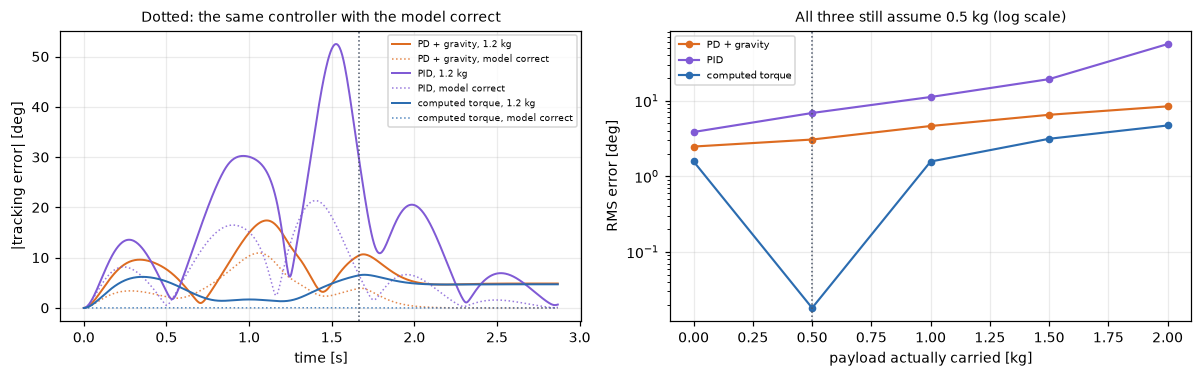

In [ ]:
HEAVY = arm_masses(payload=1.2)
WRONG = {name: simulate_arm(ctl, wave_reference, T=T_WAVE + T_HOLD,
                            plant_masses=HEAVY, model_masses=MASSES)
         for name, ctl in CONTROLLERS[1:]}

print(f"Payload actually 1.2 kg, every model still says {M_PAYLOAD} kg\n")
print(f"{'controller':<18}{'RMS moving [deg]':>18}{'worst [deg]':>14}{'left at the end [deg]':>24}"
      f"{'  vs. correct model':>22}")
print("-" * 96)
for name, run in WRONG.items():
    e = np.rad2deg(run["err"])
    moving = run["t"] <= T_WAVE
    good = np.rad2deg(RUNS[name]["err"])
    ratio = np.sqrt((e[moving]**2).mean()) / np.sqrt((good[moving]**2).mean())
    print(f"{name:<18}{np.sqrt((e[moving]**2).mean()):>18.3f}{np.abs(e[moving]).max():>14.3f}"
          f"{np.abs(e[-1]).max():>24.4f}{ratio:>20.1f}x")

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
for name, run in WRONG.items():
    axes[0].plot(run["t"], np.rad2deg(np.linalg.norm(run["err"], axis=1)), color=COLOURS[name],
                 lw=1.3, label=f"{name}, 1.2 kg")
    axes[0].plot(RUNS[name]["t"], np.rad2deg(np.linalg.norm(RUNS[name]["err"], axis=1)),
                 color=COLOURS[name], lw=1.0, ls=":", alpha=0.8, label=f"{name}, model correct")
axes[0].axvline(T_WAVE, color="#4a5568", ls=":", lw=1)
axes[0].set_xlabel("time [s]"); axes[0].set_ylabel("|tracking error| [deg]")
axes[0].set_title("Dotted: the same controller with the model correct", fontsize=9)
axes[0].legend(fontsize=6)

PAYLOAD_SWEEP = [0.0, 0.5, 1.0, 1.5, 2.0]
for name, ctl in CONTROLLERS[1:]:
    rms = [np.rad2deg(np.sqrt((simulate_arm(ctl, wave_reference, T=T_WAVE,
                                            plant_masses=arm_masses(payload=m),
                                            model_masses=MASSES)["err"]**2).mean()))
           for m in PAYLOAD_SWEEP]
    axes[1].semilogy(PAYLOAD_SWEEP, rms, "o-", color=COLOURS[name], lw=1.4, ms=4, label=name)
    if name == "PID":
        PID_SWEEP_RMS = rms
axes[1].axvline(M_PAYLOAD, color="#4a5568", ls=":", lw=1)
axes[1].set_xlabel("payload actually carried [kg]"); axes[1].set_ylabel("RMS error [deg]")
axes[1].set_title(f"All three still assume {M_PAYLOAD} kg (log scale)", fontsize=9)
axes[1].legend(fontsize=6.5)
plt.tight_layout(); plt.show()

## 8.5 Task 8 tests

The model is tested before a controller goes on top of it, since a controller papers over a wrong
model surprisingly well.

Four are worth pointing at. The **rod equivalence** test checks 8.1's claim directly: the two point
masses standing in for each link have the same mass, centre and second moment as the rod. The
**energy** test drops the arm with the motors off, which is how a subtly wrong Coriolis term gets
caught, since a wrong $C$ still gives a plausible motion and just quietly pumps energy in or out.
The **skew symmetry** test asserts the property that argument depends on. And **gravity as the
gradient of $U$** checks our two ways of computing the same thing against each other.

The control tests lean on the runs above rather than repeating them. The droop test is the one we
would keep if we could keep only one: the error PD settles at is exactly the gravity torque divided
by the gain, which pins down the controller and the gravity model at once.

In [186]:
@test("Task 8")
def test_the_mass_points_agree_with_the_dh_chain():
    # mass_points is written out in closed form for speed, so it has to be checked against the
    # kinematics everything else in the notebook uses.
    rng = make_rng(8001)
    for q in rng.uniform(-np.pi, np.pi, (50, 3)):
        T01 = dh_matrix(q[0], D1, 0, np.pi / 2)
        T02 = T01 @ dh_matrix(q[1], 0, L2, 0)
        expected = np.array([(T01 @ dh_matrix(q[1], 0, LINK2_AT[0], 0))[:3, 3],
                             (T01 @ dh_matrix(q[1], 0, LINK2_AT[1], 0))[:3, 3],
                             (T02 @ dh_matrix(q[2], 0, LINK3_AT[0], 0))[:3, 3],
                             (T02 @ dh_matrix(q[2], 0, LINK3_AT[1], 0))[:3, 3],
                             position_fk(q)])
        assert close(mass_points(q), expected, 1e-12)


@test("Task 8")
def test_a_pair_of_point_masses_stands_in_for_a_uniform_rod():
    # Same mass, same centre of mass, same second moment about that centre as a rod of mass m and
    # length L. Those three are all that a rigid body's planar dynamics can tell apart.
    for length, mass in ((L2, M_LINK2), (L3, M_LINK3)):
        at = length * np.array([0.5 - ROD_HALF, 0.5 + ROD_HALF])
        halves = np.array([mass / 2, mass / 2])
        assert close(halves.sum(), mass)
        assert close((halves * at).sum() / mass, length / 2)
        assert close((halves * (at - length / 2) ** 2).sum(), mass * length**2 / 12)


@test("Task 8")
def test_the_mass_matrix_is_symmetric_and_positive_definite_everywhere():
    rng = make_rng(8002)
    for q in rng.uniform(-np.pi, np.pi, (60, 3)):
        M = mass_matrix(q)
        assert close(M, M.T, 1e-12)
        assert np.linalg.eigvalsh(M).min() > 0, np.linalg.eigvalsh(M)


@test("Task 8")
def test_the_rotor_inertia_is_what_keeps_the_mass_matrix_invertible_straight_up():
    # Straight up every mass sits on the yaw axis, so the arm itself contributes nothing to M[0,0]
    # and only the rotor keeps that joint from being a free wheel. It is the same configuration
    # Task 7 found kinematically singular, arrived at from the other direction.
    up = np.deg2rad([0.0, 90.0, 0.0])
    assert close(mass_matrix(up)[0, 0], ROTOR_I[0], 1e-9)
    assert np.linalg.eigvalsh(mass_matrix(up)).min() > 0


@test("Task 8")
def test_kinetic_energy_from_the_mass_matrix_matches_the_moving_masses():
    rng = make_rng(8003)
    for _ in range(20):
        q, qdot = rng.uniform(-np.pi, np.pi, 3), rng.uniform(-2, 2, 3)
        from_masses = 0.5 * np.sum(ROTOR_I * qdot**2) + 0.5 * sum(
            m * np.linalg.norm(J @ qdot) ** 2 for m, J in zip(MASSES, mass_jacobians(q)))
        assert close(kinetic_energy(q, qdot), from_masses, 1e-9)


@test("Task 8")
def test_yawing_the_whole_arm_changes_neither_inertia_nor_gravity():
    # Rotating about the vertical is a symmetry of both, exactly as it was for the Jacobian.
    q = np.array([0.3, 0.9, -0.7])
    for shift in (1.4, -2.6):
        assert close(mass_matrix(q + [shift, 0, 0]), mass_matrix(q), 1e-9)
        assert close(gravity_torque(q + [shift, 0, 0]), gravity_torque(q), 1e-9)
@test("Task 8")
def test_gravity_torque_matches_the_hand_calculations():
    for _, q_deg, expected in GRAVITY_CASES:
        assert close(gravity_torque(np.deg2rad(q_deg)), expected, 1e-9)


@test("Task 8")
def test_gravity_torque_is_the_gradient_of_the_potential_energy():
    rng = make_rng(8004)
    eps = 1e-6
    for q in rng.uniform(-np.pi, np.pi, (20, 3)):
        numerical = np.array([(potential_energy(q + np.eye(3)[k] * eps)
                               - potential_energy(q - np.eye(3)[k] * eps)) / (2 * eps)
                              for k in range(3)])
        assert close(numerical, gravity_torque(q), 1e-6)


@test("Task 8")
def test_gravity_never_acts_on_the_yaw_joint():
    rng = make_rng(8005)
    for q in rng.uniform(-np.pi, np.pi, (30, 3)):
        assert abs(gravity_torque(q)[0]) < 1e-9


@test("Task 8")
def test_inverse_and_forward_dynamics_are_inverses():
    rng = make_rng(8006)
    for _ in range(30):
        q, qdot, qddot = rng.uniform(-2, 2, 3), rng.uniform(-2, 2, 3), rng.uniform(-5, 5, 3)
        assert close(forward_dynamics(q, qdot, inverse_dynamics(q, qdot, qddot)), qddot, 1e-9)


@test("Task 8")
def test_the_coriolis_matrix_is_the_skew_symmetric_choice():
    rng = make_rng(8007)
    for _ in range(20):
        q, qdot = rng.uniform(-np.pi, np.pi, 3), rng.uniform(-2, 2, 3)
        Mdot = sum(dmass_dq(q)[k] * qdot[k] for k in range(3))
        S = Mdot - 2 * coriolis_matrix(q, qdot)
        assert close(S, -S.T, 1e-7)


@test("Task 8")
def test_the_coriolis_term_is_quadratic_in_the_joint_rates():
    # C(q, qdot) qdot is built from products of rates, so doubling every rate quadruples it, and a
    # standing still arm has none of it at all.
    q, qdot = np.array([0.4, 0.8, -1.1]), np.array([0.5, -0.9, 1.3])
    single = coriolis_matrix(q, qdot) @ qdot
    assert close(coriolis_matrix(q, 2 * qdot) @ (2 * qdot), 4 * single, 1e-7)
    assert close(coriolis_matrix(q, np.zeros(3)) @ np.zeros(3), np.zeros(3), 1e-12)


@test("Task 8")
def test_the_arm_conserves_energy_when_no_torque_is_applied():
    # Nothing in the model dissipates, so a dropped arm keeps its energy. This catches a Coriolis
    # term that is subtly wrong: a wrong C quietly adds or removes energy while still producing a
    # motion that looks plausible.
    log = simulate_arm(motors_off, hold(np.zeros(3)), T=0.6, q0=np.zeros(3))
    total = np.array([kinetic_energy(q, v) + potential_energy(q)
                      for q, v in zip(log["q"], log["qdot"])])
    assert np.abs(total - total[0]).max() / abs(total[0]) < 1e-4, np.abs(total - total[0]).max()
    assert log["q"][-1][1] < -0.5, "the arm should have fallen"
    assert close(log["q"][:, 0], 0.0, 1e-12), "and it should not have yawed while doing it"
@test("Task 8")
def test_computed_torque_tracks_the_commanded_trajectory():
    error = np.rad2deg(np.abs(RUNS["computed torque"]["err"])).max()
    assert error < 0.1, error


@test("Task 8")
def test_gravity_compensation_is_what_removes_the_steady_state_droop():
    # At rest the difference between the three is only the gravity torque: PD has to buy it with
    # position error, PD + gravity is handed it, PID integrates its way to it.
    settled = lambda name: np.rad2deg(np.abs(RUNS[name]["err"][-1])).max()
    assert settled("PD") > 5.0, settled("PD")
    assert settled("PD + gravity") < 0.01, settled("PD + gravity")
    assert settled("PID") < 0.5, settled("PID")
    assert settled("computed torque") < 0.01


@test("Task 8")
def test_the_droop_is_the_gravity_torque_divided_by_the_gain():
    # A PD controller at rest is a spring: it holds an error just big enough for KP times that
    # error to carry the gravity torque.
    final = RUNS["PD"]["q"][-1]
    assert close(KP * RUNS["PD"]["err"][-1], -gravity_torque(final), 0.05)


@test("Task 8")
def test_no_controller_asks_for_more_torque_than_the_motors_have():
    for name, run in RUNS.items():
        assert np.all(np.abs(run["tau"]) <= TAU_MAX + 1e-9), name


@test("Task 8")
def test_saturation_clips_a_silly_gain_instead_of_letting_it_explode():
    silly = lambda t, q, qdot, ref, memory, masses: 1e4 * (ref(t)[0] - q)
    log = simulate_arm(silly, wave_reference, T=0.2, q0=HOME_Q + 0.5)
    assert np.all(np.abs(log["tau"]) <= TAU_MAX + 1e-9)
    assert np.isfinite(log["q"]).all()


@test("Task 8")
def test_a_wrong_payload_costs_accuracy_but_not_stability():
    # 1.2 kg in a gripper the controller thinks is holding 0.5 kg. Computed torque degrades, and
    # is still the most accurate of the three; the run stays bounded.
    ct = np.rad2deg(np.abs(WRONG["computed torque"]["err"])).max()
    assert 1.0 < ct < 20.0, ct
    assert ct < np.rad2deg(np.abs(WRONG["PD + gravity"]["err"])).max()


@test("Task 8")
def test_the_simulation_is_deterministic():
    a = simulate_arm(computed_torque_control, wave_reference, T=0.3)
    b = simulate_arm(computed_torque_control, wave_reference, T=0.3)
    assert close(a["q"], b["q"], 0.0)


run_tests("Task 8")

  pass    the mass points agree with the dh chain
  pass    a pair of point masses stands in for a uniform rod
  pass    the mass matrix is symmetric and positive definite everywhere
  pass    the rotor inertia is what keeps the mass matrix invertible straight up
  pass    kinetic energy from the mass matrix matches the moving masses
  pass    yawing the whole arm changes neither inertia nor gravity
  pass    gravity torque matches the hand calculations
  pass    gravity torque is the gradient of the potential energy
  pass    gravity never acts on the yaw joint
  pass    inverse and forward dynamics are inverses
  pass    the coriolis matrix is the skew symmetric choice
  pass    the coriolis term is quadratic in the joint rates
  pass    the arm conserves energy when no torque is applied
  pass    computed torque tracks the commanded trajectory
  pass    gravity compensation is what removes the steady state droop
  pass    the droop is the gravity torque divided by the gain
  pass   

40

---
# Task 9: Trajectory Generation

Task 8's controllers each needed a $q_d(t)$, $\dot q_d(t)$, $\ddot q_d(t)$ and were handed a cosine
wave to keep the comparison fair. Task 9 generates the one the robot needs: from the home pose the
arm rides in, to the pre contact pose 8 cm off the light switch that Task 7 stopped at.

A trajectory is not a path. Task 3's paths are geometry with no clock attached; a trajectory says
*when* the arm is at each point, and the timing is what decides whether the joints stay inside their
limits and whether the arm arrives moving or at rest.

## 9.1 Two profiles

Both profiles are written for a scalar $s$ running from 0 to 1, and every joint is driven by it:

$$q(t) = q_0 + s(t)\,(q_f - q_0)$$

so the joints stay synchronised for free, the path through joint space is the straight line between
the two configurations, and the joint limits become limits on $s$ once, by dividing through by each
joint's share of the move.

**Quintic.** Six boundary conditions (position, velocity and acceleration at each end), so fifth
order is the lowest that meets them:

$$s(\tau) = 10\tau^3 - 15\tau^4 + 6\tau^5, \qquad \tau = t/T$$

with peak speed $1.875/T$ and peak acceleration $10/\sqrt{3}T^2$, which is how we pick the shortest
$T$ that fits inside the joint limits.

**Trapezoidal.** Accelerate at the limit, cruise at the limit, decelerate at the limit. Quicker over
the same move, 1.31 s against 1.53 s, because it spends time at its limits instead of touching them
in passing. The cost is that its acceleration steps between full and none at four instants.

We drive the quintic anyway: the arm is arriving at a wall it is about to press, and handing over to
a force controller with a step in commanded torque is the wrong way to begin that.

In [ ]:

VMAX = np.deg2rad([90.0, 60.0, 90.0])     
AMAX = np.deg2rad([180.0, 120.0, 180.0])  


def quintic_profile(T):
    """s(t) from 0 to 1 with zero velocity *and* zero acceleration at both ends.

    Six boundary conditions, so five is the lowest order polynomial that can meet them:
    s = 10 tau^3 - 15 tau^4 + 6 tau^5 with tau = t / T. Returns a function giving (s, sdot, sddot).
    """
    def profile(t):
        tau = np.clip(t / T, 0.0, 1.0)
        return (tau**3 * (10 - 15 * tau + 6 * tau**2),
                30 * tau**2 * (1 - tau)**2 / T,
                60 * tau * (1 - 3 * tau + 2 * tau**2) / T**2)
    return profile


def trapezoidal_profile(v_lim, a_lim):
    """s(t) from 0 to 1 on a constant acceleration, constant speed, constant deceleration profile.

    Returns (profile, T, blend time). If the move is too short to reach v_lim the profile becomes
    triangular, which is what the first branch handles.
    """
    if v_lim**2 / a_lim > 1.0:
        v_lim = np.sqrt(a_lim)                       
    t_blend = v_lim / a_lim
    T = 1.0 / v_lim + t_blend

    def profile(t):
        t = float(np.clip(t, 0.0, T))
        if t < t_blend:
            return 0.5 * a_lim * t**2, a_lim * t, a_lim
        if t <= T - t_blend:
            return v_lim * t - 0.5 * v_lim * t_blend, v_lim, 0.0
        left = T - t
        return 1.0 - 0.5 * a_lim * left**2, a_lim * left, -a_lim
    return profile, T, t_blend


def quintic_duration(delta_q, vmax=VMAX, amax=AMAX):
    """Shortest duration for which a quintic through delta_q respects every joint limit.

    Peak speed is 1.875 |dq| / T and peak acceleration 10 |dq| / (sqrt(3) T^2), both from the
    polynomial, so each limit gives a lower bound on T and we take the largest.
    """
    d = np.abs(np.asarray(delta_q, dtype=float))
    moving = d > 1e-12
    if not moving.any():
        return 0.0
    return float(max(np.max(1.875 * d[moving] / vmax[moving]),
                     np.sqrt(np.max((10 / np.sqrt(3)) * d[moving] / amax[moving]))))


def profile_limits(delta_q, vmax=VMAX, amax=AMAX):
    """The joint limits rewritten as limits on s, so one profile drives every joint at once."""
    d = np.abs(np.asarray(delta_q, dtype=float))
    moving = d > 1e-12
    return float(np.min(vmax[moving] / d[moving])), float(np.min(amax[moving] / d[moving]))


def joint_trajectory(q0, qf, profile, T, dt=DT_CTRL):
    """Sample a joint space trajectory. Returns (t, q, qdot, qddot) arrays.

    Every joint follows the same s(t), so they all start and stop together and the path in joint
    space is the straight line from q0 to qf. What that draws in the room is another matter, which
    is what 9.2 is about.
    """
    delta_q = np.asarray(qf, dtype=float) - np.asarray(q0, dtype=float)
    t = np.arange(0.0, T + dt / 2, dt)
    s = np.array([profile(tt) for tt in t])
    return (t, q0 + np.outer(s[:, 0], delta_q),
            np.outer(s[:, 1], delta_q), np.outer(s[:, 2], delta_q))


PRE_CONTACT_Q, pre_ok, _ = ik_pseudoinverse_damped(PRE_CONTACT, HOME_Q)
DELTA_Q = PRE_CONTACT_Q - HOME_Q

T_QUINTIC = quintic_duration(DELTA_Q)
V_LIM, A_LIM = profile_limits(DELTA_Q)
trapezoid, T_TRAPEZOID, T_BLEND = trapezoidal_profile(V_LIM, A_LIM)
quintic = quintic_profile(T_QUINTIC)

PROFILES = {"quintic": (quintic, T_QUINTIC), "trapezoid": (trapezoid, T_TRAPEZOID)}
TRAJECTORIES = {name: joint_trajectory(HOME_Q, PRE_CONTACT_Q, prof, T)
                for name, (prof, T) in PROFILES.items()}

print(f"home {np.round(np.rad2deg(HOME_Q), 1)} deg to pre contact "
      f"{np.round(np.rad2deg(PRE_CONTACT_Q), 1)} deg (IK converged: {pre_ok})")
print(f"so the move is {np.round(np.rad2deg(DELTA_Q), 1)} deg, and the binding joint is "
      f"q{int(np.argmax(np.abs(DELTA_Q) / VMAX)) + 1}\n")
print(f"{'profile':<12}{'T [s]':>8}{'peak speed [deg/s]':>30}{'peak accel [deg/s^2]':>30}"
      f"{'endpoint error':>17}")
print("-" * 97)
for name, (t, q, qdot, qddot) in TRAJECTORIES.items():
    print(f"{name:<12}{PROFILES[name][1]:>8.3f}"
          f"{str(np.round(np.rad2deg(np.abs(qdot).max(axis=0)), 1)):>30}"
          f"{str(np.round(np.rad2deg(np.abs(qddot).max(axis=0)), 1)):>30}"
          f"{np.abs(q[-1] - PRE_CONTACT_Q).max():>17.1e}")
print(f"{'limits':<12}{'':>8}{str(np.round(np.rad2deg(VMAX), 1)):>30}"
      f"{str(np.round(np.rad2deg(AMAX), 1)):>30}")
print(f"\nBoth respect the limits and both start and end at rest. The trapezoid takes "
      f"{T_TRAPEZOID:.2f} s\nagainst the quintic's {T_QUINTIC:.2f} s, "
      f"{100 * (T_QUINTIC - T_TRAPEZOID) / T_TRAPEZOID:.0f}% quicker, because it spends "
      f"{100 * (T_TRAPEZOID - 2 * T_BLEND) / T_TRAPEZOID:.0f}% of the move at\n"
      f"full speed while the quintic touches its peak for an instant.")

home [   0.  100. -120.] deg to pre contact [ -0.   51.6 -69. ] deg (IK converged: True)
so the move is [ -0.  -48.4  51. ] deg, and the binding joint is q2

profile        T [s]            peak speed [deg/s]          peak accel [deg/s^2]   endpoint error
-------------------------------------------------------------------------------------------------
quintic        1.527              [ 0.  59.5 62.6]           [  0.  120.  126.3]          0.0e+00
trapezoid      1.307              [ 0.  60.  63.1]           [  0.  120.  126.3]          0.0e+00
limits                               [90. 60. 90.]              [180. 120. 180.]

Both respect the limits and both start and end at rest. The trapezoid takes 1.31 s
against the quintic's 1.53 s, 17% quicker, because it spends 24% of the move at
full speed while the quintic touches its peak for an instant.


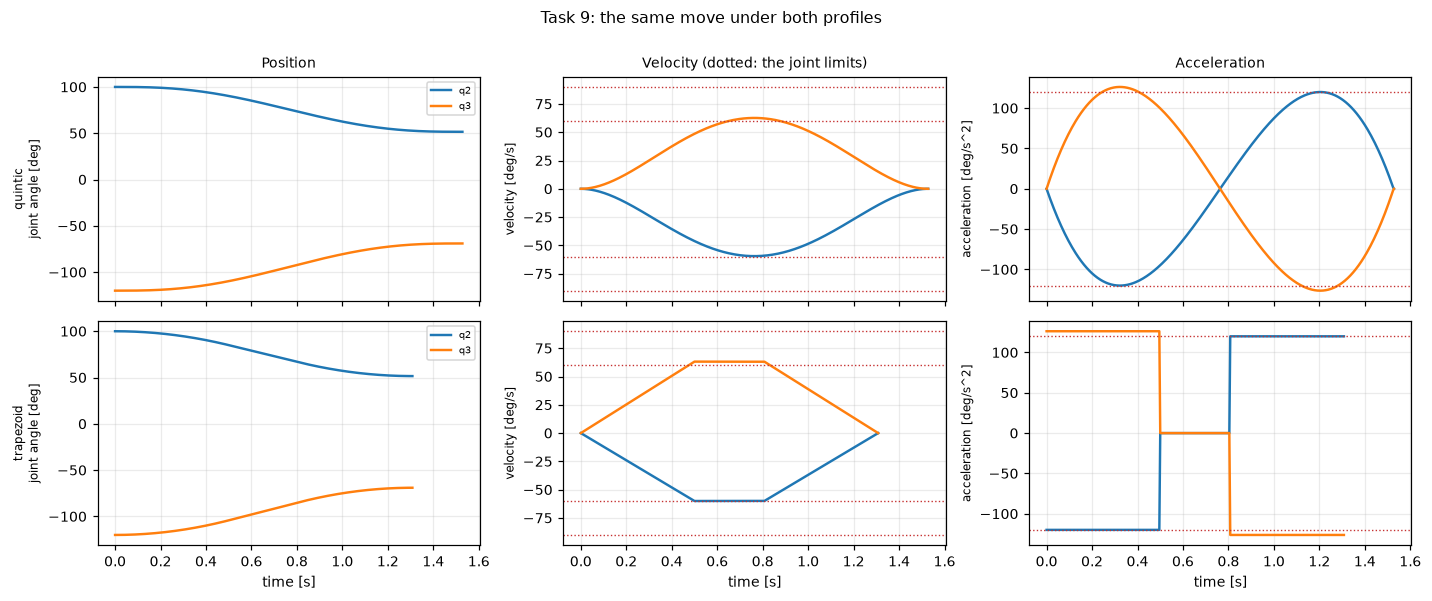

The acceleration column is the whole argument. The quintic leaves and arrives at zero
acceleration; the trapezoid steps between full acceleration and none four times, and each
step is an instant change in torque that a real drivetrain answers with a jolt.


In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(13, 5.4), sharex="col")
STYLES = {"quintic": ("#2b6cb0", "-"), "trapezoid": ("#dd6b20", "--")}

for row, name in enumerate(TRAJECTORIES):
    t, q, qdot, qddot = TRAJECTORIES[name]
    colour, _ = STYLES[name]
    for j in range(1, 3):                      
        axes[row, 0].plot(t, np.rad2deg(q[:, j]), lw=1.6, label=f"q{j + 1}")
        axes[row, 1].plot(t, np.rad2deg(qdot[:, j]), lw=1.6, label=f"q{j + 1}")
        axes[row, 2].plot(t, np.rad2deg(qddot[:, j]), lw=1.6, label=f"q{j + 1}")
    for j, limit in ((1, VMAX[1]), (2, VMAX[2])):
        axes[row, 1].axhline(np.rad2deg(limit), color="#c53030", ls=":", lw=0.9)
        axes[row, 1].axhline(-np.rad2deg(limit), color="#c53030", ls=":", lw=0.9)
    axes[row, 2].axhline(np.rad2deg(AMAX[1]), color="#c53030", ls=":", lw=0.9)
    axes[row, 2].axhline(-np.rad2deg(AMAX[1]), color="#c53030", ls=":", lw=0.9)
    axes[row, 0].set_ylabel(f"{name}\njoint angle [deg]", fontsize=8)
    axes[row, 1].set_ylabel("velocity [deg/s]", fontsize=8)
    axes[row, 2].set_ylabel("acceleration [deg/s^2]", fontsize=8)
    axes[row, 0].legend(fontsize=6.5)

for ax in axes[1]:
    ax.set_xlabel("time [s]")
axes[0, 0].set_title("Position", fontsize=9)
axes[0, 1].set_title("Velocity (dotted: the joint limits)", fontsize=9)
axes[0, 2].set_title("Acceleration", fontsize=9)
fig.suptitle("Task 9: the same move under both profiles", y=1.0, fontsize=10.5)
plt.tight_layout(); plt.show()

print("The acceleration column is the whole argument. The quintic leaves and arrives at zero")
print("acceleration; the trapezoid steps between full acceleration and none four times, and each")
print("step is an instant change in torque that a real drivetrain answers with a jolt.")

## 9.2 Straight in joint space, or straight in the room

A straight line in joint space is not a straight line in the room: this one bulges **5.3 cm** off
the direct route, because interpolating the joints does not interpolate the gripper. For many moves
that is fine. For a move that closes on a wall in someone's house it is not, since "it ends up in
the right place" is a weaker promise than "it does not sweep through anything on the way".

So the Cartesian version puts the profile on the gripper, $p(t) = p_0 + s(t)(p_f - p_0)$, and finds
the joints by IK at each sample, seeded from the previous one to stay on one solution branch. The
rates come from the Jacobian rather than from differencing positions:

$$\dot q = J^{-1}\dot x, \qquad \ddot q = J^{-1}\left(\ddot x - \dot J \dot q\right)$$

where $\dot J$ is a derivative along the path, so central differences on $q \pm \delta \dot q$ give
it directly.

This is the line Task 7 drove with resolved rate control, which integrated open loop and drifted
0.63 mm off it. Generating by IK puts every sample on the line by construction, and produces the
velocities and accelerations Task 8 needs, which resolved rate control never did.

**The catch**, and it caught us: a Cartesian trajectory obeys no joint limit, because the IK decides
what the joints do. The same move at the same duration asks the elbow for **105%** of its
acceleration limit. Stretching the duration to 1.60 s brings it back inside, and we check rather
than assume.

straight line from [0.366 0.    1.12 ] to [0.85 0.   1.02], 0.495 m

trajectory                  T [s]   off the line, worst   endpoint error   of the speed limit  of the accel limit
-----------------------------------------------------------------------------------------------------------------
joint space quintic         1.527              52.72 mm         0.070 mm                 99%                100%
Cartesian, same T           1.527               0.00 mm         0.000 mm                 96%                105%
Cartesian, stretched        1.595               0.00 mm         0.000 mm                 92%                 96%

The middle row is the catch. Reparametrising the same duration into a straight line
asks the elbow for 105% of its acceleration limit, because the joints no longer move
proportionally: the IK decides what they do, and the limits are not in that calculation.
Stretching the move to 1.595 s brings it back inside, and we check rather than
assume.


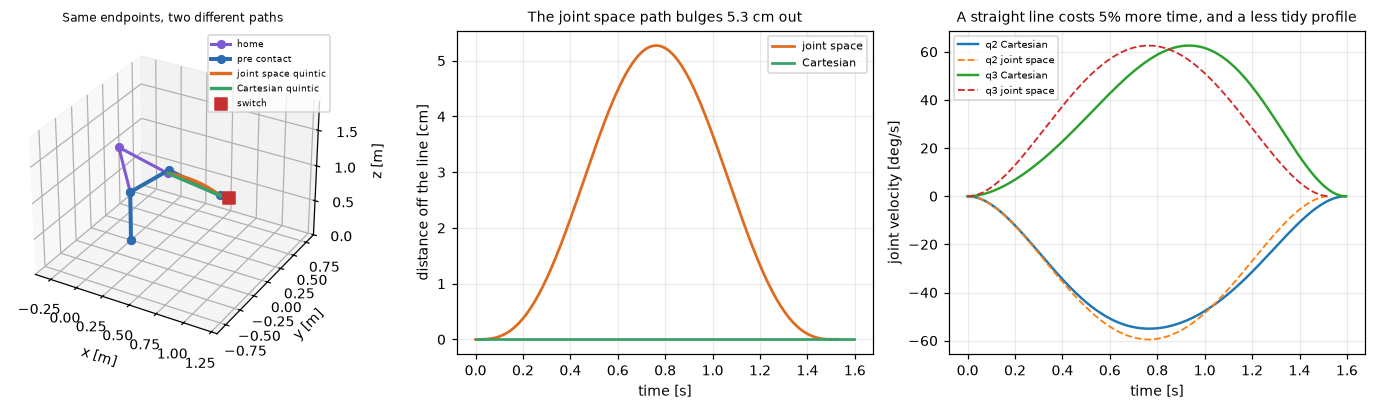

In [181]:
def cartesian_trajectory(q0, p_target, T, dt=DT_CTRL, delta_t=1e-4):
    """A straight line in the room, sampled into joint space. Returns (t, q, qdot, qddot).

    The gripper follows p(t) = p0 + s(t) (p_target - p0) with the same quintic s. Positions come
    from IK seeded with the previous sample, which keeps the solution branch continuous; the rates
    come from the Jacobian rather than from differencing the positions:

        qdot  = J^-1 xdot,      qddot = J^-1 (xddot - Jdot qdot)

    Jdot is the derivative of J along the path, which is a directional derivative in the direction
    the joints are already moving, so central differences on q +/- delta_t qdot give it directly.
    """
    p0 = position_fk(q0)
    delta_p = np.asarray(p_target, dtype=float) - p0
    profile = quintic_profile(T)
    t = np.arange(0.0, T + dt / 2, dt)
    q = np.asarray(q0, dtype=float).copy()
    qs, qdots, qddots = [], [], []
    for tt in t:
        s, sdot, sddot = profile(tt)
        q, converged, _ = ik_pseudoinverse_damped(p0 + s * delta_p, q, tol=1e-9, max_iter=60)
        if not converged:
            raise RuntimeError(f"IK failed at t = {tt:.3f} s; the straight line leaves the "
                               f"workspace or passes through a singularity")
        J = jacobian_fd(q)
        qdot = np.linalg.solve(J, sdot * delta_p)
        Jdot = (jacobian_fd(q + delta_t * qdot) - jacobian_fd(q - delta_t * qdot)) / (2 * delta_t)
        qs.append(q.copy())
        qdots.append(qdot)
        qddots.append(np.linalg.solve(J, sddot * delta_p - Jdot @ qdot))
    return t, np.array(qs), np.array(qdots), np.array(qddots)


P_START = position_fk(HOME_Q)
LINE_UNIT = (PRE_CONTACT - P_START) / np.linalg.norm(PRE_CONTACT - P_START)


def off_the_line(points):
    """How far each point sits off the straight line from the home pose to the pre contact pose."""
    rel = np.asarray(points) - P_START
    return np.linalg.norm(rel - np.outer(rel @ LINE_UNIT, LINE_UNIT), axis=1)


def fits_the_limits(qdot, qddot, vmax=VMAX, amax=AMAX):
    """How much too fast the trajectory is: 1.0 or less means it fits. Returns (speed, accel)."""
    return (float(np.max(np.abs(qdot).max(axis=0) / vmax)),
            float(np.max(np.abs(qddot).max(axis=0) / amax)))


def cartesian_trajectory_within_limits(q0, p_target, T0, tries=6):
    """A straight line trajectory, stretched in time until it fits inside the joint limits.

    A Cartesian trajectory obeys no joint limit by construction: the IK decides what the joints
    do. Slowing the whole profile down scales speed by 1/T and acceleration by 1/T^2, so one pass
    of rescaling usually settles it, and we check rather than assume.
    """
    T = T0
    for _ in range(tries):
        traj = cartesian_trajectory(q0, p_target, T)
        speed, accel = fits_the_limits(traj[2], traj[3])
        if max(speed, accel) <= 1.0:
            return T, traj
        T *= 1.02 * max(speed, np.sqrt(accel))       # 2% of margin so it does not sit on the limit
    raise RuntimeError("could not fit the straight line inside the joint limits")


CART_UNSCALED = cartesian_trajectory(HOME_Q, PRE_CONTACT, T_QUINTIC)
T_CART, CART_TRAJ = cartesian_trajectory_within_limits(HOME_Q, PRE_CONTACT, T_QUINTIC)
P_JOINT = np.array([position_fk(q) for q in TRAJECTORIES["quintic"][1]])
P_CART = np.array([position_fk(q) for q in CART_TRAJ[1]])

print(f"straight line from {np.round(P_START, 3)} to {np.round(PRE_CONTACT, 3)}, "
      f"{np.linalg.norm(PRE_CONTACT - P_START):.3f} m\n")
print(f"{'trajectory':<26}{'T [s]':>7}{'off the line, worst':>22}{'endpoint error':>17}"
      f"{'of the speed limit':>21}{'of the accel limit':>20}")
print("-" * 113)
for name, T, traj, points in [
        ("joint space quintic", T_QUINTIC, TRAJECTORIES["quintic"], P_JOINT),
        ("Cartesian, same T", T_QUINTIC, CART_UNSCALED,
         np.array([position_fk(q) for q in CART_UNSCALED[1]])),
        ("Cartesian, stretched", T_CART, CART_TRAJ, P_CART)]:
    speed, accel = fits_the_limits(traj[2], traj[3])
    print(f"{name:<26}{T:>7.3f}{off_the_line(points).max() * 1000:>19.2f} mm"
          f"{np.linalg.norm(points[-1] - PRE_CONTACT) * 1000:>14.3f} mm"
          f"{speed:>20.0%}{accel:>20.0%}")

print(f"\nThe middle row is the catch. Reparametrising the same duration into a straight line")
print(f"asks the elbow for {fits_the_limits(*CART_UNSCALED[2:4])[1]:.0%} of its acceleration "
      f"limit, because the joints no longer move")
print(f"proportionally: the IK decides what they do, and the limits are not in that calculation.")
print(f"Stretching the move to {T_CART:.3f} s brings it back inside, and we check rather than")
print(f"assume.")

fig = plt.figure(figsize=(13, 3.8))

ax1 = fig.add_subplot(1, 3, 1, projection="3d")
plot_arm(ax1, HOME_Q, color="#805ad5", lw=2.0, label="home")
plot_arm(ax1, PRE_CONTACT_Q, color="#2b6cb0", lw=2.6, label="pre contact")
ax1.plot(P_JOINT[:, 0], P_JOINT[:, 1], P_JOINT[:, 2], color="#dd6b20", lw=2.2,
         label="joint space quintic")
ax1.plot(P_CART[:, 0], P_CART[:, 1], P_CART[:, 2], color="#38a169", lw=2.2,
         label="Cartesian quintic")
ax1.scatter(*SWITCH_TARGET, color="#c53030", s=60, marker="s", label="switch")
set_arm_axes(ax1, "Same endpoints, two different paths")
ax1.legend(fontsize=6)

ax2 = fig.add_subplot(1, 3, 2)
ax2.plot(TRAJECTORIES["quintic"][0], off_the_line(P_JOINT) * 100, color="#dd6b20", lw=1.8,
         label="joint space")
ax2.plot(CART_TRAJ[0], off_the_line(P_CART) * 100, color="#38a169", lw=1.8, label="Cartesian")
ax2.set_xlabel("time [s]"); ax2.set_ylabel("distance off the line [cm]")
ax2.set_title(f"The joint space path bulges {off_the_line(P_JOINT).max() * 100:.1f} cm out",
              fontsize=9)
ax2.legend(fontsize=7)

ax3 = fig.add_subplot(1, 3, 3)
for j in range(1, 3):
    ax3.plot(CART_TRAJ[0], np.rad2deg(CART_TRAJ[2][:, j]), lw=1.6, label=f"q{j + 1} Cartesian")
    ax3.plot(TRAJECTORIES["quintic"][0], np.rad2deg(TRAJECTORIES["quintic"][2][:, j]), ls="--",
             lw=1.2, label=f"q{j + 1} joint space")
ax3.set_xlabel("time [s]"); ax3.set_ylabel("joint velocity [deg/s]")
ax3.set_title(f"A straight line costs {100 * (T_CART - T_QUINTIC) / T_QUINTIC:.0f}% more time, "
              f"and a less tidy profile", fontsize=9)
ax3.legend(fontsize=6.5)
plt.tight_layout(); plt.show()

## 9.3 Driving it, not just drawing it

A trajectory nobody follows is a plot, so it is played into Task 8's controllers at the control
rate, exactly as it would be on hardware: generated once, sampled, then tracked.

| | worst joint error | off the straight line | gripper at the end |
|---|---|---|---|
| PD + gravity | 0.74° | 9.65 mm | 0.71 mm |
| computed torque | **0.017°** | **0.07 mm** | **0.003 mm** |

The middle column is the one this scenario cares about. The trajectory is straight to within a
micron by construction, but PD + gravity tracks it lazily enough to bow nearly a centimetre off it
under load. Planning a straight line is not the same as moving in one.

The arm finishes stopped, 8.00 cm from the switch, with zero commanded acceleration. That is what
Task 10 wants handed over: the last 8 cm are a contact problem, not a position problem.

Task 8's controllers driving Task 9's trajectory, 1.60 s of motion then 0.4 s of holding

controller          worst joint error   off the line   gripper at the end    left moving
----------------------------------------------------------------------------------------
PD + gravity                 0.741 deg        9.65 mm             0.714 mm      0.1958 deg/s
computed torque              0.017 deg        0.07 mm             0.003 mm      0.0043 deg/s

Under computed torque the gripper finishes at [0.85 0.   1.02] in the base frame,
8.00 cm short of the switch and stopped. That gap is Task 10's, and the arm arrives
with no acceleration left over, which is the reason for choosing the quintic over the trapezoid.


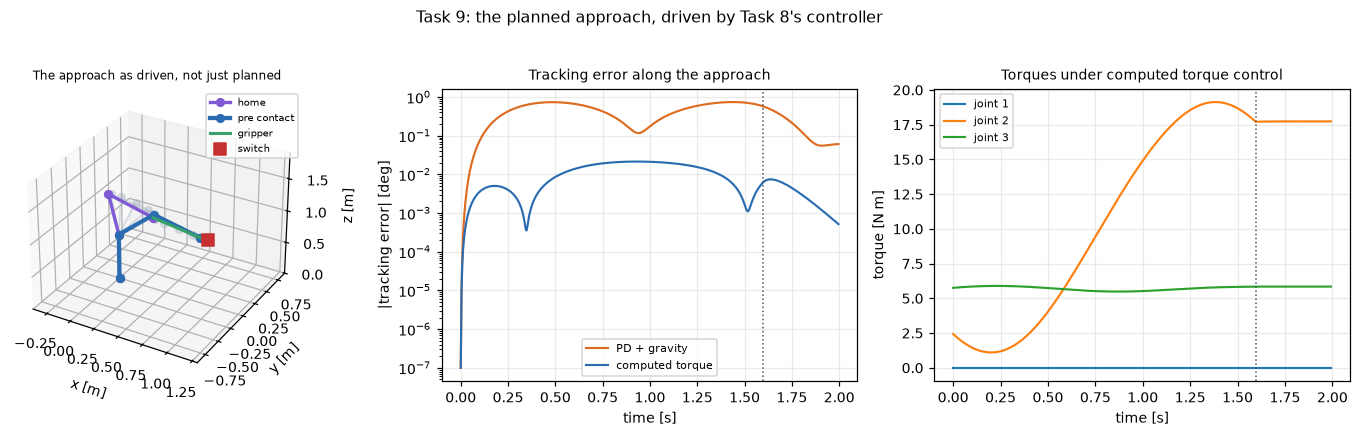

In [182]:
def sampled_reference(t_grid, q, qdot, qddot):
    """Turn sampled trajectory arrays into the (q_d, qdot_d, qddot_d) function a controller wants.

    Generation and control are separate jobs running at different rates on a real robot: the
    trajectory is worked out once, then played back. Linear interpolation between samples is
    enough here because the samples are already at the control rate.
    """
    def reference(t):
        tt = float(np.clip(t, t_grid[0], t_grid[-1]))
        return tuple(np.array([np.interp(tt, t_grid, series[:, j]) for j in range(3)])
                     for series in (q, qdot, qddot))
    return reference


APPROACH_REF = sampled_reference(*CART_TRAJ)
T_SETTLE = 0.4                     # holding time after the profile ends, so we can see it settle
APPROACH = {name: simulate_arm(ctl, APPROACH_REF, T=T_CART + T_SETTLE)
            for name, ctl in CONTROLLERS[1::2]}       # PD + gravity, and computed torque

print(f"Task 8's controllers driving Task 9's trajectory, {T_CART:.2f} s of motion "
      f"then {T_SETTLE} s of holding\n")
print(f"{'controller':<18}{'worst joint error':>19}{'off the line':>15}{'gripper at the end':>21}"
      f"{'left moving':>15}")
print("-" * 88)
for name, run in APPROACH.items():
    points = np.array([position_fk(q) for q in run["q"]])
    print(f"{name:<18}{np.rad2deg(np.abs(run['err'])).max():>16.3f} deg"
          f"{off_the_line(points).max() * 1000:>12.2f} mm"
          f"{np.linalg.norm(points[-1] - PRE_CONTACT) * 1000:>18.3f} mm"
          f"{np.rad2deg(np.abs(run['qdot'][-1]).max()):>12.4f} deg/s")

FINAL_Q = APPROACH["computed torque"]["q"][-1]
FINAL_P = position_fk(FINAL_Q)
print(f"\nUnder computed torque the gripper finishes at {np.round(FINAL_P, 4)} in the base frame,")
print(f"{(SWITCH_TARGET[0] - FINAL_P[0]) * 100:.2f} cm short of the switch and stopped. That gap "
      f"is Task 10's, and the arm arrives\nwith no acceleration left over, which is the reason "
      f"for choosing the quintic over the trapezoid.")

fig = plt.figure(figsize=(13, 3.8))
run = APPROACH["computed torque"]
points = np.array([position_fk(q) for q in run["q"]])

ax1 = fig.add_subplot(1, 3, 1, projection="3d")
for k in range(0, len(run["q"]), max(1, len(run["q"]) // 7)):
    plot_arm(ax1, run["q"][k], color="#a0aec0", alpha=0.35, lw=1.4)
plot_arm(ax1, run["q"][0], color="#805ad5", lw=2.2, label="home")
plot_arm(ax1, run["q"][-1], color="#2b6cb0", lw=2.8, label="pre contact")
ax1.plot(points[:, 0], points[:, 1], points[:, 2], color="#38a169", lw=2.0, label="gripper")
ax1.scatter(*SWITCH_TARGET, color="#c53030", s=60, marker="s", label="switch")
set_arm_axes(ax1, "The approach as driven, not just planned")
ax1.legend(fontsize=6.5)

ax2 = fig.add_subplot(1, 3, 2)
for name, r in APPROACH.items():
    ax2.semilogy(r["t"], np.rad2deg(np.linalg.norm(r["err"], axis=1)) + 1e-7,
                 color=COLOURS[name], lw=1.4, label=name)
ax2.axvline(T_CART, color="#4a5568", ls=":", lw=1)
ax2.set_xlabel("time [s]"); ax2.set_ylabel("|tracking error| [deg]")
ax2.set_title("Tracking error along the approach", fontsize=9)
ax2.legend(fontsize=7)

ax3 = fig.add_subplot(1, 3, 3)
for j in range(3):
    ax3.plot(run["t"][:-1], run["tau"][:, j], lw=1.4, label=f"joint {j + 1}")
ax3.axvline(T_CART, color="#4a5568", ls=":", lw=1)
ax3.set_xlabel("time [s]"); ax3.set_ylabel("torque [N m]")
ax3.set_title("Torques under computed torque control", fontsize=9)
ax3.legend(fontsize=7)
fig.suptitle("Task 9: the planned approach, driven by Task 8's controller", y=1.03, fontsize=10.5)
plt.tight_layout(); plt.show()

## 9.4 Task 9 tests

The profile tests are mostly boundary conditions, since that is what a profile is: the quintic
leaves and arrives at zero velocity *and* zero acceleration, its peaks match $1.875/T$ and
$10/\sqrt{3}T^2$, and $s$ never goes backwards. The trapezoid is checked against the limits it was
given, checked to actually reach its cruise speed, and checked in the short move case where there is
no room to cruise and it has to come out triangular.

Two tests hold 9.2's claims honest in both directions: one asserts the Cartesian path stays on the
line *and* that the joint space path does not, since a test that only checked the good case would
pass if both were straight and the section's argument were imaginary; the other asserts the
unstretched trajectory really does exceed a joint limit, so the rescaling is not ceremony.

The last group checks the handover to Task 10: the driven approach arrives within 0.1 mm, stopped,
still on its line, with the 8 cm standoff intact.

In [ ]:
@test("Task 9")
def test_the_quintic_starts_and_stops_at_rest():
    profile = quintic_profile(2.0)
    for t, expected_s in ((0.0, 0.0), (2.0, 1.0)):
        s, sdot, sddot = profile(t)
        assert close(s, expected_s)
        assert close(sdot, 0.0)     
        assert close(sddot, 0.0)     
    assert close(profile(1.0)[0], 0.5)


@test("Task 9")
def test_the_quintic_peaks_where_the_closed_form_says():
    T = 1.7
    profile = quintic_profile(T)
    samples = np.array([profile(t) for t in np.linspace(0, T, 4001)])
    assert close(samples[:, 1].max(), 1.875 / T, 1e-5)                
    assert close(samples[:, 2].max(), 10 / (np.sqrt(3) * T**2), 1e-4)  
    assert np.all(np.diff(samples[:, 0]) >= 0), "s must not go backwards"


@test("Task 9")
def test_the_trapezoid_obeys_the_limits_it_was_given():
    v_lim, a_lim = 0.8, 1.5
    profile, T, blend = trapezoidal_profile(v_lim, a_lim)
    samples = np.array([profile(t) for t in np.linspace(0, T, 3001)])
    assert close(samples[0], [0, 0, a_lim])
    assert close(samples[-1, 0], 1.0, 1e-6)
    assert close(samples[-1, 1], 0.0, 1e-3)
    assert samples[:, 1].max() <= v_lim + 1e-9
    assert np.abs(samples[:, 2]).max() <= a_lim + 1e-9
    assert close(blend, v_lim / a_lim)
    cruising = np.isclose(samples[:, 1], v_lim, atol=1e-9)
    assert cruising.sum() > 100, "this one should reach its speed limit and hold it"


@test("Task 9")
def test_a_short_move_gives_a_triangular_profile_instead():
    # No room to reach the speed limit, so the profile is all blend and no cruise.
    profile, T, blend = trapezoidal_profile(v_lim=5.0, a_lim=1.0)
    assert close(blend, T / 2)
    assert close(profile(T / 2)[0], 0.5)
    assert close(profile(T)[0], 1.0, 1e-9)


@test("Task 9")
def test_the_trapezoid_is_quicker_than_the_quintic_for_the_same_limits():
    # It spends time at the limits rather than passing through them, which is the trade for the
    # step changes in acceleration at the corners.
    assert T_TRAPEZOID < T_QUINTIC
    assert 0.7 < T_TRAPEZOID / T_QUINTIC < 0.95, T_TRAPEZOID / T_QUINTIC


@test("Task 9")
def test_the_trajectory_starts_and_ends_where_it_was_asked_to():
    for name, (t, q, qdot, qddot) in TRAJECTORIES.items():
        assert close(q[0], HOME_Q, 1e-9), name
        assert close(q[-1], PRE_CONTACT_Q, 1e-6), name
        assert close(qdot[0], 0.0, 1e-9) and close(qdot[-1], 0.0, 1e-6), name
        assert close(t[-1], PROFILES[name][1], DT_CTRL), name


@test("Task 9")
def test_every_joint_starts_and_stops_together():
    # One profile drives all of them, so the path in joint space is the straight line from start
    # to finish: each joint is at the same fraction of its own move at every instant.
    _, q, _, _ = TRAJECTORIES["quintic"]
    fractions = (q - HOME_Q) / DELTA_Q[np.newaxis, :]
    moving = np.abs(DELTA_Q) > 1e-9
    assert close(fractions[:, moving] - fractions[:, moving][:, [0]], 0.0, 1e-9)


@test("Task 9")
def test_the_sampled_rates_are_the_derivatives_of_the_sampled_positions():
    # Central differences are second order, so the tolerances are set by the profile's jerk and
    # the sample spacing, not by anything being wrong.
    t, q, qdot, qddot = TRAJECTORIES["quintic"]
    assert close(np.gradient(q, t, axis=0)[2:-2], qdot[2:-2], 1e-4)
    assert close(np.gradient(qdot, t, axis=0)[2:-2], qddot[2:-2], 1e-3)


@test("Task 9")
def test_the_duration_is_the_shortest_that_fits_inside_the_joint_limits():
    speed, accel = fits_the_limits(TRAJECTORIES["quintic"][2], TRAJECTORIES["quintic"][3])
    assert speed <= 1.0 + 1e-6 and accel <= 1.0 + 1e-6
    assert max(speed, accel) > 0.99, "one limit should be touched, or T is longer than it needs"
    # Ask for half the time and something has to give.
    _, _, fast_qdot, fast_qddot = joint_trajectory(HOME_Q, PRE_CONTACT_Q,
                                                   quintic_profile(T_QUINTIC / 2), T_QUINTIC / 2)
    assert max(fits_the_limits(fast_qdot, fast_qddot)) > 1.5


@test("Task 9")
def test_the_cartesian_trajectory_is_a_straight_line_and_the_joint_space_one_is_not():
    assert off_the_line(P_CART).max() < 1e-4, off_the_line(P_CART).max()
    assert np.linalg.norm(P_CART[-1] - PRE_CONTACT) < 1e-5
    # The joint space path is smooth and perfectly valid, it just does not go where it looks like
    # it goes: several centimetres out at the middle of the move.
    assert off_the_line(P_JOINT).max() > 0.03, off_the_line(P_JOINT).max()


@test("Task 9")
def test_the_cartesian_rates_agree_with_differentiating_the_path():
    t, q, qdot, qddot = CART_TRAJ
    assert close(np.gradient(q, t, axis=0)[2:-2], qdot[2:-2], 1e-4)
    assert close(np.gradient(qdot, t, axis=0)[3:-3], qddot[3:-3], 1e-2)


@test("Task 9")
def test_stretching_the_duration_brings_the_straight_line_inside_the_joint_limits():
    assert max(fits_the_limits(CART_UNSCALED[2], CART_UNSCALED[3])) > 1.0    # the reason to bother
    assert max(fits_the_limits(CART_TRAJ[2], CART_TRAJ[3])) <= 1.0
    assert T_CART > T_QUINTIC


@test("Task 9")
def test_the_gripper_speed_along_the_line_follows_the_profile():
    # A Cartesian trajectory is one where the *gripper* has the profile, so its speed should be
    # the quintic's, scaled by the length of the move.
    t, q, qdot, _ = CART_TRAJ
    speeds = np.array([np.linalg.norm(jacobian_fd(qq) @ vv) for qq, vv in zip(q, qdot)])
    distance = np.linalg.norm(PRE_CONTACT - P_START)
    expected = np.array([quintic_profile(T_CART)(tt)[1] * distance for tt in t])
    assert close(speeds, expected, 1e-6)


@test("Task 9")
def test_the_sampled_reference_reproduces_the_trajectory_it_was_built_from():
    t, q, qdot, qddot = CART_TRAJ
    for k in (0, len(t) // 3, len(t) - 1):
        got = APPROACH_REF(t[k])
        assert close(got[0], q[k], 1e-12) and close(got[1], qdot[k], 1e-12)
        assert close(got[2], qddot[k], 1e-12)
    assert close(APPROACH_REF(t[-1] + 5.0)[0], q[-1], 1e-12)    # holds after the profile ends


@test("Task 9")
def test_the_driven_approach_arrives_stopped_and_short_of_the_wall():
    run = APPROACH["computed torque"]
    finished = position_fk(run["q"][-1])
    assert np.linalg.norm(finished - PRE_CONTACT) < 1e-4, np.linalg.norm(finished - PRE_CONTACT)
    assert abs((SWITCH_TARGET[0] - finished[0]) - STANDOFF) < 1e-4     # Task 10's 8 cm
    assert np.abs(run["qdot"][-1]).max() < np.deg2rad(0.05)
    assert np.rad2deg(np.abs(run["err"])).max() < 0.1


@test("Task 9")
def test_the_driven_approach_stays_on_the_line_it_was_given():
    driven = np.array([position_fk(q) for q in APPROACH["computed torque"]["q"]])
    assert off_the_line(driven).max() < 1e-3, off_the_line(driven).max()


@test("Task 9")
def test_trajectory_generation_is_deterministic():
    again = cartesian_trajectory(HOME_Q, PRE_CONTACT, T_CART)
    assert close(again[1], CART_TRAJ[1], 0.0)


run_tests("Task 9")

  pass    the quintic starts and stops at rest
  pass    the quintic peaks where the closed form says
  pass    the trapezoid obeys the limits it was given
  pass    a short move gives a triangular profile instead
  pass    the trapezoid is quicker than the quintic for the same limits
  pass    the trajectory starts and ends where it was asked to
  pass    every joint starts and stops together
  pass    the sampled rates are the derivatives of the sampled positions
  pass    the duration is the shortest that fits inside the joint limits
  pass    the cartesian trajectory is a straight line and the joint space one is not
  pass    the cartesian rates agree with differentiating the path
  pass    stretching the duration brings the straight line inside the joint limits
  pass    the gripper speed along the line follows the profile
  pass    the sampled reference reproduces the trajectory it was built from
  pass    the driven approach arrives stopped and short of the wall
  pass    the dr

17

---
## Running every test together

Each task block above ran its own group already. This runs all of them together, which is what we
use after changing anything shared, like the room layout or the noise settings.

In [184]:
groups = sorted({g for g, _, _ in TESTS})
print(f"{len(TESTS)} tests registered across {len(groups)} groups: {', '.join(groups)}\n")
run_tests()

167 tests registered across 9 groups: Task 1, Task 2, Task 3, Task 4, Task 5, Task 6, Task 7, Task 8, Task 9

  pass    wrap to pi on known angles
  pass    wrap to pi always lands in range
  pass    straight line matches hand calculation
  pass    turning in place matches hand calculation
  pass    quarter circle matches hand calculation
  pass    full circle returns to the start
  pass    a zero command does nothing
  pass    step size does not change the answer
  pass    the two branches agree near zero turn rate
  pass    negative speed reverses along the heading
  pass    negative turn rate turns clockwise
  pass    distance from the turn centre stays constant
  pass    splitting a command in half changes nothing
  pass    starting somewhere else just shifts the path
  pass    starting at a different heading rotates the path
  pass    distance travelled matches speed times time
  pass    euler error shrinks as the step shrinks
  pass    wheel speeds round trip
  pass    equal whee

167

In [ ]:
print("Tasks 1 to 9 summary")
print("=" * 66)
print(f"room                 {ROOM.width:.0f} x {ROOM.height:.0f} m, "
      f"{len(ROOM.furniture)} obstacles, {len(ROOM.landmarks)} landmarks")
print(f"reference drive      {path_len:.2f} m in {len(CMDS) * DT:.1f} s, "
      f"dead reckoning off by {final_err:.3f} m at the goal")
print()
print(f"planning, PRM        {len(SAMPLES)} samples, {len(EDGES)} edges, "
      f"path {path_length(PLANNED_PATH):.2f} m over {len(PLANNED_PATH)} waypoints")
print(f"planning, field      k_rep={K_SOFT}: reached {pf_ok} ({path_length(PF_PATH):.2f} m); "
      f"k_rep={K_STIFF}: reached {pf_stiff_ok}")
print(f"localization         dead reckoning RMSE {odom_rmse:.3f} m, "
      f"EKF RMSE {ekf_rmse:.3f} m ({ekf_rmse / odom_rmse:.2f}x)")
print(f"mapping              {score_map(ESTIMATED_MAP)['coverage']:.0%} of cells decided, "
      f"{score_map(ESTIMATED_MAP)['accuracy']:.1%} correct from the EKF pose "
      f"(odometry: {score_map(MAPS['odometry only'])['accuracy']:.1%})")
print()
print(f"arm                  3 DOF, reach {ARM_REACH:.2f} m from a {D1:.2f} m mast")
print(f"arm IK               switch reached in {len(switch_errs)} iterations, "
      f"residual {switch_errs[-1]:.1e} m")
print(f"arm approach         straight line to {STANDOFF * 100:.0f} cm off the wall, "
      f"drift {drift.max() * 1000:.2f} mm")
print(f"arm conditioning     manipulability {manipulability(SWITCH_Q):.3f}, "
      f"condition number {np.linalg.cond(jacobian_fd(SWITCH_Q)):.1f} at the contact pose")
print()
print(f"arm dynamics         {gravity_torque(np.zeros(3))[1]:.1f} N m holds the elbow straight "
      f"out, energy kept to "
      f"{np.abs(energy - energy[0]).max() / abs(energy[0]):.0e} with the motors off")
print(f"joint control        computed torque tracks to "
      f"{np.rad2deg(np.abs(RUNS['computed torque']['err'])).max():.2f} deg where PD leaves "
      f"{np.rad2deg(np.abs(RUNS['PD']['err'][-1])).max():.1f} deg of droop")
print(f"trajectory           quintic {T_QUINTIC:.2f} s, trapezoid {T_TRAPEZOID:.2f} s, "
      f"Cartesian {T_CART:.2f} s once it fits the joint limits")
driven = APPROACH["computed torque"]
print(f"driven approach      {np.rad2deg(np.abs(driven['err'])).max():.3f} deg of tracking error, "
      f"stopping {(SWITCH_TARGET[0] - position_fk(driven['q'][-1])[0]) * 100:.2f} cm short "
      f"of the switch")
print()
print(f"tests                {len(TESTS)} registered, all passing")

---
## Where Tasks 1 and 2 got to

**Task 1.** A unicycle model integrated exactly as a circular arc, with a differential drive
layer on top providing the wheel and twist conversions and a speed clamp that keeps the path
curvature intact. Checked against four cases worked out by hand (straight line, turn in place,
quarter circle, full circle), all matching to better than $10^{-9}$ over 1000 steps each, and
shown to be independent of step size where forward Euler is not.

**Task 2.** An 8 m by 6 m household room with nine obstacles arranged around a single 1.2 m
doorway, five landmarks, and both arm targets marked. Odometry noise goes in at the velocity
level; landmark and lidar noise go straight onto the readings. All of it is controlled by one
`NoiseParams` object with a single scale multiplier. The measured spreads match what we asked
for, and dead reckoning drifts by a few tens of centimetres over the reference drive, which is
the error Task 4 is meant to remove.

### Simplifications we made on purpose

Listing these rather than leaving them for someone to find:

- **Landmark correspondence is known.** Each reading arrives with the id of the landmark it
  came from, so Task 4 does no data association. Real beacons would have to be told apart
  first, and getting that wrong is a common way for a filter to diverge.
- **Obstacles are axis aligned rectangles.** This makes ray casting exact and fast, but it
  rules out round or angled furniture, and it makes the room tidier than a real one.
- **The noise is zero mean and Gaussian.** A real base also has systematic bias, for instance
  from slightly unequal wheel radii or a sloping floor, and no amount of filtering removes
  that. We do not model it.
- **Sensing is 2D at a single height.** The lidar cannot see a tabletop it would happily drive
  underneath. The two sensor heights we do model are a coarse stand in for this.
- **The reference path is hand made.** The waypoints in section 2.5 were chosen by eye. Task 3
  replaces them with a planned path, and the assertion that the path clears the furniture is
  what will keep the planner honest.

---
## Where Tasks 3 to 9 got to

**Task 3.** A potential field and a PRM. Tuned properly the potential field is competitive (8.15 m
and 0.43 m clearance against the PRM's 8.04 m and 0.30 m, both better than the hand made Task 2
path's 9.86 m), but it works only inside a narrow band of gains and cannot report failure. We drive
the PRM's path: no tuning, 8 waypoints, and an explicit `None` when the roadmap does not connect.

**Task 4.** An EKF run once per control step, with $Q$ derived from Task 2's odometry alphas and $R$
rebuilt per reading. RMSE falls from 0.241 m to 0.015 m, and it holds up at double noise. Two
caveats: the problem is *easy* (five identified beacons at 3.5 cm and 1.6°), and an EKF cannot
recover from being badly lost, which we accept because the robot starts on a known dock.

**Task 5.** A log odds occupancy grid at 10 cm. From the true pose it gets 91.3% of its committed
cells right, from the EKF 91.7%, from odometry alone 79.9% with twice the phantom walls, and from
poses corrupted by 0.5 m it commits to more of the room while getting a quarter of it wrong.

**Task 6.** A 3-DOF arm with 1.10 m of reach, and damped least squares IK that reaches the switch in
17 iterations. The yaw joint means the base need not be square on to its target: the handover pose
sits off to one side and the arm twists 47°. On an unreachable target the solver finds the geometric
best to within 0.1 mm but then wanders, so the $q$ it returns is not its best.

**Task 7.** A finite difference Jacobian, checked against a hand derived determinant that both
families of singularity can be read off. Resolved rate control drives a straight line to a pre
contact pose 8 cm off the wall with 0.63 mm of drift, which we checked is first order integration
error. Near the singularity the pseudoinverse asks for over 200 rad/s where damping asks for 0.25,
and the damped run also ends up closer to the target.

**Task 8.** The full $M\ddot q + C\dot q + g$, built from the same forward kinematics by central
differences, with each link standing in for a uniform rod exactly. It holds its energy to two parts
in a million with the motors off. Of the four controllers, plain PD settles 8.2° short because it
has to buy the gravity torque with error, and computed torque tracks to 0.03°. That last number is
a best case: with 0.7 kg of payload the model does not know about, it degrades 121-fold, though it
is still the most accurate of the three that survive.

**Task 9.** A quintic and a trapezoid on a shared path parameter, so the joints stay synchronised
and the joint limits become limits on one scalar. The trapezoid is quicker (1.31 s against 1.53 s)
but steps its acceleration four times, so we drive the quintic. Interpolating in joint space bulges
5.3 cm off the straight line, and doing it in Cartesian space costs 105% of the elbow's
acceleration limit until the duration is stretched to 1.60 s. Driven by Task 8, the arm holds the
line to 0.07 mm and stops 8.00 cm short of the switch, at rest.

### Simplifications we made on purpose

- **The planner ignores heading.** We plan in $(x, y)$ and treat the base as a disc, so a plan
  cannot express "back up and turn around". Fair for a differential drive base, wrong for a car.
- **Turn then drive, not pure pursuit.** The base stops at every waypoint. Kept because it is
  exactly reproducible.
- **Landmark correspondence is known**, inherited from Task 2, and it is the single biggest reason
  localization looks as good as it does.
- **The EKF cannot recover from being lost.** One Gaussian cannot hold "somewhere in one of several
  places". We rely on the known dock.
- **The map assumes a static world**, and the planner never replans against the map it built.
- **No self collision, floor or base collision checking on the arm.** IK will fold the arm through
  the mast if a target asks it to, and the Task 8 drop test walks it through the floor. We restrict
  which targets we use instead, which works for this scenario but is not a fix.
- **Resolved rate control is open loop**, so it drifts about 0.6 mm per half metre moved. Tasks 6
  and 7 are kinematics only; the arm gets its mass in Task 8, and 9.3 is where the two meet.
- **The arm is frictionless and rigid.** No joint friction, no motor dynamics, no link flex, all of
  which would make the real thing harder to control than this one.
- **Model based control needs the model.** Computed torque is the best controller here and the one
  that loses most when the payload is wrong, and the integral term goes unstable past about 1 kg of
  it. Task 10 has to work without trusting any of this.
- **A Cartesian trajectory obeys no joint limit.** We stretch the duration until the sampled one
  fits, which is a check on this move rather than a guarantee for the next.